In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('../datasets/latinbiota_merge_metaphlan_data.csv', sep = '\t', skiprows=1, index_col = 0)
metadata = pd.read_excel('../data/metadata_LATINBIOTA_MEXICO.xlsx', sheet_name='Data')

In [3]:
data_sp = data[data.index.astype(str).str.contains("g__")]
data_sp = data_sp[~data_sp.index.astype(str).str.contains("t__")]
data_sp = data_sp[~data_sp.index.astype(str).str.contains("s__")]
data_sp = data_sp[~data_sp.index.astype(str).str.contains("unclass")]

In [4]:
for item in data_sp.index:
    if 'unclass' in item:
        print(item)

In [5]:
new = []

for item in data_sp.index:
    new.append(item.split('|g__')[1].replace('|t__', ' ').replace('_', ' '))

In [6]:
data_sp.index = new

In [7]:
data_sp = data_sp.T

In [8]:
data_sp.describe()

,Bacteroides,Bifidobacterium,Phocaeicola,Fusicatenibacter,Roseburia,Hominilimicola,Blautia,Faecalibacterium,GGB4605,Ruminococcus,...,Sphingomonas,GGB109105,GGB142492,GGB9763,GGB101460,GGB100295,GGB79087,GGB18111,GGB13711,Pauljensenia
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,...,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,1.645397,2.247350,1.454096,0.902144,2.065999,0.189591,2.686667,5.704383,0.143454,5.977041,...,0.000036,0.000005,0.000002,0.002534,0.000244,0.000075,0.000073,0.000064,0.000021,0.000004
std,4.316068,6.377644,3.244960,1.437676,3.857805,0.417210,3.604916,7.205612,0.939493,7.061711,...,0.000522,0.000070,0.000034,0.036282,0.003495,0.001075,0.001050,0.000916,0.000307,0.000060
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.012620,0.000000,0.115730,0.110260,0.000000,0.518960,0.292820,0.000000,1.187660,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.012380,0.361000,0.000000,0.406660,0.677420,0.034690,1.094620,3.072690,0.000000,3.407240,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.286430,2.145160,1.119360,1.096120,2.389060,0.177580,3.535650,8.225530,0.034840,8.172720,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,34.233810,78.595400,24.019750,11.217700,31.567560,4.155660,20.902210,39.544510,12.621290,38.131240,...,0.007480,0.001000,0.000480,0.519480,0.050040,0.015390,0.015030,0.013120,0.004390,0.000860


In [9]:
list(data_sp.columns)

['Bacteroides',
 'Bifidobacterium',
 'Phocaeicola',
 'Fusicatenibacter',
 'Roseburia',
 'Hominilimicola',
 'Blautia',
 'Faecalibacterium',
 'GGB4605',
 'Ruminococcus',
 'Anaerostipes',
 'Collinsella',
 'Agathobacter',
 'Alistipes',
 'GGB3612',
 'Faecalibacillus',
 'Dorea',
 'Simiaoa',
 'Hominenteromicrobium',
 'Mediterraneibacter',
 'Waltera',
 'Parabacteroides',
 'Dialister',
 'Candidatus Cibionibacter',
 'Streptococcus',
 'Escherichia',
 'Coprococcus',
 'Clostridium',
 'Agathobaculum',
 'Anaerobutyricum',
 'Ruthenibacterium',
 'Anaerotignum',
 'Phascolarctobacterium',
 'Eggerthella',
 'Peptostreptococcus',
 'Eubacterium',
 'Parvimonas',
 'Odoribacter',
 'Lentihominibacter',
 'Lachnoclostridium',
 'Varibaculum',
 'Parasutterella',
 'Flavonifractor',
 'Gallintestinimicrobium',
 'Dysosmobacter',
 'Lachnospira',
 'Thomasclavelia',
 'Porphyromonas',
 'Aggregatibacter',
 'Veillonella',
 'Campylobacter',
 'GGB52130',
 'GGB3550',
 'Peptoniphilus',
 'Haemophilus',
 'Intestinibacter',
 'Entero

In [10]:
rare = ['37082_3#16',
'37082_2#4',
'37035_2#22',
'37035_7#18',
'36703_3#20',
'36703_3#4']

In [11]:
order = list(pd.read_csv('../datasets/metadata.csv')['SampleID'])

In [12]:
data_sp2 = data_sp.loc[[x for x in order if x in data_sp.index]]

In [13]:
data_sp2 = data_sp2.drop(rare)

In [14]:
data_sp2.to_csv('../datasets/metaphlan_genus.tsv', sep = '\t')

In [15]:
labels = []
for id_ in data_sp2.index:
    labels.append(metadata[metadata['Lane'] == id_]['Lifestyle'].iloc[0])

In [16]:
stds = data_sp.std()

In [17]:
stds.max()

np.float64(15.368340717751737)

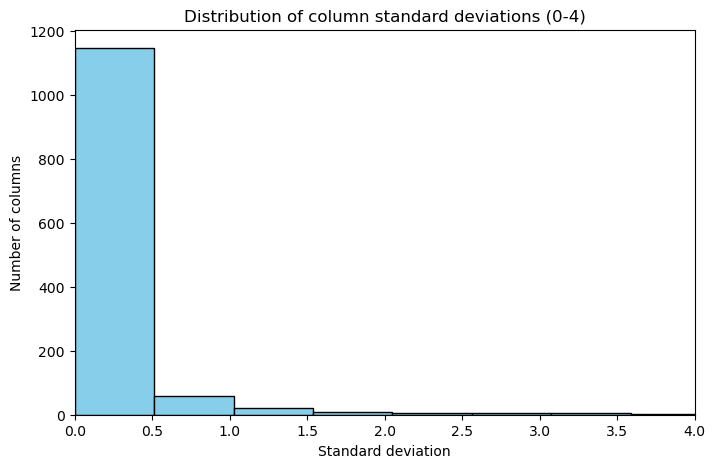

In [18]:
plt.figure(figsize=(8,5))
plt.hist(stds, bins=30, color='skyblue', edgecolor='black')
plt.xlim(0, 4)  # Focus x-axis between 0 and 4
plt.xlabel("Standard deviation")
plt.ylabel("Number of columns")
plt.title("Distribution of column standard deviations (0-4)")
plt.show()

In [19]:
metadata = pd.read_excel('../data/metadata_LATINBIOTA_MEXICO.xlsx', sheet_name='Data')

In [20]:
rare = ['37082_3#16',
'37082_2#4',
'37035_2#22',
'37035_7#18',
'36703_3#20',
'36703_3#4']

In [21]:
for id_ in rare:
    try:
        data_sp.drop(id_, axis = 0, inplace = True)
    except:
        pass

In [22]:
stds = data_sp.std()

# Seleccionar top 1000 columnas por std
top_cols = stds.sort_values(ascending=False).head(1000).index
data_sp_top = data_sp[top_cols]


In [23]:
data_sp_top

,GGB4916,Segatella,Streptococcus,Faecalibacterium,Ruminococcus,Agathobacter,Bacteroides,Roseburia,Catenibacterium,Blautia,...,GGB9547,GGB9348,GGB3352,GGB74818,GGB44202,Moryella,GGB9343,GGB52022,Lachnotalea,GGB100393
36703_3#10,0.0000,0.00000,0.31460,3.55883,2.86484,1.52041,32.43933,5.25075,0.00000,3.92776,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000
36703_3#12,0.0000,4.06723,0.38998,13.65037,11.70037,4.57066,0.00000,2.77936,1.08249,2.39343,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000
36703_3#13,0.0000,22.62537,0.36062,20.11008,6.14148,7.22302,0.01499,3.73623,0.33635,0.46372,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000
36703_3#14,0.0000,33.00639,5.61198,0.50796,2.75049,0.50370,0.01129,0.16471,2.02621,1.64632,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000
36703_3#15,0.0000,0.40062,2.42148,0.48589,4.45759,44.21785,0.00000,0.09425,0.00000,3.14182,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37082_3#5,0.0000,2.72953,0.00000,3.41791,5.39807,6.26731,9.40124,1.98799,24.13368,0.76897,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000
37082_3#6,0.0000,2.13699,0.37626,21.19863,4.45623,1.41084,0.00917,2.83173,9.35587,8.96822,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000
37082_3#7,0.0926,1.94466,0.00000,0.39048,0.48245,0.50272,0.00000,0.00095,0.29198,1.02750,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000
37082_3#8,0.0000,3.70994,0.08250,3.34346,0.82096,0.23828,0.00000,0.07259,1.58083,2.29130,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00401


In [24]:
rural = list(metadata[metadata['Lifestyle'] == 'Rural']['Lane'])
urban = list(metadata[metadata['Lifestyle'] == 'Urban']['Lane'])

In [25]:
label = []
for x in data_sp_top.index:
    if x in rural:
        label.append('Rural')
    elif x in urban:
        label.append('Urban')
    else:
        label.append('None')
        

In [26]:
data_sp_top['label'] = label

C:\Users\rafap\AppData\Local\Temp\ipykernel_14172\1295263056.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_sp_top['label'] = label


In [27]:
data_sp_top

,GGB4916,Segatella,Streptococcus,Faecalibacterium,Ruminococcus,Agathobacter,Bacteroides,Roseburia,Catenibacterium,Blautia,...,GGB9348,GGB3352,GGB74818,GGB44202,Moryella,GGB9343,GGB52022,Lachnotalea,GGB100393,label
36703_3#10,0.0000,0.00000,0.31460,3.55883,2.86484,1.52041,32.43933,5.25075,0.00000,3.92776,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,Urban
36703_3#12,0.0000,4.06723,0.38998,13.65037,11.70037,4.57066,0.00000,2.77936,1.08249,2.39343,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,Rural
36703_3#13,0.0000,22.62537,0.36062,20.11008,6.14148,7.22302,0.01499,3.73623,0.33635,0.46372,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,Rural
36703_3#14,0.0000,33.00639,5.61198,0.50796,2.75049,0.50370,0.01129,0.16471,2.02621,1.64632,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,Rural
36703_3#15,0.0000,0.40062,2.42148,0.48589,4.45759,44.21785,0.00000,0.09425,0.00000,3.14182,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,Rural
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37082_3#5,0.0000,2.72953,0.00000,3.41791,5.39807,6.26731,9.40124,1.98799,24.13368,0.76897,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,Rural
37082_3#6,0.0000,2.13699,0.37626,21.19863,4.45623,1.41084,0.00917,2.83173,9.35587,8.96822,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,Rural
37082_3#7,0.0926,1.94466,0.00000,0.39048,0.48245,0.50272,0.00000,0.00095,0.29198,1.02750,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,Rural
37082_3#8,0.0000,3.70994,0.08250,3.34346,0.82096,0.23828,0.00000,0.07259,1.58083,2.29130,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00401,Rural


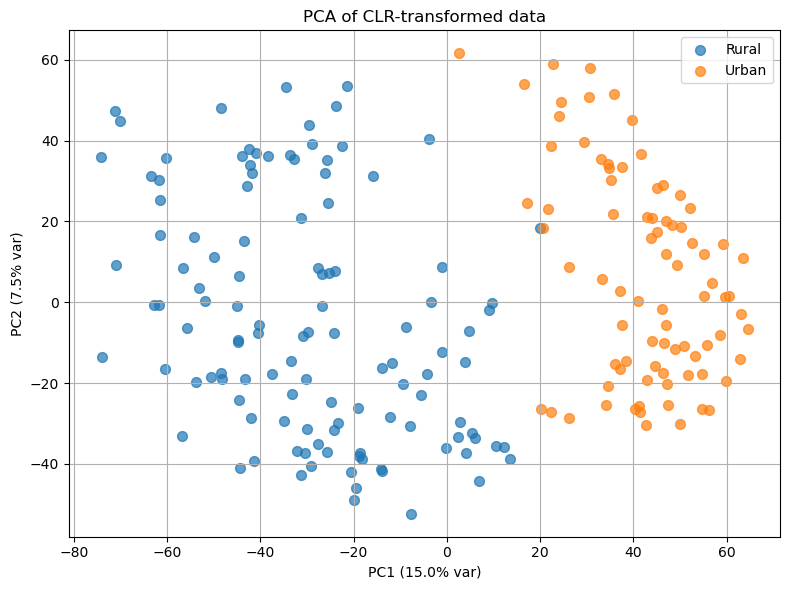

In [28]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# CLR transformation function
def clr_transform(X):
    """
    Apply Centered Log-Ratio (CLR) transformation to compositional data.
    
    Parameters:
    X : array-like, shape (n_samples, n_features)
        Compositional data (must be positive)
    
    Returns:
    X_clr : array, CLR-transformed data
    """
    # Add small constant to avoid log(0) if there are zeros
    X_safe = X + 1e-6
    
    # Compute geometric mean for each sample (row)
    geom_mean = np.exp(np.mean(np.log(X_safe), axis=1, keepdims=True))
    
    # CLR: log(x_i / geometric_mean)
    X_clr = np.log(X_safe / geom_mean)
    
    return X_clr

# Separate features and labels
X = data_sp_top.drop(columns=['label']).values
y = data_sp_top['label'].values

# 1. Apply CLR transformation
# X_clr = X
X_clr = clr_transform(X)

# 2. Optional: Standardization (uncomment if needed)
# scaler = StandardScaler()
# X_clr = scaler.fit_transform(X_clr)

# 3. Perform PCA (2 components)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_clr)

# Make a scatter plot
plt.figure(figsize=(8,6))

# Map unique labels to colors
labels_unique = sorted(set(y))
colors = plt.cm.tab10.colors  # up to 10 colors

for i, lbl in enumerate(labels_unique):
    idx = y == lbl
    plt.scatter(X_pca[idx,0], X_pca[idx,1], 
                label=lbl, 
                color=colors[i % len(colors)], 
                alpha=0.7, s=50)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
plt.title('PCA of CLR-transformed data')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [29]:
import math
age_group_list = []
for id_ in data_sp_top.index:
    try:
        if math.isnan(metadata[metadata['Lane'] == id_]['Age group'].iloc[0]):
            age_group_list.append('Adult')
    except:
        if metadata[metadata['Lane'] == id_]['Age group'].iloc[0] == 'Infant':
            age_group_list.append('Child')
        elif metadata[metadata['Lane'] == id_]['Age group'].iloc[0] == 'Teenager':
            age_group_list.append('Adult')
        else:
            age_group_list.append(metadata[metadata['Lane'] == id_]['Age group'].iloc[0])

In [30]:
data_sp_top['age_group'] = age_group_list

C:\Users\rafap\AppData\Local\Temp\ipykernel_14172\2344775883.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_sp_top['age_group'] = age_group_list


In [31]:
import math
health_list = []
for i in range(len(data_sp_top.index)):
    if age_group_list[i] == 'Adult':
        if metadata[metadata['Lane'] == data_sp_top.index[i]]['BMI'].iloc[0] < 18.5:
            health_list.append('Bajo')
        elif metadata[metadata['Lane'] == data_sp_top.index[i]]['BMI'].iloc[0] >= 18.5 and metadata[metadata['Lane'] == data_sp_top.index[i]]['BMI'].iloc[0] < 25:
            health_list.append('Normal')
        elif metadata[metadata['Lane'] == data_sp_top.index[i]]['BMI'].iloc[0] >= 25:
            health_list.append('Sobrepeso')
        else:
            health_list.append('Sin datos')
    elif age_group_list[i] == 'Child':
        if metadata[metadata['Lane'] == data_sp_top.index[i]]['BMI'].iloc[0] < 14:
            health_list.append('Bajo')
        elif metadata[metadata['Lane'] == data_sp_top.index[i]]['BMI'].iloc[0] >= 14 and metadata[metadata['Lane'] == data_sp_top.index[i]]['BMI'].iloc[0] < 18:
            health_list.append('Normal')
        elif metadata[metadata['Lane'] == data_sp_top.index[i]]['BMI'].iloc[0] >= 18:
            health_list.append('Sobrepeso')
        else:
            health_list.append('Sin datos')
    else:
        health_list.append('Sin datos')

In [32]:
data_sp_top['BMI'] = health_list

C:\Users\rafap\AppData\Local\Temp\ipykernel_14172\1684128443.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_sp_top['BMI'] = health_list


In [33]:
data_sp_top

,GGB4916,Segatella,Streptococcus,Faecalibacterium,Ruminococcus,Agathobacter,Bacteroides,Roseburia,Catenibacterium,Blautia,...,GGB74818,GGB44202,Moryella,GGB9343,GGB52022,Lachnotalea,GGB100393,label,age_group,BMI
36703_3#10,0.0000,0.00000,0.31460,3.55883,2.86484,1.52041,32.43933,5.25075,0.00000,3.92776,...,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,Urban,Child,Normal
36703_3#12,0.0000,4.06723,0.38998,13.65037,11.70037,4.57066,0.00000,2.77936,1.08249,2.39343,...,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,Rural,Child,Sobrepeso
36703_3#13,0.0000,22.62537,0.36062,20.11008,6.14148,7.22302,0.01499,3.73623,0.33635,0.46372,...,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,Rural,Adult,Normal
36703_3#14,0.0000,33.00639,5.61198,0.50796,2.75049,0.50370,0.01129,0.16471,2.02621,1.64632,...,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,Rural,Child,Normal
36703_3#15,0.0000,0.40062,2.42148,0.48589,4.45759,44.21785,0.00000,0.09425,0.00000,3.14182,...,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,Rural,Child,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37082_3#5,0.0000,2.72953,0.00000,3.41791,5.39807,6.26731,9.40124,1.98799,24.13368,0.76897,...,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,Rural,Adult,Sobrepeso
37082_3#6,0.0000,2.13699,0.37626,21.19863,4.45623,1.41084,0.00917,2.83173,9.35587,8.96822,...,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,Rural,Child,Normal
37082_3#7,0.0926,1.94466,0.00000,0.39048,0.48245,0.50272,0.00000,0.00095,0.29198,1.02750,...,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,Rural,Adult,Normal
37082_3#8,0.0000,3.70994,0.08250,3.34346,0.82096,0.23828,0.00000,0.07259,1.58083,2.29130,...,0.0,0.0,0.0,0.0,0.0,0.0,0.00401,Rural,Child,Sobrepeso


In [34]:
metadata.head()

,Run,Lane,Sample,Supplier Name,Public Name,Read count,Sample.1,Study,Health state,Disease name,BMI,Antibiotics,Age,Age group,Gender,Lifestyle,Country,Continent
0,37082_3_9,37082_3#9,GI1_LA9438076,50,47,18623506,37082_3_9,Latinbiota,Healthy,NaN,18.1,NaN,7.0,Child,Male,Rural,Mexico,North America
1,37082_3_8,37082_3#8,GI1_LA9438075,49,76,27292796,37082_3_8,Latinbiota,Healthy,NaN,18.7,NaN,9.0,Child,Male,Rural,Mexico,North America
2,37082_3_7,37082_3#7,GI1_LA9438074,47,73,23589062,37082_3_7,Latinbiota,Healthy,NaN,23.5,NaN,23.0,Adult,Female,Rural,Mexico,North America
3,37082_3_6,37082_3#6,GI1_LA9438073,76,161,17556434,37082_3_6,Latinbiota,Healthy,NaN,14.9,NaN,6.0,Child,Male,Rural,Mexico,North America
4,37082_3_5,37082_3#5,GI1_LA9438072,73,159,23119984,37082_3_5,Latinbiota,Healthy,NaN,26.5,NaN,30.0,Adult,Female,Rural,Mexico,North America


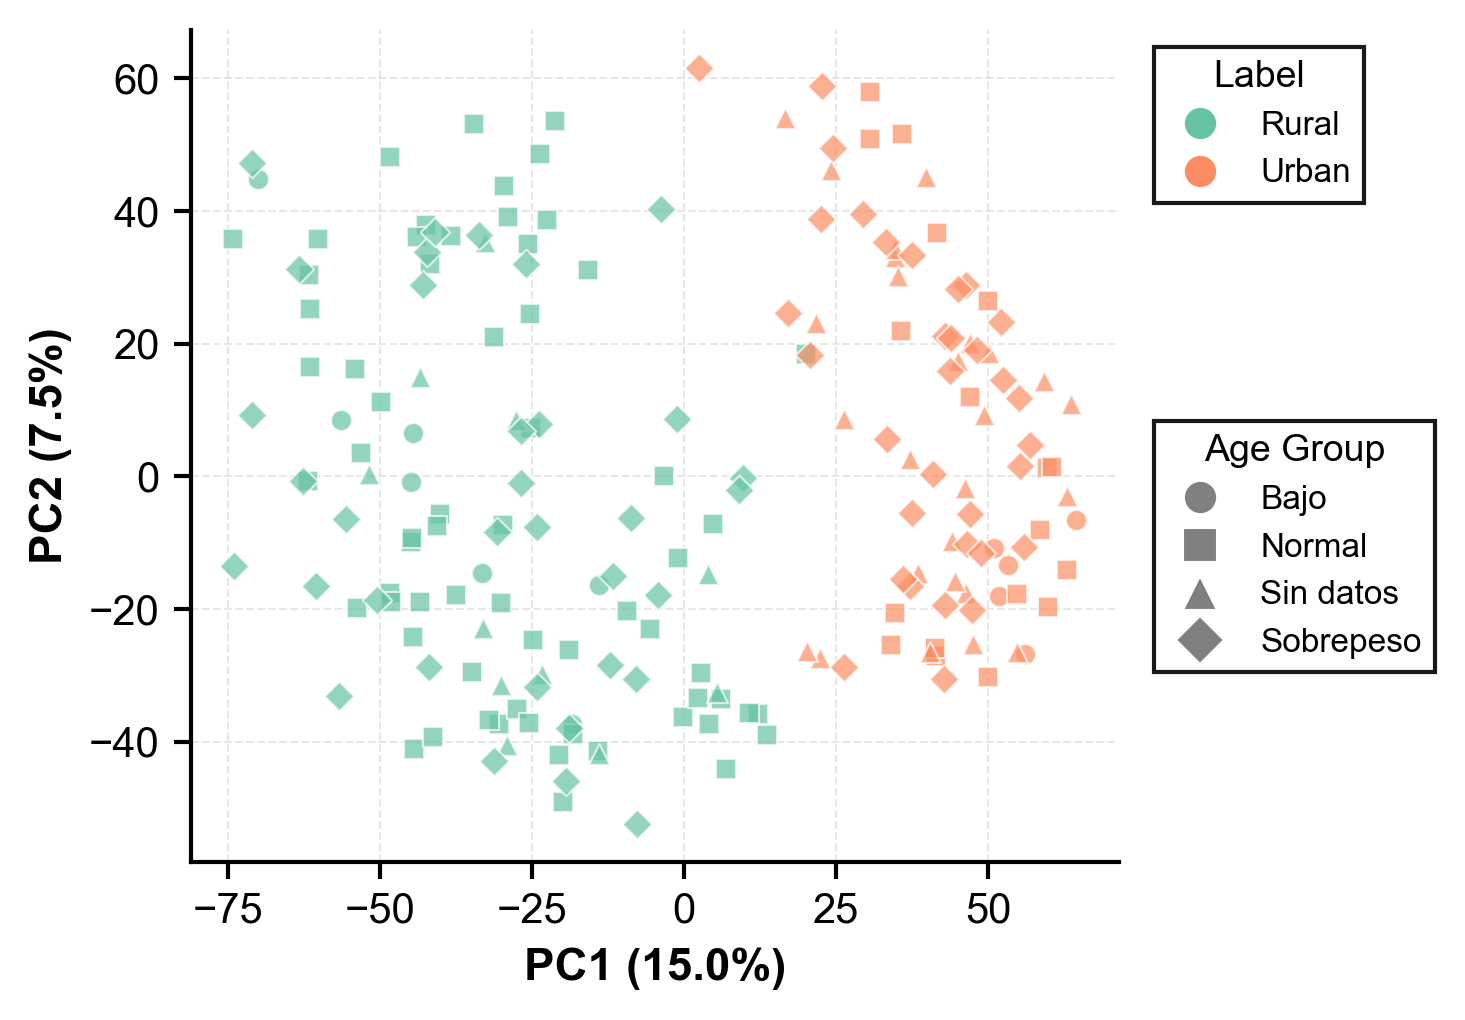

In [89]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
from matplotlib.lines import Line2D

# CLR transformation function
def clr_transform(X):
    """
    Apply Centered Log-Ratio (CLR) transformation to compositional data.
    
    Parameters:
    X : array-like, shape (n_samples, n_features)
        Compositional data (must be positive)
    
    Returns:
    X_clr : array, CLR-transformed data
    """
    # Add small constant to avoid log(0) if there are zeros
    X_safe = X + 1e-6
    
    # Compute geometric mean for each sample (row)
    geom_mean = np.exp(np.mean(np.log(X_safe), axis=1, keepdims=True))
    
    # CLR: log(x_i / geometric_mean)
    X_clr = np.log(X_safe / geom_mean)
    
    return X_clr

# Separate features and labels
X = data_sp_top.drop(columns=['label', 'age_group', 'BMI']).values
y = data_sp_top['label'].values
age_group = data_sp_top['BMI'].values  # Make sure this column exists

# 1. Apply CLR transformation
X_clr = clr_transform(X)

# 2. Optional: Standardization (uncomment if needed)
# scaler = StandardScaler()
# X_clr = scaler.fit_transform(X_clr)

# 3. Perform PCA (2 components)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_clr)

# Set journal-style parameters
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 10
plt.rcParams['axes.linewidth'] = 1.0
plt.rcParams['xtick.major.width'] = 1.0
plt.rcParams['ytick.major.width'] = 1.0
plt.rcParams['xtick.major.size'] = 4
plt.rcParams['ytick.major.size'] = 4

# Create figure with specific size (suitable for journal column width)
fig, ax = plt.subplots(figsize=(5, 3.5), dpi=300)

# Map unique labels to colors
labels_unique = sorted(set(y))
colors = plt.cm.Set2.colors if len(labels_unique) <= 8 else plt.cm.tab10.colors

# Map unique age groups to markers
age_groups_unique = sorted(set(age_group))
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']

# Plot each combination of label and age group
for i, lbl in enumerate(labels_unique):
    for j, age in enumerate(age_groups_unique):
        idx = (y == lbl) & (age_group == age)
        
        if np.any(idx):
            marker_style = markers[j % len(markers)]
            color = colors[i % len(colors)]
            
            ax.scatter(X_pca[idx, 0], X_pca[idx, 1],
                      color=color,
                      marker=marker_style,
                      alpha=0.7,
                      s=25,
                      edgecolors='white',
                      linewidths=0.5)

# Create custom legend elements AFTER plotting
# Legend for labels (colors)
label_legend_elements = [Line2D([0], [0], marker='o', color='w', 
                                markerfacecolor=colors[i % len(colors)], 
                                markersize=8, label=lbl,
                                markeredgecolor='white', markeredgewidth=0.5)
                        for i, lbl in enumerate(labels_unique)]

# Legend for age groups (markers)
age_legend_elements = [Line2D([0], [0], marker=markers[j % len(markers)], 
                              color='w', markerfacecolor='gray', 
                              markersize=8, label=age,
                              markeredgecolor='white', markeredgewidth=0.5)
                      for j, age in enumerate(age_groups_unique)]

# Add first legend (labels)
first_legend = ax.legend(handles=label_legend_elements, 
                        title='Label',
                        loc='upper left',
                        bbox_to_anchor=(1.02, 1),
                        fontsize=8,
                        title_fontsize=9,
                        frameon=True,
                        edgecolor='black',
                        fancybox=False,
                        framealpha=0.9)

# Add second legend (age groups)
ax.add_artist(first_legend)  # Keep first legend
ax.legend(handles=age_legend_elements,
         title='Age Group',
         loc='upper left',
         bbox_to_anchor=(1.02, 0.55),
         fontsize=8,
         title_fontsize=9,
         frameon=True,
         edgecolor='black',
         fancybox=False,
         framealpha=0.9)

# Format axes
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', 
              fontsize=11, fontweight='bold')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', 
              fontsize=11, fontweight='bold')

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add subtle grid
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

# Optional: Save as high-resolution files for publication
# fig.savefig('pca_clr_analysis.pdf', dpi=300, bbox_inches='tight')
# fig.savefig('pca_clr_analysis_genus.png', dpi=400, bbox_inches='tight')
# fig.savefig('pca_clr_analysis.svg', bbox_inches='tight')

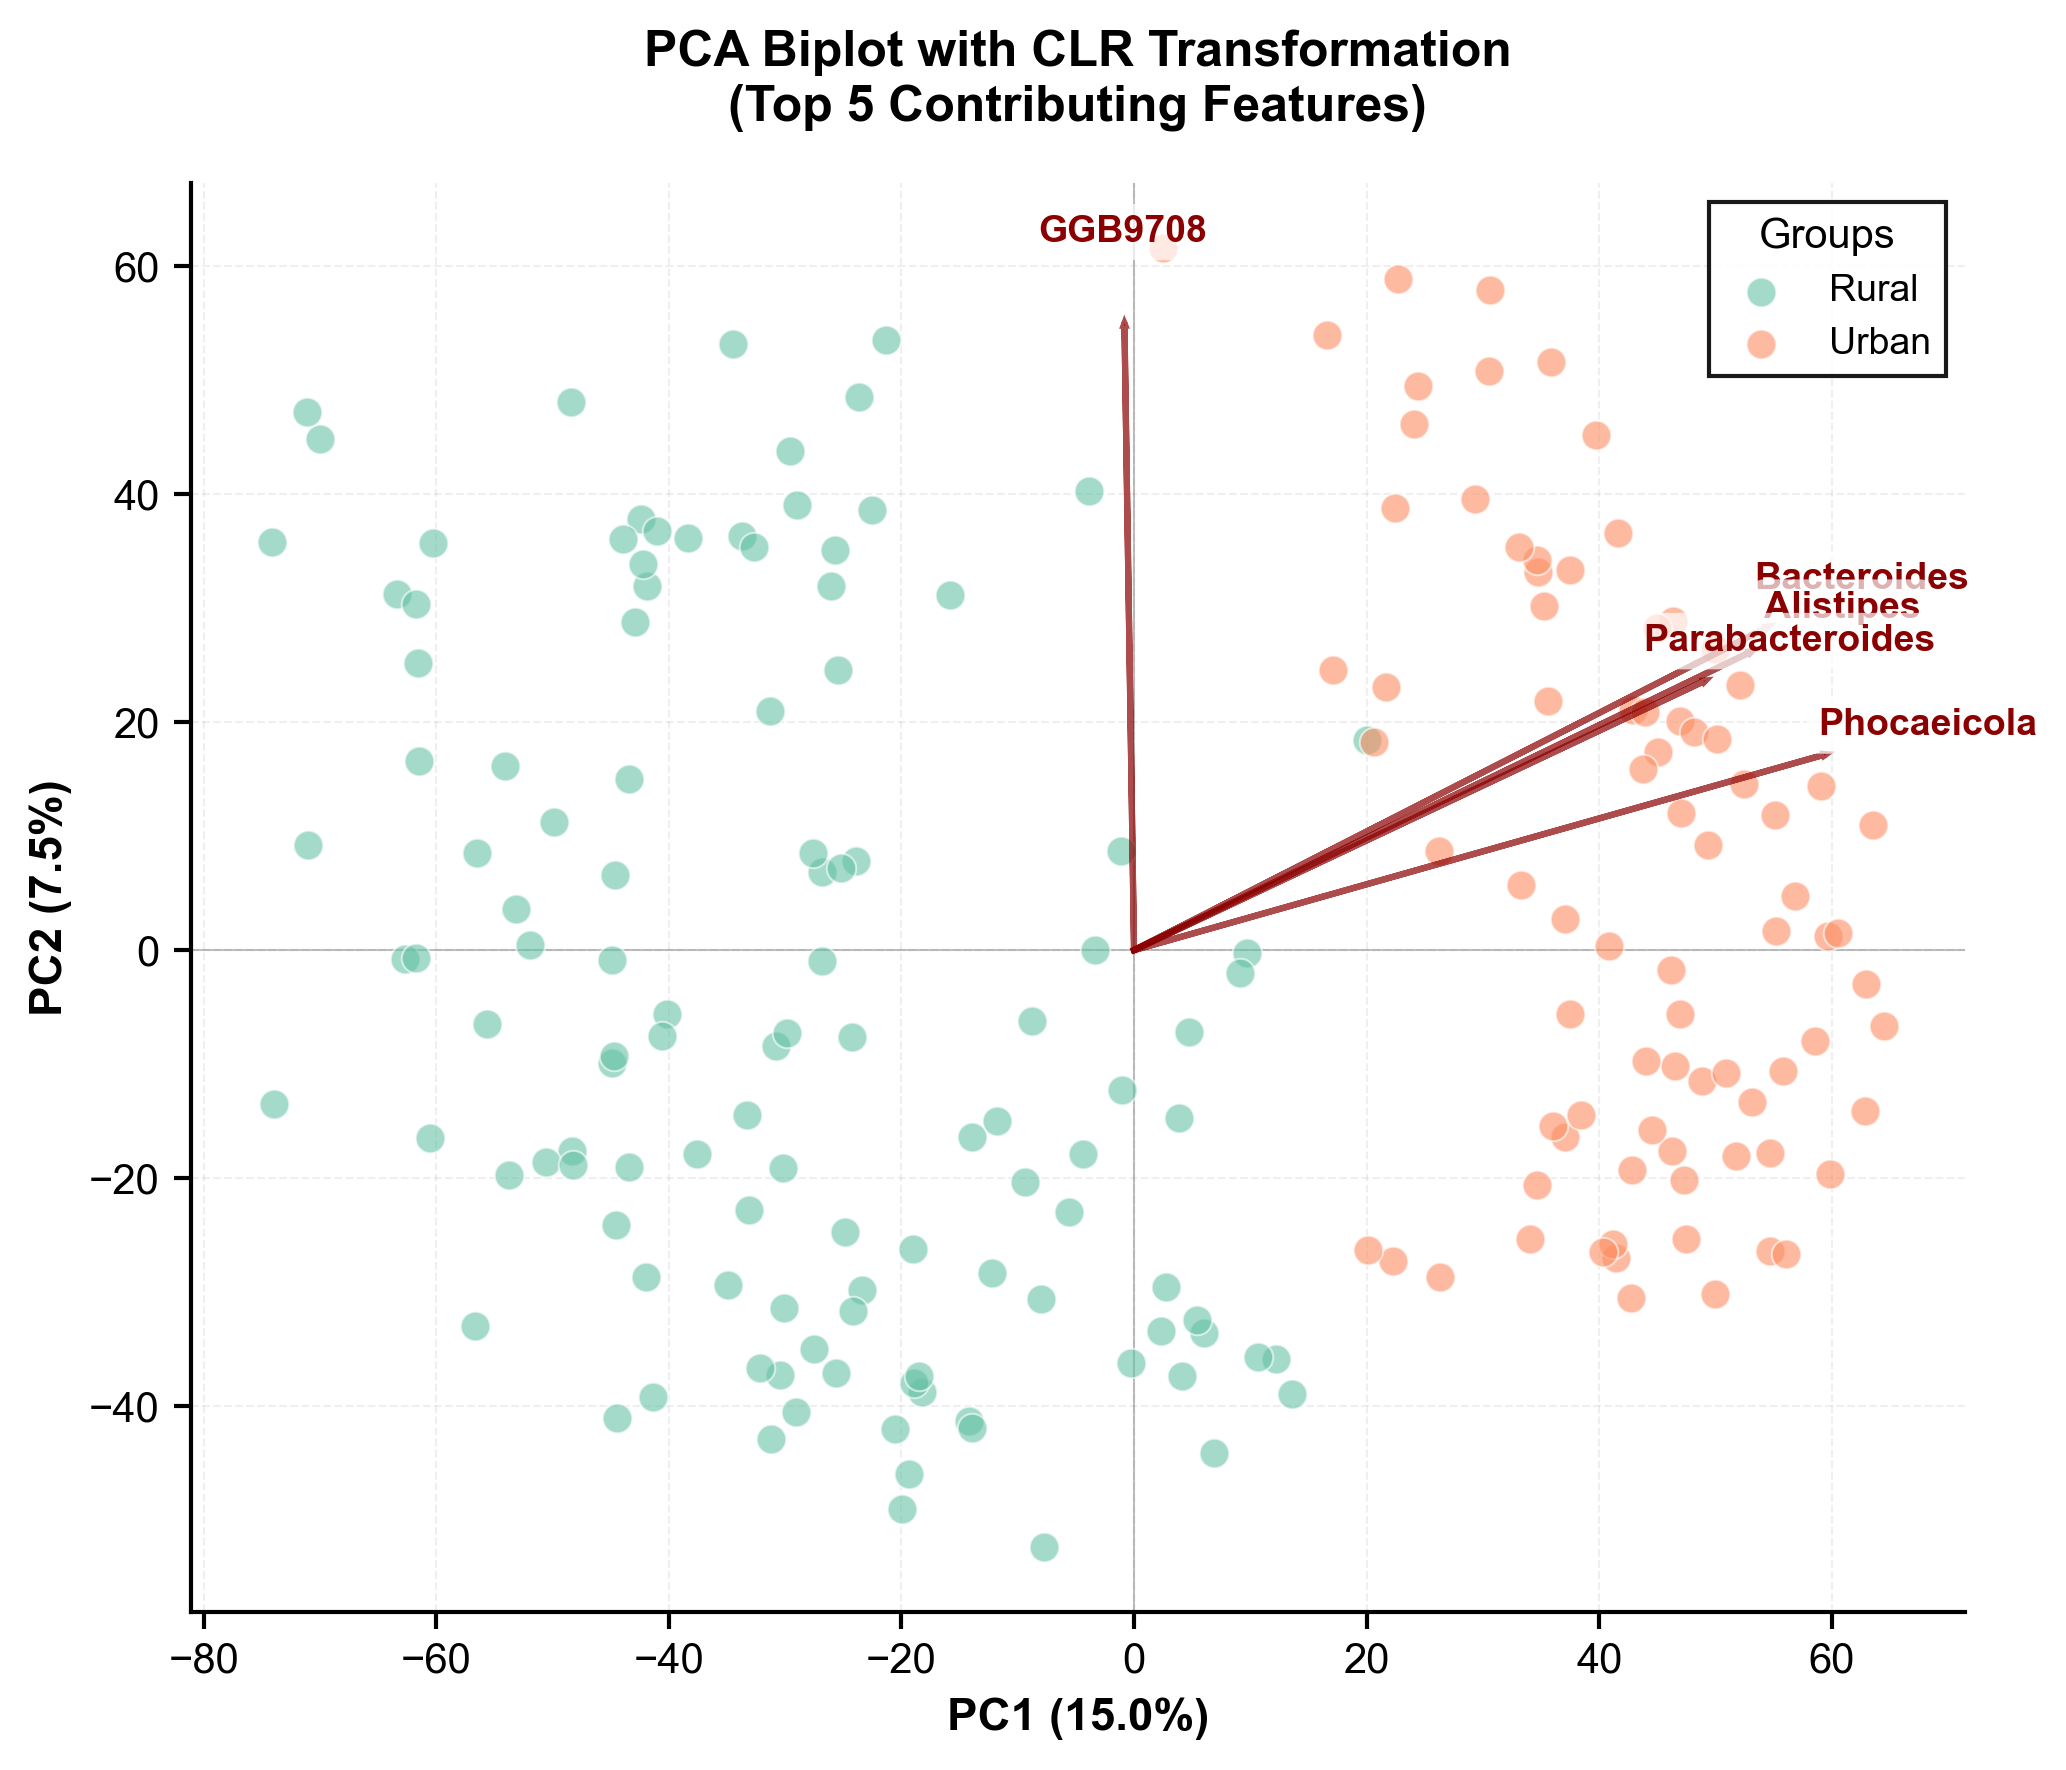

In [32]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
#from adjustText import adjustText  # Optional: for better label positioning

# CLR transformation function
def clr_transform(X):
    """
    Apply Centered Log-Ratio (CLR) transformation to compositional data.
    
    Parameters:
    X : array-like, shape (n_samples, n_features)
        Compositional data (must be positive)
    
    Returns:
    X_clr : array, CLR-transformed data
    """
    # Add small constant to avoid log(0) if there are zeros
    X_safe = X + 1e-6
    
    # Compute geometric mean for each sample (row)
    geom_mean = np.exp(np.mean(np.log(X_safe), axis=1, keepdims=True))
    
    # CLR: log(x_i / geometric_mean)
    X_clr = np.log(X_safe / geom_mean)
    
    return X_clr

# Prepare data
X = data_sp_top.drop(columns=['label', 'age_group']).values
y = data_sp_top['label'].values
feature_names = data_sp_top.drop(columns=['label', 'age_group']).columns

# Apply CLR transformation
X_clr = clr_transform(X)

# Perform PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_clr)

# Loadings (contributions of original variables)
loadings = pca.components_.T  # shape: n_features x 2

# Compute contribution of each feature to PC1+PC2
contrib = np.linalg.norm(loadings, axis=1)  # Euclidean norm across PCs

# Select top 10 features by contribution
top_n = 5
top_idx = np.argsort(contrib)[-top_n:][::-1]  # indices of top features
top_features = feature_names[top_idx]

# Set journal-style parameters
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 10
plt.rcParams['axes.linewidth'] = 1.0
plt.rcParams['xtick.major.width'] = 1.0
plt.rcParams['ytick.major.width'] = 1.0
plt.rcParams['xtick.major.size'] = 4
plt.rcParams['ytick.major.size'] = 4

# Create figure
fig, ax = plt.subplots(figsize=(7, 6), dpi=300)

# Get unique labels and colors
labels_unique = sorted(set(y))
colors = plt.cm.Set2.colors if len(labels_unique) <= 8 else plt.cm.tab10.colors

# Scatter plot of samples
for i, group in enumerate(labels_unique):
    idx = y == group
    ax.scatter(X_pca[idx, 0], X_pca[idx, 1], 
              alpha=0.6, 
              s=50, 
              label=group,
              color=colors[i % len(colors)],
              edgecolors='white',
              linewidths=0.5,
              zorder=2)

# Draw arrows for top features
scaling = np.max(np.abs(X_pca)) / np.max(np.abs(loadings)) * 0.8  # Auto-scale arrows
texts = []

for i in top_idx:
    # Draw arrow
    ax.arrow(0, 0, 
            loadings[i, 0] * scaling, 
            loadings[i, 1] * scaling, 
            color='darkred', 
            alpha=0.7, 
            head_width=0.15,
            head_length=0.2,
            linewidth=1.5,
            zorder=3)
    
    # Add text label
    text = ax.text(loadings[i, 0] * scaling * 1.15, 
                   loadings[i, 1] * scaling * 1.15, 
                   feature_names[i],
                   fontsize=9, 
                   color='darkred',
                   ha='center',
                   va='center',
                   fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.3', 
                           facecolor='white', 
                           edgecolor='none',
                           alpha=0.7),
                   zorder=4)
    texts.append(text)

# Optional: Use adjustText to prevent label overlap
# Uncomment if you have adjustText installed: pip install adjustText
# adjustText(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=0.5))

# Format axes
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', 
              fontsize=11, fontweight='bold')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', 
              fontsize=11, fontweight='bold')
ax.set_title('PCA Biplot with CLR Transformation\n(Top 5 Contributing Features)', 
             fontsize=12, fontweight='bold', pad=15)

# Legend
ax.legend(frameon=True, 
          loc='best',
          fontsize=9,
          edgecolor='black',
          fancybox=False,
          shadow=False,
          framealpha=0.9,
          title='Groups',
          title_fontsize=10)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add subtle grid
ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.5, zorder=1)
ax.set_axisbelow(True)

# Add reference lines at origin
ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5, zorder=1)
ax.axvline(x=0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5, zorder=1)

plt.tight_layout()
plt.show()

# Optional: Save as high-resolution files for publication
# fig.savefig('pca_biplot_clr.pdf', dpi=300, bbox_inches='tight')
fig.savefig('pca_biplot_clr_genus.png', dpi=400, bbox_inches='tight')
# fig.savefig('pca_biplot_clr.svg', bbox_inches='tight')

Selected 7 distinct directions from 40 top features
1. Direction 1: GGB4888, Paratractidigestivibacter, GGB4672, Ellagibacter, Senegalimassilia, Catenibacterium, GGB9370, GGB3862, GGB3588
2. Direction 2: Methanobrevibacter, GGB3306
3. Direction 3: GGB4642
4. Direction 4: GGB9708, GGB9747, GGB3304, GGB143497, GGB9712, GGB9634, GGB3321, Brotocaccenecus, GGB9602, GGB9707, GGB3619, Dysosmobacter, GGB9636, GGB9691, Oscillibacter, GGB9677, GGB9618, GGB9293
5. Direction 5: Phocaeicola, Bacteroides, Alistipes, Parabacteroides, Odoribacter, Ruthenibacterium, Barnesiella, Hominiventricola
6. Direction 6: GGB9699
7. Direction 7: Thomasclavelia


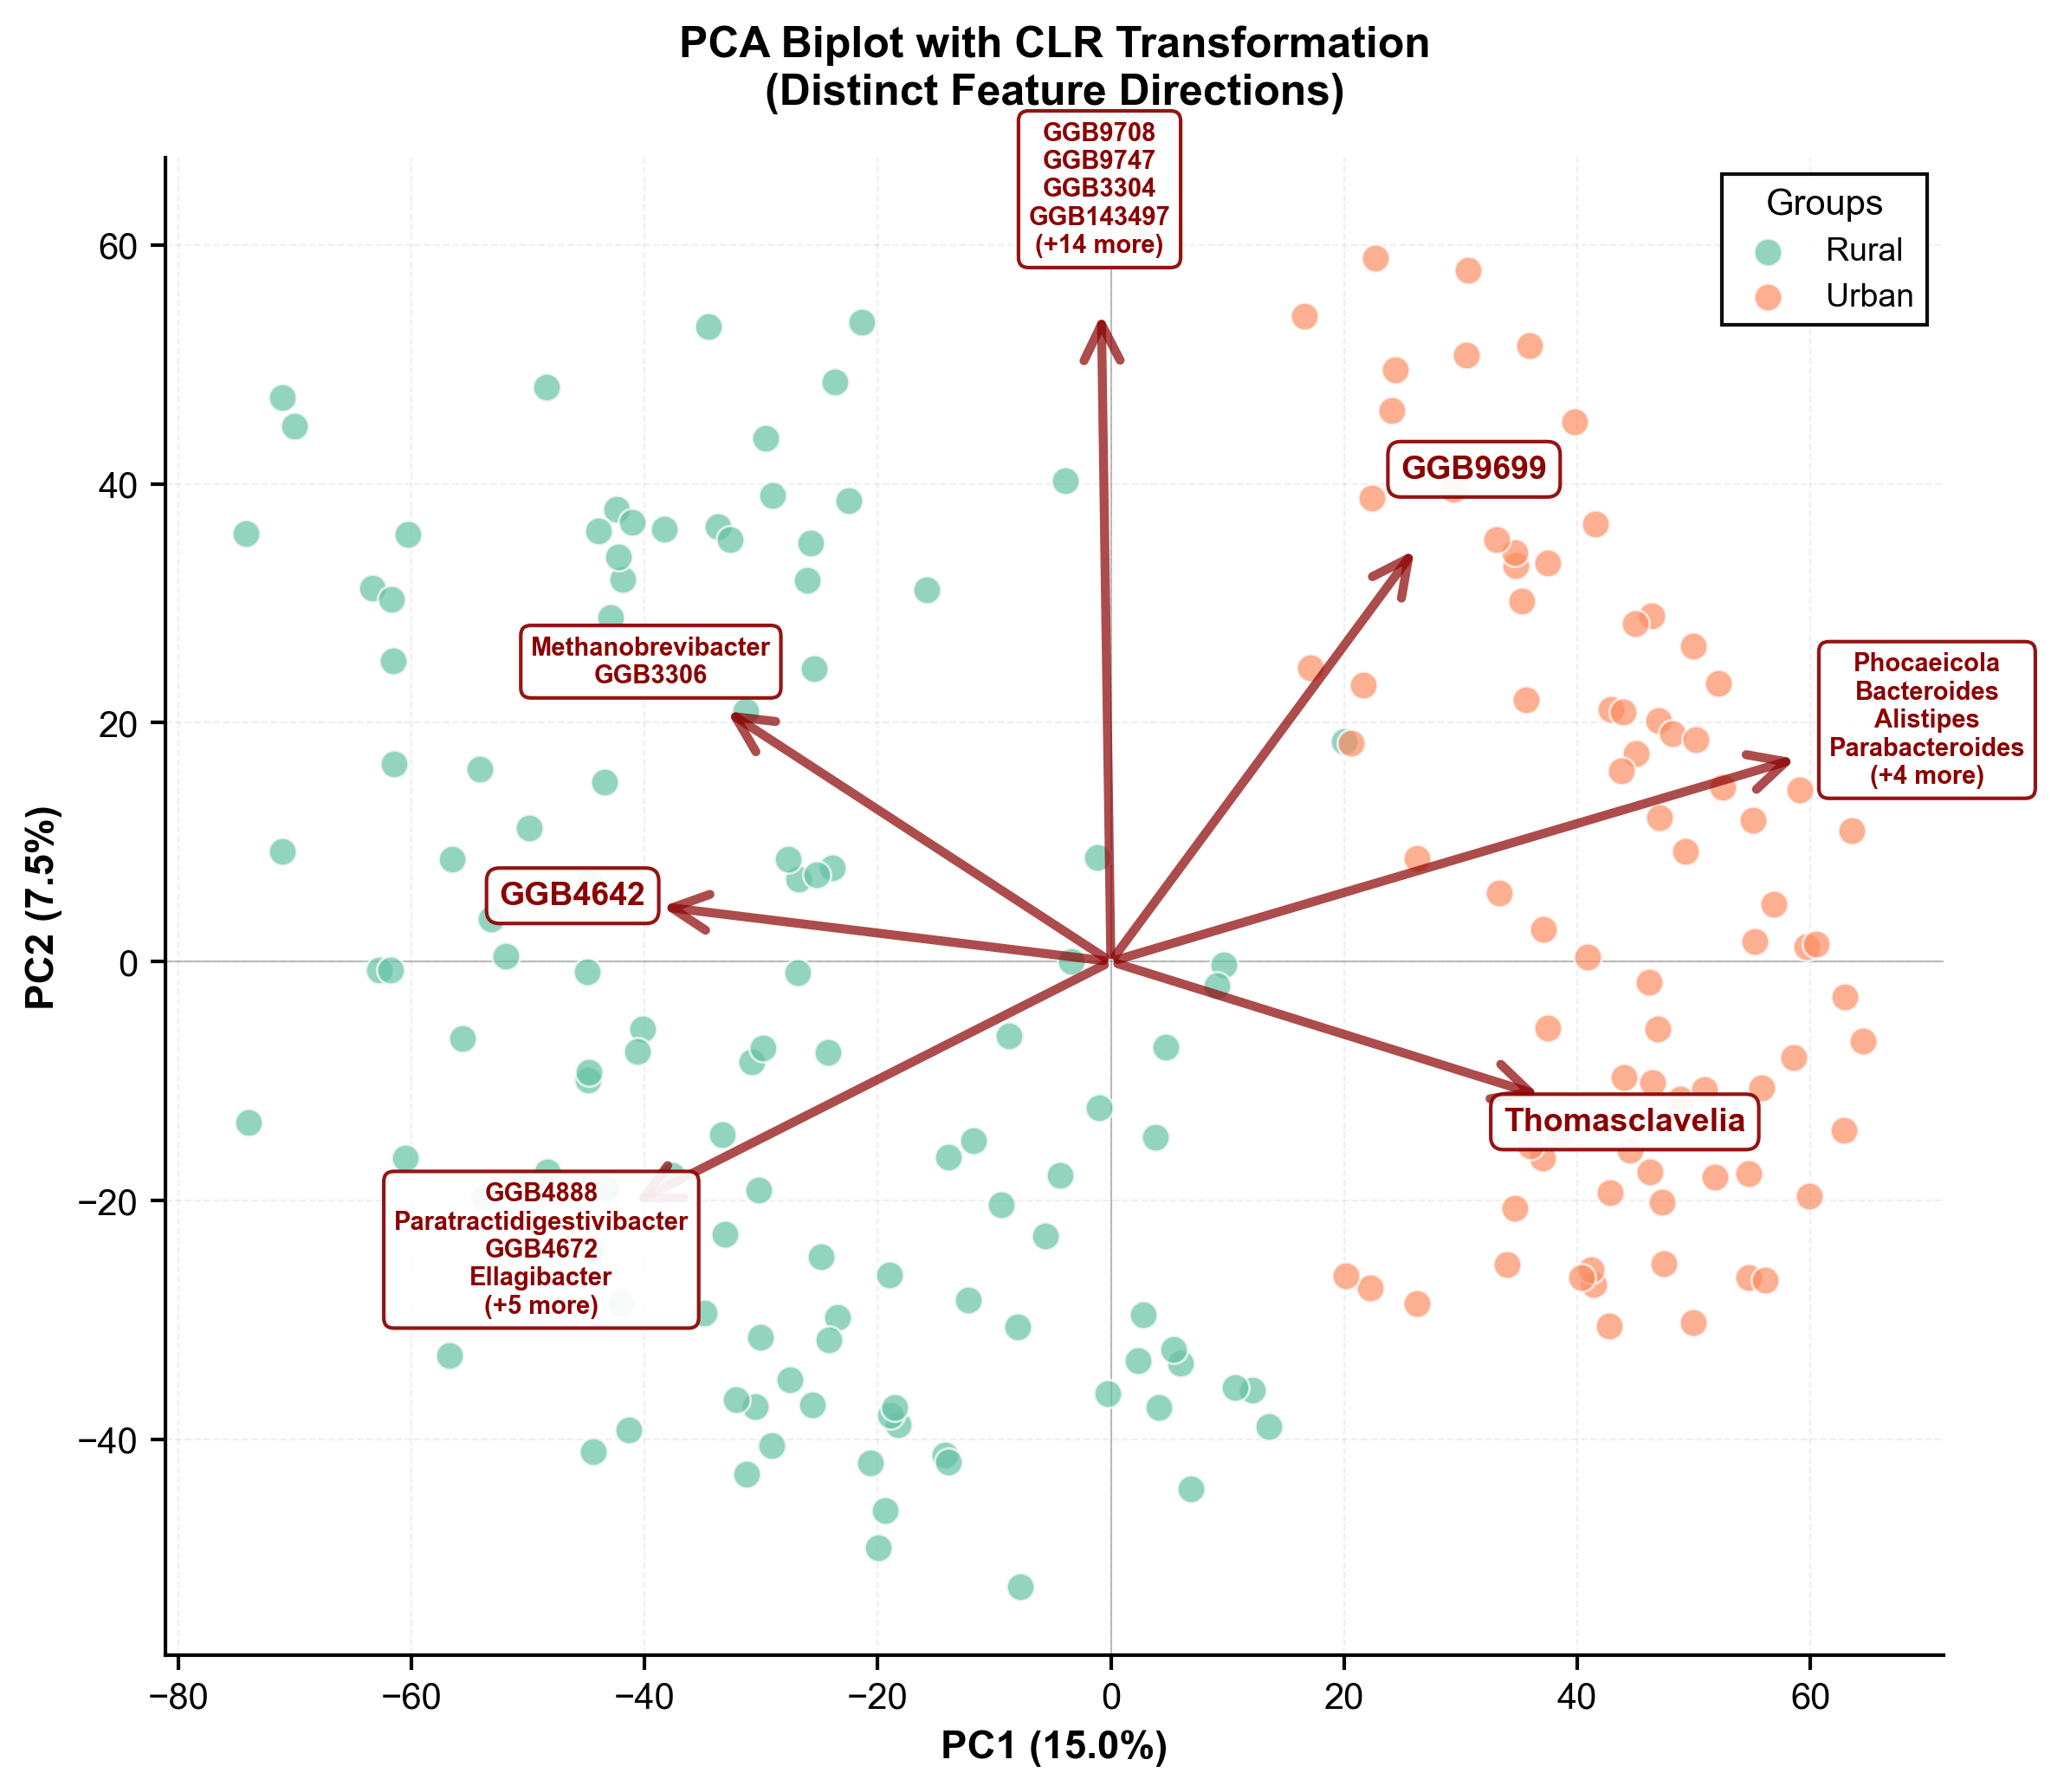

In [37]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist

# CLR transformation function
def clr_transform(X):
    """
    Apply Centered Log-Ratio (CLR) transformation to compositional data.
    
    Parameters:
    X : array-like, shape (n_samples, n_features)
        Compositional data (must be positive)
    
    Returns:
    X_clr : array, CLR-transformed data
    """
    # Add small constant to avoid log(0) if there are zeros
    X_safe = X + 1e-6
    
    # Compute geometric mean for each sample (row)
    geom_mean = np.exp(np.mean(np.log(X_safe), axis=1, keepdims=True))
    
    # CLR: log(x_i / geometric_mean)
    X_clr = np.log(X_safe / geom_mean)
    
    return X_clr

# Prepare data
X = data_sp_top.drop(columns=['label', 'age_group']).values
y = data_sp_top['label'].values
feature_names = data_sp_top.drop(columns=['label', 'age_group']).columns

# Apply CLR transformation
X_clr = clr_transform(X)

# Perform PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_clr)

# Loadings (contributions of original variables)
loadings = pca.components_.T  # shape: n_features x 2

# Compute contribution of each feature to PC1+PC2
contrib = np.linalg.norm(loadings, axis=1)  # Euclidean norm across PCs

# Select top N features by contribution
top_n = 40  # Start with more features, then cluster them
top_idx = np.argsort(contrib)[-top_n:][::-1]
top_loadings = loadings[top_idx]
top_features = feature_names[top_idx]

# Cluster features based on their loading vectors (direction in PC space)
# Use cosine distance to group features pointing in similar directions
distances = pdist(top_loadings, metric='cosine')
linkage_matrix = linkage(distances, method='average')

# Cut tree to get clusters (adjust distance_threshold to control number of groups)
distance_threshold = 0.1  # Lower = more clusters, Higher = fewer clusters
clusters = fcluster(linkage_matrix, distance_threshold, criterion='distance')

# For each cluster, select the feature with highest contribution
selected_features = []
selected_idx = []
for cluster_id in np.unique(clusters):
    cluster_mask = clusters == cluster_id
    cluster_indices = np.where(cluster_mask)[0]
    
    # Find feature with max contribution in this cluster
    cluster_contrib = contrib[top_idx[cluster_indices]]
    best_in_cluster = cluster_indices[np.argmax(cluster_contrib)]
    
    selected_idx.append(top_idx[best_in_cluster])
    
    # Get all features in this cluster for labeling
    cluster_features = [feature_names[top_idx[i]] for i in cluster_indices]
    selected_features.append(cluster_features)

print(f"Selected {len(selected_features)} distinct directions from {top_n} top features")
for i, (idx, feat_group) in enumerate(zip(selected_idx, selected_features)):
    print(f"{i+1}. Direction {i+1}: {', '.join(feat_group)}")

# Set journal-style parameters
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 10
plt.rcParams['axes.linewidth'] = 1.0
plt.rcParams['xtick.major.width'] = 1.0
plt.rcParams['ytick.major.width'] = 1.0
plt.rcParams['xtick.major.size'] = 4
plt.rcParams['ytick.major.size'] = 4

# Create figure
fig, ax = plt.subplots(figsize=(8, 7), dpi=300)

# Get unique labels and colors
labels_unique = sorted(set(y))
colors = plt.cm.Set2.colors if len(labels_unique) <= 8 else plt.cm.tab10.colors

# Add subtle grid FIRST (lowest layer)
ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.5, zorder=0)
ax.set_axisbelow(True)

# Add reference lines at origin
ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5, zorder=1)
ax.axvline(x=0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5, zorder=1)

# Scatter plot of samples
for i, group in enumerate(labels_unique):
    idx = y == group
    ax.scatter(X_pca[idx, 0], X_pca[idx, 1], 
              alpha=0.7, 
              s=60, 
              label=group,
              color=colors[i % len(colors)],
              edgecolors='white',
              linewidths=0.7,
              zorder=3)

# Draw arrows with all correlated features shown
for i, (feat_idx, feat_group) in enumerate(zip(selected_idx, selected_features)):
    # Draw arrow
    ax.annotate('',
               xy=(loadings[feat_idx, 0] * scaling, loadings[feat_idx, 1] * scaling),
               xytext=(0, 0),
               arrowprops=dict(arrowstyle='->',
                             lw=2.5,
                             color='darkred',
                             mutation_scale=25,
                             alpha=0.7),
               zorder=4)
    
    # Show multiple features if they're clustered together
    if len(feat_group) == 1:
        label_text = feat_group[0]
        fontsize = 9
    else:
        # Show up to 4 features, then add "+N more"
        max_show = 4
        if len(feat_group) <= max_show:
            label_text = '\n'.join(feat_group)
        else:
            label_text = '\n'.join(feat_group[:max_show]) + f'\n(+{len(feat_group)-max_show} more)'
        fontsize = 7  # Smaller font for multiple features
    
    # Add text label
    text_offset = 1.18
    text = ax.text(loadings[feat_idx, 0] * scaling * text_offset,
                   loadings[feat_idx, 1] * scaling * text_offset,
                   label_text,
                   fontsize=fontsize,
                   color='darkred',
                   ha='center',
                   va='center',
                   fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.4',
                           facecolor='white',
                           edgecolor='darkred',
                           alpha=0.92,
                           linewidth=1),
                   zorder=5)
    texts.append(text)


# Format axes
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', 
              fontsize=11, fontweight='bold')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', 
              fontsize=11, fontweight='bold')
ax.set_title('PCA Biplot with CLR Transformation\n(Distinct Feature Directions)', 
             fontsize=12, fontweight='bold', pad=15)

# Legend
ax.legend(frameon=True, 
          loc='best',
          fontsize=9,
          edgecolor='black',
          fancybox=False,
          shadow=False,
          framealpha=0.95,
          title='Groups',
          title_fontsize=10)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Optional: Save as high-resolution files for publication
# fig.savefig('pca_biplot_clr_distinct.pdf', dpi=300, bbox_inches='tight')
fig.savefig('pca_biplot_clr_genus_distinct.png', dpi=400, bbox_inches='tight')
# fig.savefig('pca_biplot_clr_distinct.svg', bbox_inches='tight')

Selected 6 distinct directions from 40 top features
1. Direction 1: Paratractidigestivibacter, Ellagibacter, Senegalimassilia, Catenibacterium, GGB4888, GGB4672, GGB9370, GGB3862, GGB3588
2. Direction 2: Methanobrevibacter, GGB3306, GGB4642
3. Direction 3: Brotocaccenecus, Dysosmobacter, Oscillibacter, GGB9708, GGB9747, GGB3304, GGB143497, GGB9712, GGB9634, GGB3321, GGB9602, GGB9707, GGB3619, GGB9636, GGB9691, GGB9677, GGB9618, GGB9293
4. Direction 4: Phocaeicola, Bacteroides, Alistipes, Parabacteroides, Odoribacter, Ruthenibacterium, Barnesiella, Hominiventricola
5. Direction 5: GGB9699
6. Direction 6: Thomasclavelia


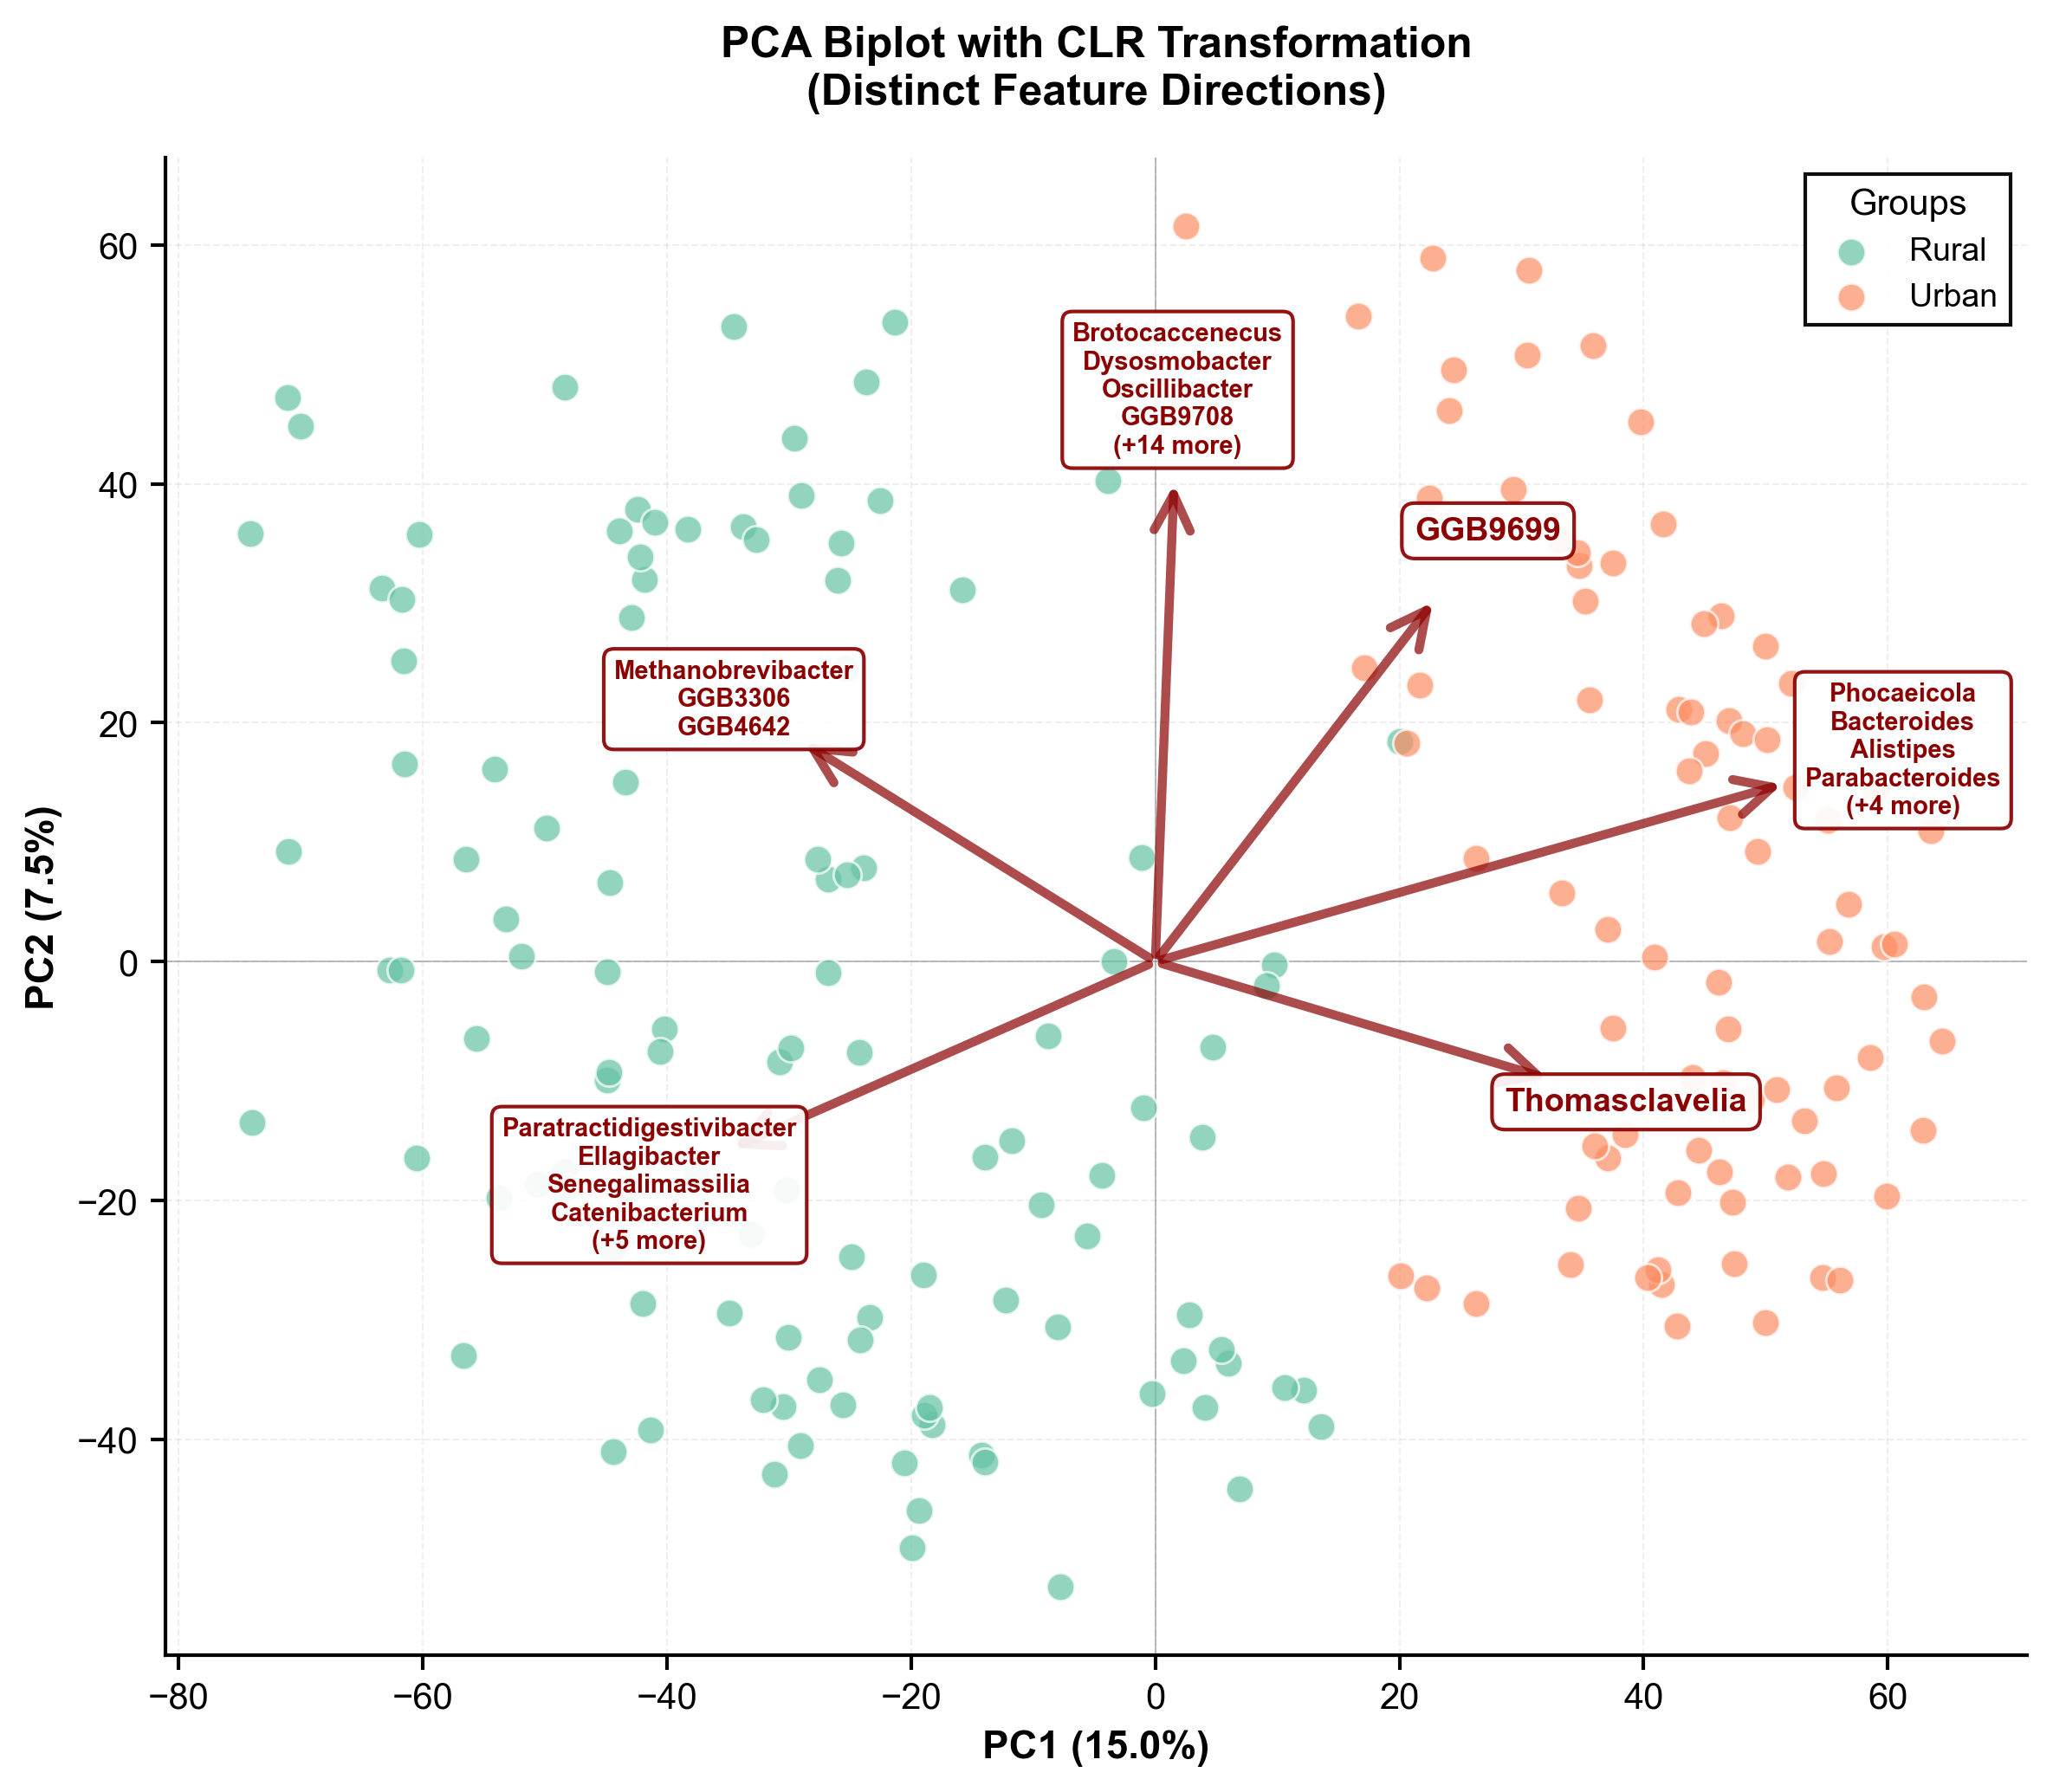

In [41]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist

# CLR transformation function
def clr_transform(X):
    """
    Apply Centered Log-Ratio (CLR) transformation to compositional data.
    
    Parameters:
    X : array-like, shape (n_samples, n_features)
        Compositional data (must be positive)
    
    Returns:
    X_clr : array, CLR-transformed data
    """
    # Add small constant to avoid log(0) if there are zeros
    X_safe = X + 1e-6
    
    # Compute geometric mean for each sample (row)
    geom_mean = np.exp(np.mean(np.log(X_safe), axis=1, keepdims=True))
    
    # CLR: log(x_i / geometric_mean)
    X_clr = np.log(X_safe / geom_mean)
    
    return X_clr

# Prepare data
X = data_sp_top.drop(columns=['label', 'age_group']).values
y = data_sp_top['label'].values
feature_names = data_sp_top.drop(columns=['label', 'age_group']).columns

# Apply CLR transformation
X_clr = clr_transform(X)

# Perform PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_clr)

# Loadings (contributions of original variables)
loadings = pca.components_.T  # shape: n_features x 2

# Compute contribution of each feature to PC1+PC2
contrib = np.linalg.norm(loadings, axis=1)  # Euclidean norm across PCs

# Select top N features by contribution
top_n = 40  # Start with more features, then cluster them
top_idx = np.argsort(contrib)[-top_n:][::-1]
top_loadings = loadings[top_idx]
top_features = feature_names[top_idx]

# Cluster features based on their loading vectors (direction in PC space)
# Use cosine distance to group features pointing in similar directions
distances = pdist(top_loadings, metric='cosine')
linkage_matrix = linkage(distances, method='average')

# Cut tree to get clusters (adjust distance_threshold to control number of groups)
distance_threshold = 0.15  # Lower = more clusters, Higher = fewer clusters
clusters = fcluster(linkage_matrix, distance_threshold, criterion='distance')

# Function to sort features: non-GGB first, then by contribution
def sort_features_priority(feat_indices, feat_names, contributions):
    """Sort features prioritizing non-GGB names first, then by contribution"""
    # Create list of (index, name, contribution, is_GGB)
    feature_info = []
    for idx in feat_indices:
        name = feat_names[idx]
        is_ggb = name.startswith('GGB')
        feature_info.append((idx, name, contributions[idx], is_ggb))
    
    # Sort: non-GGB first (is_GGB=False), then by contribution (descending)
    feature_info.sort(key=lambda x: (x[3], -x[2]))
    
    return [x[0] for x in feature_info], [x[1] for x in feature_info]

# For each cluster, select the feature with highest contribution
selected_features = []
selected_idx = []
for cluster_id in np.unique(clusters):
    cluster_mask = clusters == cluster_id
    cluster_indices = np.where(cluster_mask)[0]
    cluster_feat_idx = top_idx[cluster_indices]
    
    # Sort features in this cluster: non-GGB first, then by contribution
    sorted_indices, sorted_names = sort_features_priority(
        cluster_feat_idx, 
        feature_names, 
        contrib
    )
    
    # Select the first one (highest priority non-GGB or highest contribution)
    best_in_cluster = sorted_indices[0]
    
    selected_idx.append(best_in_cluster)
    selected_features.append(sorted_names)

print(f"Selected {len(selected_features)} distinct directions from {top_n} top features")
for i, (idx, feat_group) in enumerate(zip(selected_idx, selected_features)):
    print(f"{i+1}. Direction {i+1}: {', '.join(feat_group)}")

# Set journal-style parameters
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 10
plt.rcParams['axes.linewidth'] = 1.0
plt.rcParams['xtick.major.width'] = 1.0
plt.rcParams['ytick.major.width'] = 1.0
plt.rcParams['xtick.major.size'] = 4
plt.rcParams['ytick.major.size'] = 4

# Create figure
fig, ax = plt.subplots(figsize=(8, 7), dpi=300)

# Get unique labels and colors
labels_unique = sorted(set(y))
colors = plt.cm.Set2.colors if len(labels_unique) <= 8 else plt.cm.tab10.colors

# Add subtle grid FIRST (lowest layer)
ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.5, zorder=0)
ax.set_axisbelow(True)

# Add reference lines at origin
ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5, zorder=1)
ax.axvline(x=0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5, zorder=1)

# Scatter plot of samples
for i, group in enumerate(labels_unique):
    idx = y == group
    ax.scatter(X_pca[idx, 0], X_pca[idx, 1], 
              alpha=0.7, 
              s=60, 
              label=group,
              color=colors[i % len(colors)],
              edgecolors='white',
              linewidths=0.7,
              zorder=3)

# Draw arrows for selected features
scaling = np.max(np.abs(X_pca)) / np.max(np.abs(loadings[selected_idx])) * 0.7
texts = []

for i, (feat_idx, feat_group) in enumerate(zip(selected_idx, selected_features)):
    # Draw arrow
    ax.annotate('',
               xy=(loadings[feat_idx, 0] * scaling, loadings[feat_idx, 1] * scaling),
               xytext=(0, 0),
               arrowprops=dict(arrowstyle='->',
                             lw=2.5,
                             color='darkred',
                             mutation_scale=25,
                             alpha=0.7),
               zorder=4)
    
    # Show multiple features if they're clustered together
    # Features are already sorted with non-GGB first
    if len(feat_group) == 1:
        label_text = feat_group[0]
        fontsize = 9
    else:
        # Show up to 4 features, then add "+N more"
        max_show = 4
        if len(feat_group) <= max_show:
            label_text = '\n'.join(feat_group)
        else:
            label_text = '\n'.join(feat_group[:max_show]) + f'\n(+{len(feat_group)-max_show} more)'
        fontsize = 7  # Smaller font for multiple features
    
    # Add text label
    text_offset = 1.18
    text = ax.text(loadings[feat_idx, 0] * scaling * text_offset,
                   loadings[feat_idx, 1] * scaling * text_offset,
                   label_text,
                   fontsize=fontsize,
                   color='darkred',
                   ha='center',
                   va='center',
                   fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.4',
                           facecolor='white',
                           edgecolor='darkred',
                           alpha=0.92,
                           linewidth=1),
                   zorder=5)
    texts.append(text)

# Format axes
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', 
              fontsize=11, fontweight='bold')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', 
              fontsize=11, fontweight='bold')
ax.set_title('PCA Biplot with CLR Transformation\n(Distinct Feature Directions)', 
             fontsize=12, fontweight='bold', pad=15)

# Legend
ax.legend(frameon=True, 
          loc='best',
          fontsize=9,
          edgecolor='black',
          fancybox=False,
          shadow=False,
          framealpha=0.95,
          title='Groups',
          title_fontsize=10)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Optional: Save as high-resolution files for publication
# fig.savefig('pca_biplot_clr_distinct.pdf', dpi=300, bbox_inches='tight')
fig.savefig('pca_biplot_clr_genus_distinct.png', dpi=400, bbox_inches='tight')
# fig.savefig('pca_biplot_clr_distinct.svg', bbox_inches='tight')

Selected 7 distinct directions from 40 top features
1. Direction 1: GGB4888, Paratractidigestivibacter, GGB4672, Ellagibacter, Senegalimassilia, Catenibacterium, GGB9370, GGB3862, GGB3588
2. Direction 2: Methanobrevibacter, GGB3306
3. Direction 3: GGB4642
4. Direction 4: GGB9708, GGB9747, GGB3304, GGB143497, GGB9712, GGB9634, GGB3321, Brotocaccenecus, GGB9602, GGB9707, GGB3619, Dysosmobacter, GGB9636, GGB9691, Oscillibacter, GGB9677, GGB9618, GGB9293
5. Direction 5: Phocaeicola, Bacteroides, Alistipes, Parabacteroides, Odoribacter, Ruthenibacterium, Barnesiella, Hominiventricola
6. Direction 6: GGB9699
7. Direction 7: Thomasclavelia


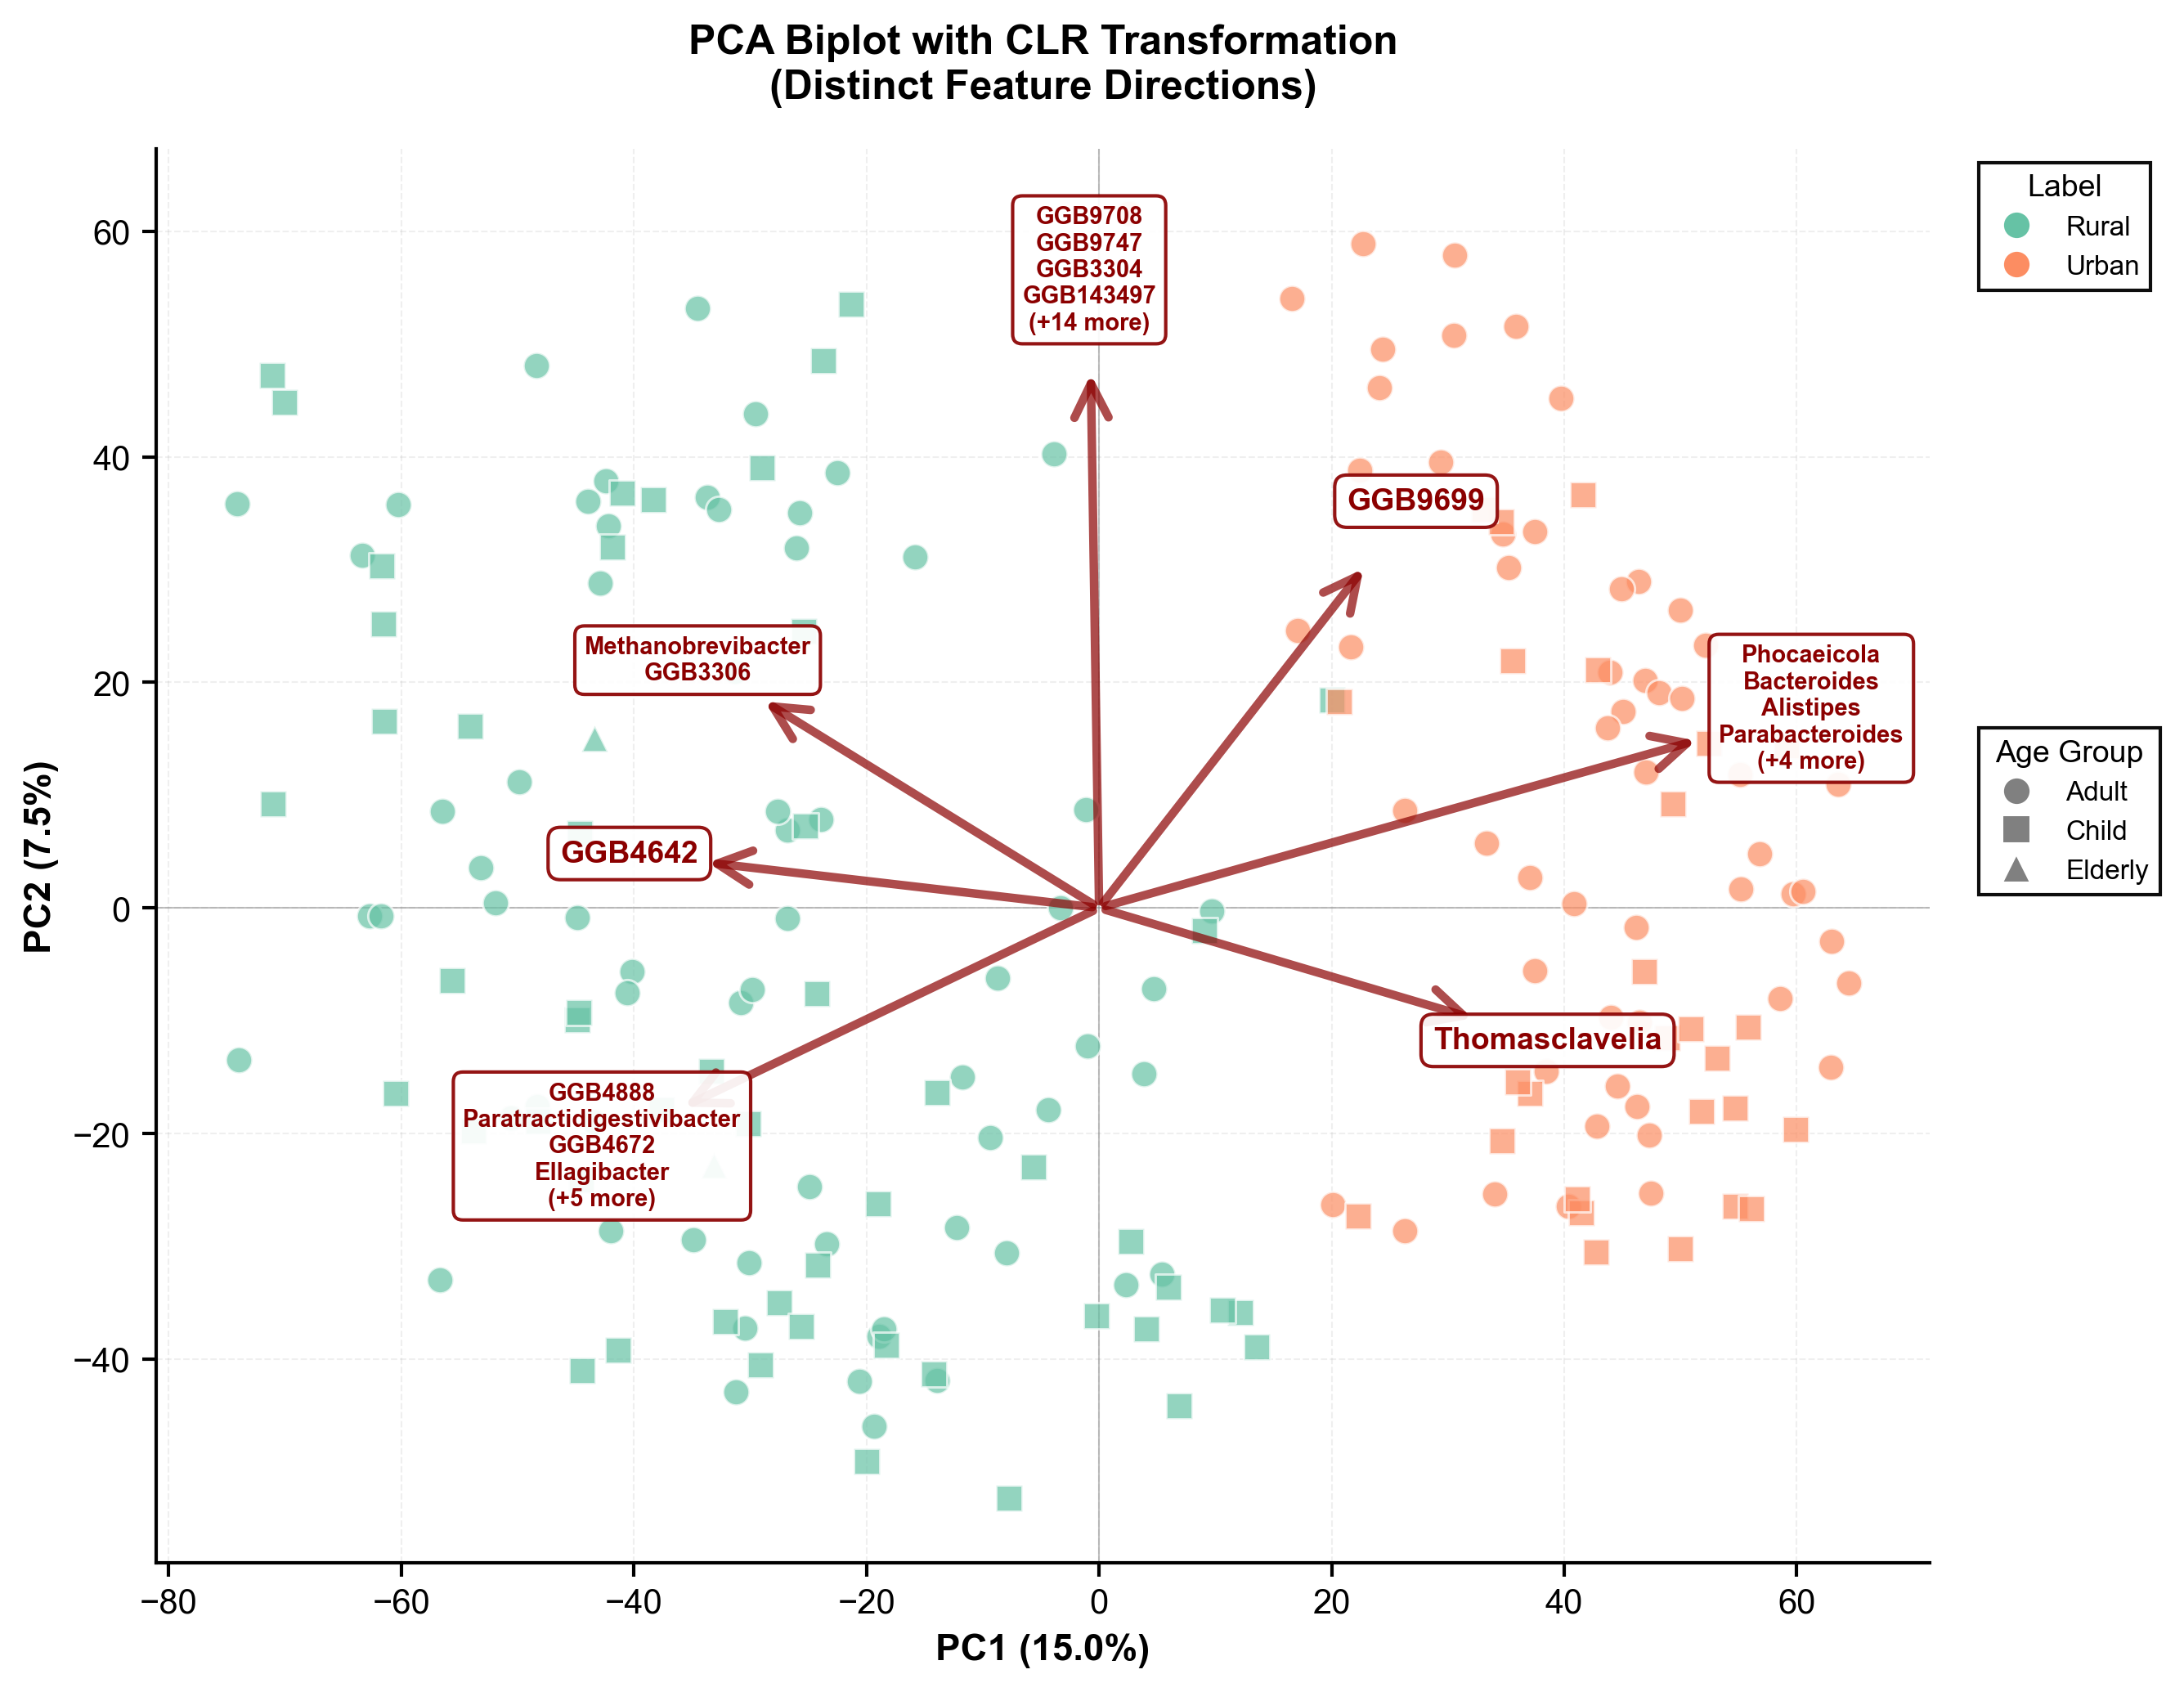

In [91]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist
from matplotlib.lines import Line2D

# CLR transformation function
def clr_transform(X):
    """
    Apply Centered Log-Ratio (CLR) transformation to compositional data.
    
    Parameters:
    X : array-like, shape (n_samples, n_features)
        Compositional data (must be positive)
    
    Returns:
    X_clr : array, CLR-transformed data
    """
    # Add small constant to avoid log(0) if there are zeros
    X_safe = X + 1e-6
    
    # Compute geometric mean for each sample (row)
    geom_mean = np.exp(np.mean(np.log(X_safe), axis=1, keepdims=True))
    
    # CLR: log(x_i / geometric_mean)
    X_clr = np.log(X_safe / geom_mean)
    
    return X_clr

# Prepare data
X = data_sp_top.drop(columns=['label', 'age_group', 'BMI']).values
y = data_sp_top['label'].values
age_group = data_sp_top['age_group'].values
feature_names = data_sp_top.drop(columns=['label', 'age_group']).columns

# Apply CLR transformation
X_clr = clr_transform(X)

# Perform PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_clr)

# Loadings (contributions of original variables)
loadings = pca.components_.T  # shape: n_features x 2

# Compute contribution of each feature to PC1+PC2
contrib = np.linalg.norm(loadings, axis=1)  # Euclidean norm across PCs

# Select top N features by contribution
top_n = 40  # Start with more features, then cluster them
top_idx = np.argsort(contrib)[-top_n:][::-1]
top_loadings = loadings[top_idx]
top_features = feature_names[top_idx]

# Cluster features based on their loading vectors (direction in PC space)
# Use cosine distance to group features pointing in similar directions
distances = pdist(top_loadings, metric='cosine')
linkage_matrix = linkage(distances, method='average')

# Cut tree to get clusters (adjust distance_threshold to control number of groups)
distance_threshold = 0.1  # Lower = more clusters, Higher = fewer clusters
clusters = fcluster(linkage_matrix, distance_threshold, criterion='distance')

# For each cluster, select the feature with highest contribution
selected_features = []
selected_idx = []
for cluster_id in np.unique(clusters):
    cluster_mask = clusters == cluster_id
    cluster_indices = np.where(cluster_mask)[0]
    
    # Find feature with max contribution in this cluster
    cluster_contrib = contrib[top_idx[cluster_indices]]
    best_in_cluster = cluster_indices[np.argmax(cluster_contrib)]
    
    selected_idx.append(top_idx[best_in_cluster])
    
    # Get all features in this cluster for labeling
    cluster_features = [feature_names[top_idx[i]] for i in cluster_indices]
    selected_features.append(cluster_features)

print(f"Selected {len(selected_features)} distinct directions from {top_n} top features")
for i, (idx, feat_group) in enumerate(zip(selected_idx, selected_features)):
    print(f"{i+1}. Direction {i+1}: {', '.join(feat_group)}")

# Set journal-style parameters
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 10
plt.rcParams['axes.linewidth'] = 1.0
plt.rcParams['xtick.major.width'] = 1.0
plt.rcParams['ytick.major.width'] = 1.0
plt.rcParams['xtick.major.size'] = 4
plt.rcParams['ytick.major.size'] = 4

# Create figure
fig, ax = plt.subplots(figsize=(9, 7), dpi=300)

# Get unique labels and colors
labels_unique = sorted(set(y))
colors = plt.cm.Set2.colors if len(labels_unique) <= 8 else plt.cm.tab10.colors

# Get unique age groups and markers
age_groups_unique = sorted(set(age_group))
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']

# Add subtle grid FIRST (lowest layer)
ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.5, zorder=0)
ax.set_axisbelow(True)

# Add reference lines at origin
ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5, zorder=1)
ax.axvline(x=0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5, zorder=1)

# Scatter plot of samples with both label (color) and age group (marker)
for i, group in enumerate(labels_unique):
    for j, age in enumerate(age_groups_unique):
        idx = (y == group) & (age_group == age)
        if np.any(idx):
            ax.scatter(X_pca[idx, 0], X_pca[idx, 1], 
                      alpha=0.7, 
                      s=60, 
                      color=colors[i % len(colors)],
                      marker=markers[j % len(markers)],
                      edgecolors='white',
                      linewidths=0.7,
                      zorder=3)

# Draw arrows for selected features
scaling = np.max(np.abs(X_pca)) / np.max(np.abs(loadings[selected_idx])) * 0.7
texts = []

for i, (feat_idx, feat_group) in enumerate(zip(selected_idx, selected_features)):
    # Draw arrow
    ax.annotate('',
               xy=(loadings[feat_idx, 0] * scaling, loadings[feat_idx, 1] * scaling),
               xytext=(0, 0),
               arrowprops=dict(arrowstyle='->',
                             lw=2.5,
                             color='darkred',
                             mutation_scale=25,
                             alpha=0.7),
               zorder=4)
    
    # Show multiple features if they're clustered together
    if len(feat_group) == 1:
        label_text = feat_group[0]
        fontsize = 9
    else:
        # Show up to 4 features, then add "+N more"
        max_show = 4
        if len(feat_group) <= max_show:
            label_text = '\n'.join(feat_group)
        else:
            label_text = '\n'.join(feat_group[:max_show]) + f'\n(+{len(feat_group)-max_show} more)'
        fontsize = 7  # Smaller font for multiple features
    
    # Add text label
    text_offset = 1.18
    text = ax.text(loadings[feat_idx, 0] * scaling * text_offset,
                   loadings[feat_idx, 1] * scaling * text_offset,
                   label_text,
                   fontsize=fontsize,
                   color='darkred',
                   ha='center',
                   va='center',
                   fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.4',
                           facecolor='white',
                           edgecolor='darkred',
                           alpha=0.92,
                           linewidth=1),
                   zorder=5)
    texts.append(text)

# Format axes
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', 
              fontsize=11, fontweight='bold')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', 
              fontsize=11, fontweight='bold')
ax.set_title('PCA Biplot with CLR Transformation\n(Distinct Feature Directions)', 
             fontsize=12, fontweight='bold', pad=15)

# Create custom legend elements
# Legend for labels (colors)
label_legend_elements = [Line2D([0], [0], marker='o', color='w', 
                                markerfacecolor=colors[i % len(colors)], 
                                markersize=8, label=lbl,
                                markeredgecolor='white', markeredgewidth=0.5)
                        for i, lbl in enumerate(labels_unique)]

# Legend for age groups (markers)
age_legend_elements = [Line2D([0], [0], marker=markers[j % len(markers)], 
                              color='w', markerfacecolor='gray', 
                              markersize=8, label=age,
                              markeredgecolor='white', markeredgewidth=0.5)
                      for j, age in enumerate(age_groups_unique)]

# Add first legend (labels)
first_legend = ax.legend(handles=label_legend_elements, 
                        title='Label',
                        loc='upper left',
                        bbox_to_anchor=(1.02, 1),
                        fontsize=8,
                        title_fontsize=9,
                        frameon=True,
                        edgecolor='black',
                        fancybox=False,
                        framealpha=0.95)

# Add second legend (age groups)
ax.add_artist(first_legend)  # Keep first legend
ax.legend(handles=age_legend_elements,
         title='Age Group',
         loc='upper left',
         bbox_to_anchor=(1.02, 0.6),
         fontsize=8,
         title_fontsize=9,
         frameon=True,
         edgecolor='black',
         fancybox=False,
         framealpha=0.95)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Optional: Save as high-resolution files for publication
# fig.savefig('pca_biplot_clr_distinct.pdf', dpi=300, bbox_inches='tight')
fig.savefig('pca_biplot_clr_genus_distinct_age.png', dpi=400, bbox_inches='tight')
# fig.savefig('pca_biplot_clr_distinct.svg', bbox_inches='tight')

Selected 7 distinct directions from 40 top features
1. Direction 1: GGB4888, Paratractidigestivibacter, GGB4672, Ellagibacter, Senegalimassilia, Catenibacterium, GGB9370, GGB3862, GGB3588
2. Direction 2: Methanobrevibacter, GGB3306
3. Direction 3: GGB4642
4. Direction 4: GGB9708, GGB9747, GGB3304, GGB143497, GGB9712, GGB9634, GGB3321, Brotocaccenecus, GGB9602, GGB9707, GGB3619, Dysosmobacter, GGB9636, GGB9691, Oscillibacter, GGB9677, GGB9618, GGB9293
5. Direction 5: Phocaeicola, Bacteroides, Alistipes, Parabacteroides, Odoribacter, Ruthenibacterium, Barnesiella, Hominiventricola
6. Direction 6: GGB9699
7. Direction 7: Thomasclavelia


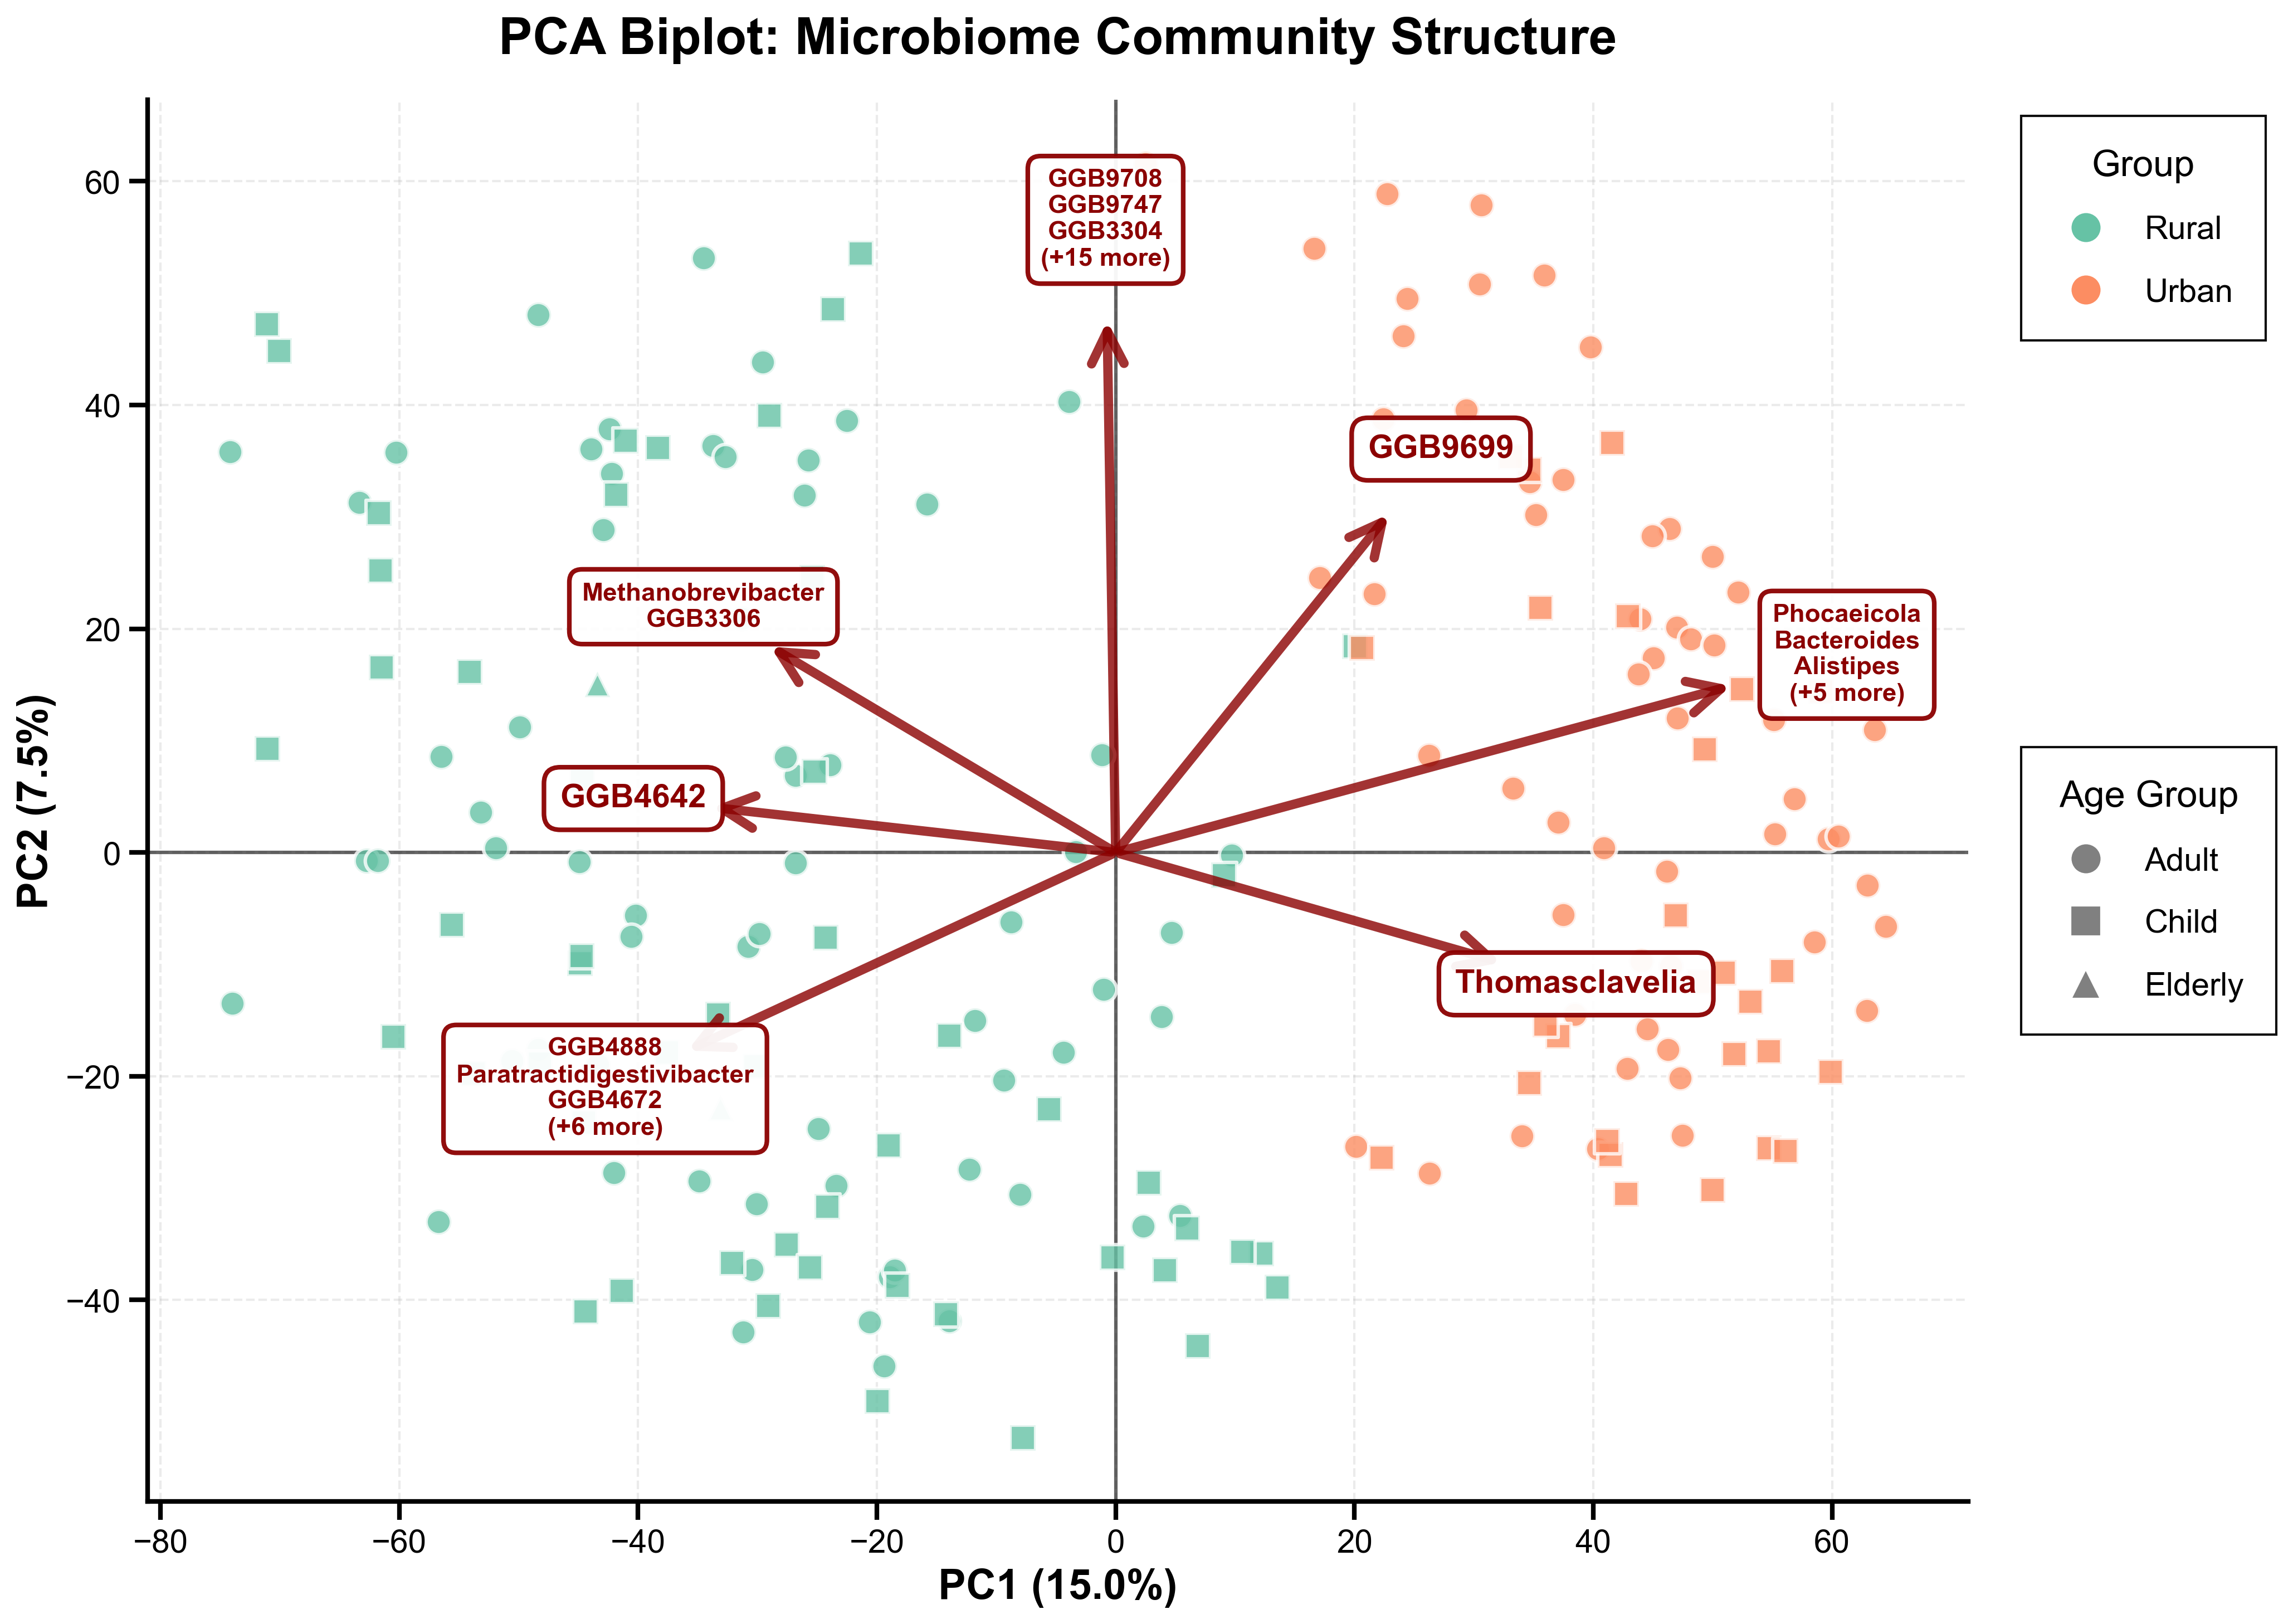

In [93]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist
from matplotlib.lines import Line2D

# CLR transformation function
def clr_transform(X):
    """
    Apply Centered Log-Ratio (CLR) transformation to compositional data.
    
    Parameters:
    X : array-like, shape (n_samples, n_features)
        Compositional data (must be positive)
    
    Returns:
    X_clr : array, CLR-transformed data
    """
    # Add small constant to avoid log(0) if there are zeros
    X_safe = X + 1e-6
    
    # Compute geometric mean for each sample (row)
    geom_mean = np.exp(np.mean(np.log(X_safe), axis=1, keepdims=True))
    
    # CLR: log(x_i / geometric_mean)
    X_clr = np.log(X_safe / geom_mean)
    
    return X_clr

# Prepare data
X = data_sp_top.drop(columns=['label', 'age_group', 'BMI']).values
y = data_sp_top['label'].values
age_group = data_sp_top['age_group'].values
feature_names = data_sp_top.drop(columns=['label', 'age_group', 'BMI']).columns

# Apply CLR transformation
X_clr = clr_transform(X)

# Perform PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_clr)

# Loadings (contributions of original variables)
loadings = pca.components_.T  # shape: n_features x 2

# Compute contribution of each feature to PC1+PC2
contrib = np.linalg.norm(loadings, axis=1)  # Euclidean norm across PCs

# Select top N features by contribution
top_n = 40  # Start with more features, then cluster them
top_idx = np.argsort(contrib)[-top_n:][::-1]
top_loadings = loadings[top_idx]
top_features = feature_names[top_idx]

# Cluster features based on their loading vectors (direction in PC space)
# Use cosine distance to group features pointing in similar directions
distances = pdist(top_loadings, metric='cosine')
linkage_matrix = linkage(distances, method='average')

# Cut tree to get clusters (adjust distance_threshold to control number of groups)
distance_threshold = 0.1  # Lower = more clusters, Higher = fewer clusters
clusters = fcluster(linkage_matrix, distance_threshold, criterion='distance')

# For each cluster, select the feature with highest contribution
selected_features = []
selected_idx = []
for cluster_id in np.unique(clusters):
    cluster_mask = clusters == cluster_id
    cluster_indices = np.where(cluster_mask)[0]
    
    # Find feature with max contribution in this cluster
    cluster_contrib = contrib[top_idx[cluster_indices]]
    best_in_cluster = cluster_indices[np.argmax(cluster_contrib)]
    
    selected_idx.append(top_idx[best_in_cluster])
    
    # Get all features in this cluster for labeling
    cluster_features = [feature_names[top_idx[i]] for i in cluster_indices]
    selected_features.append(cluster_features)

print(f"Selected {len(selected_features)} distinct directions from {top_n} top features")
for i, (idx, feat_group) in enumerate(zip(selected_idx, selected_features)):
    print(f"{i+1}. Direction {i+1}: {', '.join(feat_group)}")

# Set poster-style parameters (LARGER for visibility)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['font.size'] = 16  # Increased from 10
plt.rcParams['axes.linewidth'] = 2.0  # Thicker axes
plt.rcParams['xtick.major.width'] = 2.0
plt.rcParams['ytick.major.width'] = 2.0
plt.rcParams['xtick.major.size'] = 8  # Larger ticks
plt.rcParams['ytick.major.size'] = 8
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14

# Create figure - LARGER for poster
fig, ax = plt.subplots(figsize=(14, 10), dpi=300)

# Get unique labels and colors - ORIGINAL colors restored
labels_unique = sorted(set(y))
colors = plt.cm.Set2.colors if len(labels_unique) <= 8 else plt.cm.tab10.colors

# Get unique age groups and markers
age_groups_unique = sorted(set(age_group))
markers = ['o', 's', '^', 'D', 'v', 'p', '*', 'h']

# Add subtle grid FIRST (lowest layer)
ax.grid(True, alpha=0.25, linestyle='--', linewidth=1, zorder=0)
ax.set_axisbelow(True)

# Add reference lines at origin - thicker for poster
ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5, alpha=0.6, zorder=1)
ax.axvline(x=0, color='black', linestyle='-', linewidth=1.5, alpha=0.6, zorder=1)

# Scatter plot of samples with both label (color) and age group (marker)
# LARGER points for poster visibility
for i, group in enumerate(labels_unique):
    for j, age in enumerate(age_groups_unique):
        idx = (y == group) & (age_group == age)
        if np.any(idx):
            ax.scatter(X_pca[idx, 0], X_pca[idx, 1], 
                      alpha=0.8,  # Slightly more opaque
                      s=120,  # MUCH larger points (was 60)
                      color=colors[i % len(colors)],
                      marker=markers[j % len(markers)],
                      edgecolors='white',
                      linewidths=1.5,  # Thicker edges
                      zorder=3)

# Draw arrows for selected features - THICKER for poster
scaling = np.max(np.abs(X_pca)) / np.max(np.abs(loadings[selected_idx])) * 0.7
texts = []

for i, (feat_idx, feat_group) in enumerate(zip(selected_idx, selected_features)):
    # Draw arrow - THICKER
    ax.annotate('',
               xy=(loadings[feat_idx, 0] * scaling, loadings[feat_idx, 1] * scaling),
               xytext=(0, 0),
               arrowprops=dict(arrowstyle='->',
                             lw=4,  # Much thicker (was 2.5)
                             color='darkred',
                             mutation_scale=35,  # Larger arrowhead (was 25)
                             alpha=0.8),
               zorder=4)
    
    # Show multiple features if they're clustered together
    if len(feat_group) == 1:
        label_text = feat_group[0]
        fontsize = 14  # Larger (was 9)
    else:
        # Show up to 3 features for poster (was 4)
        max_show = 3
        if len(feat_group) <= max_show:
            label_text = '\n'.join(feat_group)
        else:
            label_text = '\n'.join(feat_group[:max_show]) + f'\n(+{len(feat_group)-max_show} more)'
        fontsize = 11  # Larger (was 7)
    
    # Add text label - LARGER and more visible
    text_offset = 1.18
    text = ax.text(loadings[feat_idx, 0] * scaling * text_offset,
                   loadings[feat_idx, 1] * scaling * text_offset,
                   label_text,
                   fontsize=fontsize,
                   color='darkred',
                   ha='center',
                   va='center',
                   fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.5',  # More padding
                           facecolor='white',
                           edgecolor='darkred',
                           alpha=0.95,  # More opaque
                           linewidth=2),  # Thicker border
                   zorder=5)
    texts.append(text)

# Format axes - LARGER fonts for poster
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', 
              fontsize=18, fontweight='bold')  # Much larger (was 11)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', 
              fontsize=18, fontweight='bold')
ax.set_title('PCA Biplot: Microbiome Community Structure', 
             fontsize=22, fontweight='bold', pad=20)  # Simplified title, larger

# Create custom legend elements - LARGER for poster
# Legend for labels (colors)
label_legend_elements = [Line2D([0], [0], marker='o', color='w', 
                                markerfacecolor=colors[i % len(colors)], 
                                markersize=14,  # Larger (was 8)
                                label=lbl,
                                markeredgecolor='white', 
                                markeredgewidth=1.5)
                        for i, lbl in enumerate(labels_unique)]

# Legend for age groups (markers)
age_legend_elements = [Line2D([0], [0], marker=markers[j % len(markers)], 
                              color='w', markerfacecolor='gray', 
                              markersize=14,  # Larger (was 8)
                              label=age,
                              markeredgecolor='white', 
                              markeredgewidth=1.5)
                      for j, age in enumerate(age_groups_unique)]

# Add first legend (labels) - LARGER
first_legend = ax.legend(handles=label_legend_elements, 
                        title='Group',
                        loc='upper left',
                        bbox_to_anchor=(1.02, 1),
                        fontsize=14,  # Larger (was 8)
                        title_fontsize=16,  # Larger (was 9)
                        frameon=True,
                        edgecolor='black',
                        fancybox=False,
                        framealpha=0.95,
                        borderpad=1,  # More padding
                        labelspacing=1)  # More space between items

# Add second legend (age groups) - LARGER
ax.add_artist(first_legend)  # Keep first legend
ax.legend(handles=age_legend_elements,
         title='Age Group',
         loc='upper left',
         bbox_to_anchor=(1.02, 0.55),
         fontsize=14,
         title_fontsize=16,
         frameon=True,
         edgecolor='black',
         fancybox=False,
         framealpha=0.95,
         borderpad=1,
         labelspacing=1)

# Remove top and right spines - THICKER
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Save for poster - HIGH RESOLUTION
fig.savefig('pca_biplot_poster.png', dpi=600, bbox_inches='tight')  # Very high DPI for printing
fig.savefig('pca_biplot_poster.pdf', dpi=600, bbox_inches='tight')  # PDF for best quality
# fig.savefig('pca_biplot_poster.svg', bbox_inches='tight')  # Vector format

Selected 4 distinct directions from 30 top features
1. Direction 1: GGB4888, Paratractidigestivibacter, GGB4672, Ellagibacter, Senegalimassilia
2. Direction 2: Phocaeicola, Bacteroides, Alistipes, Parabacteroides, Odoribacter, Ruthenibacterium, Barnesiella
3. Direction 3: GGB9708, GGB9747, GGB3304, GGB143497, GGB9712, GGB9634, GGB3321, Brotocaccenecus, GGB9602, GGB3619, GGB9636, GGB9691, Oscillibacter, GGB9677, GGB9618
4. Direction 4: GGB9707, GGB9699, Dysosmobacter


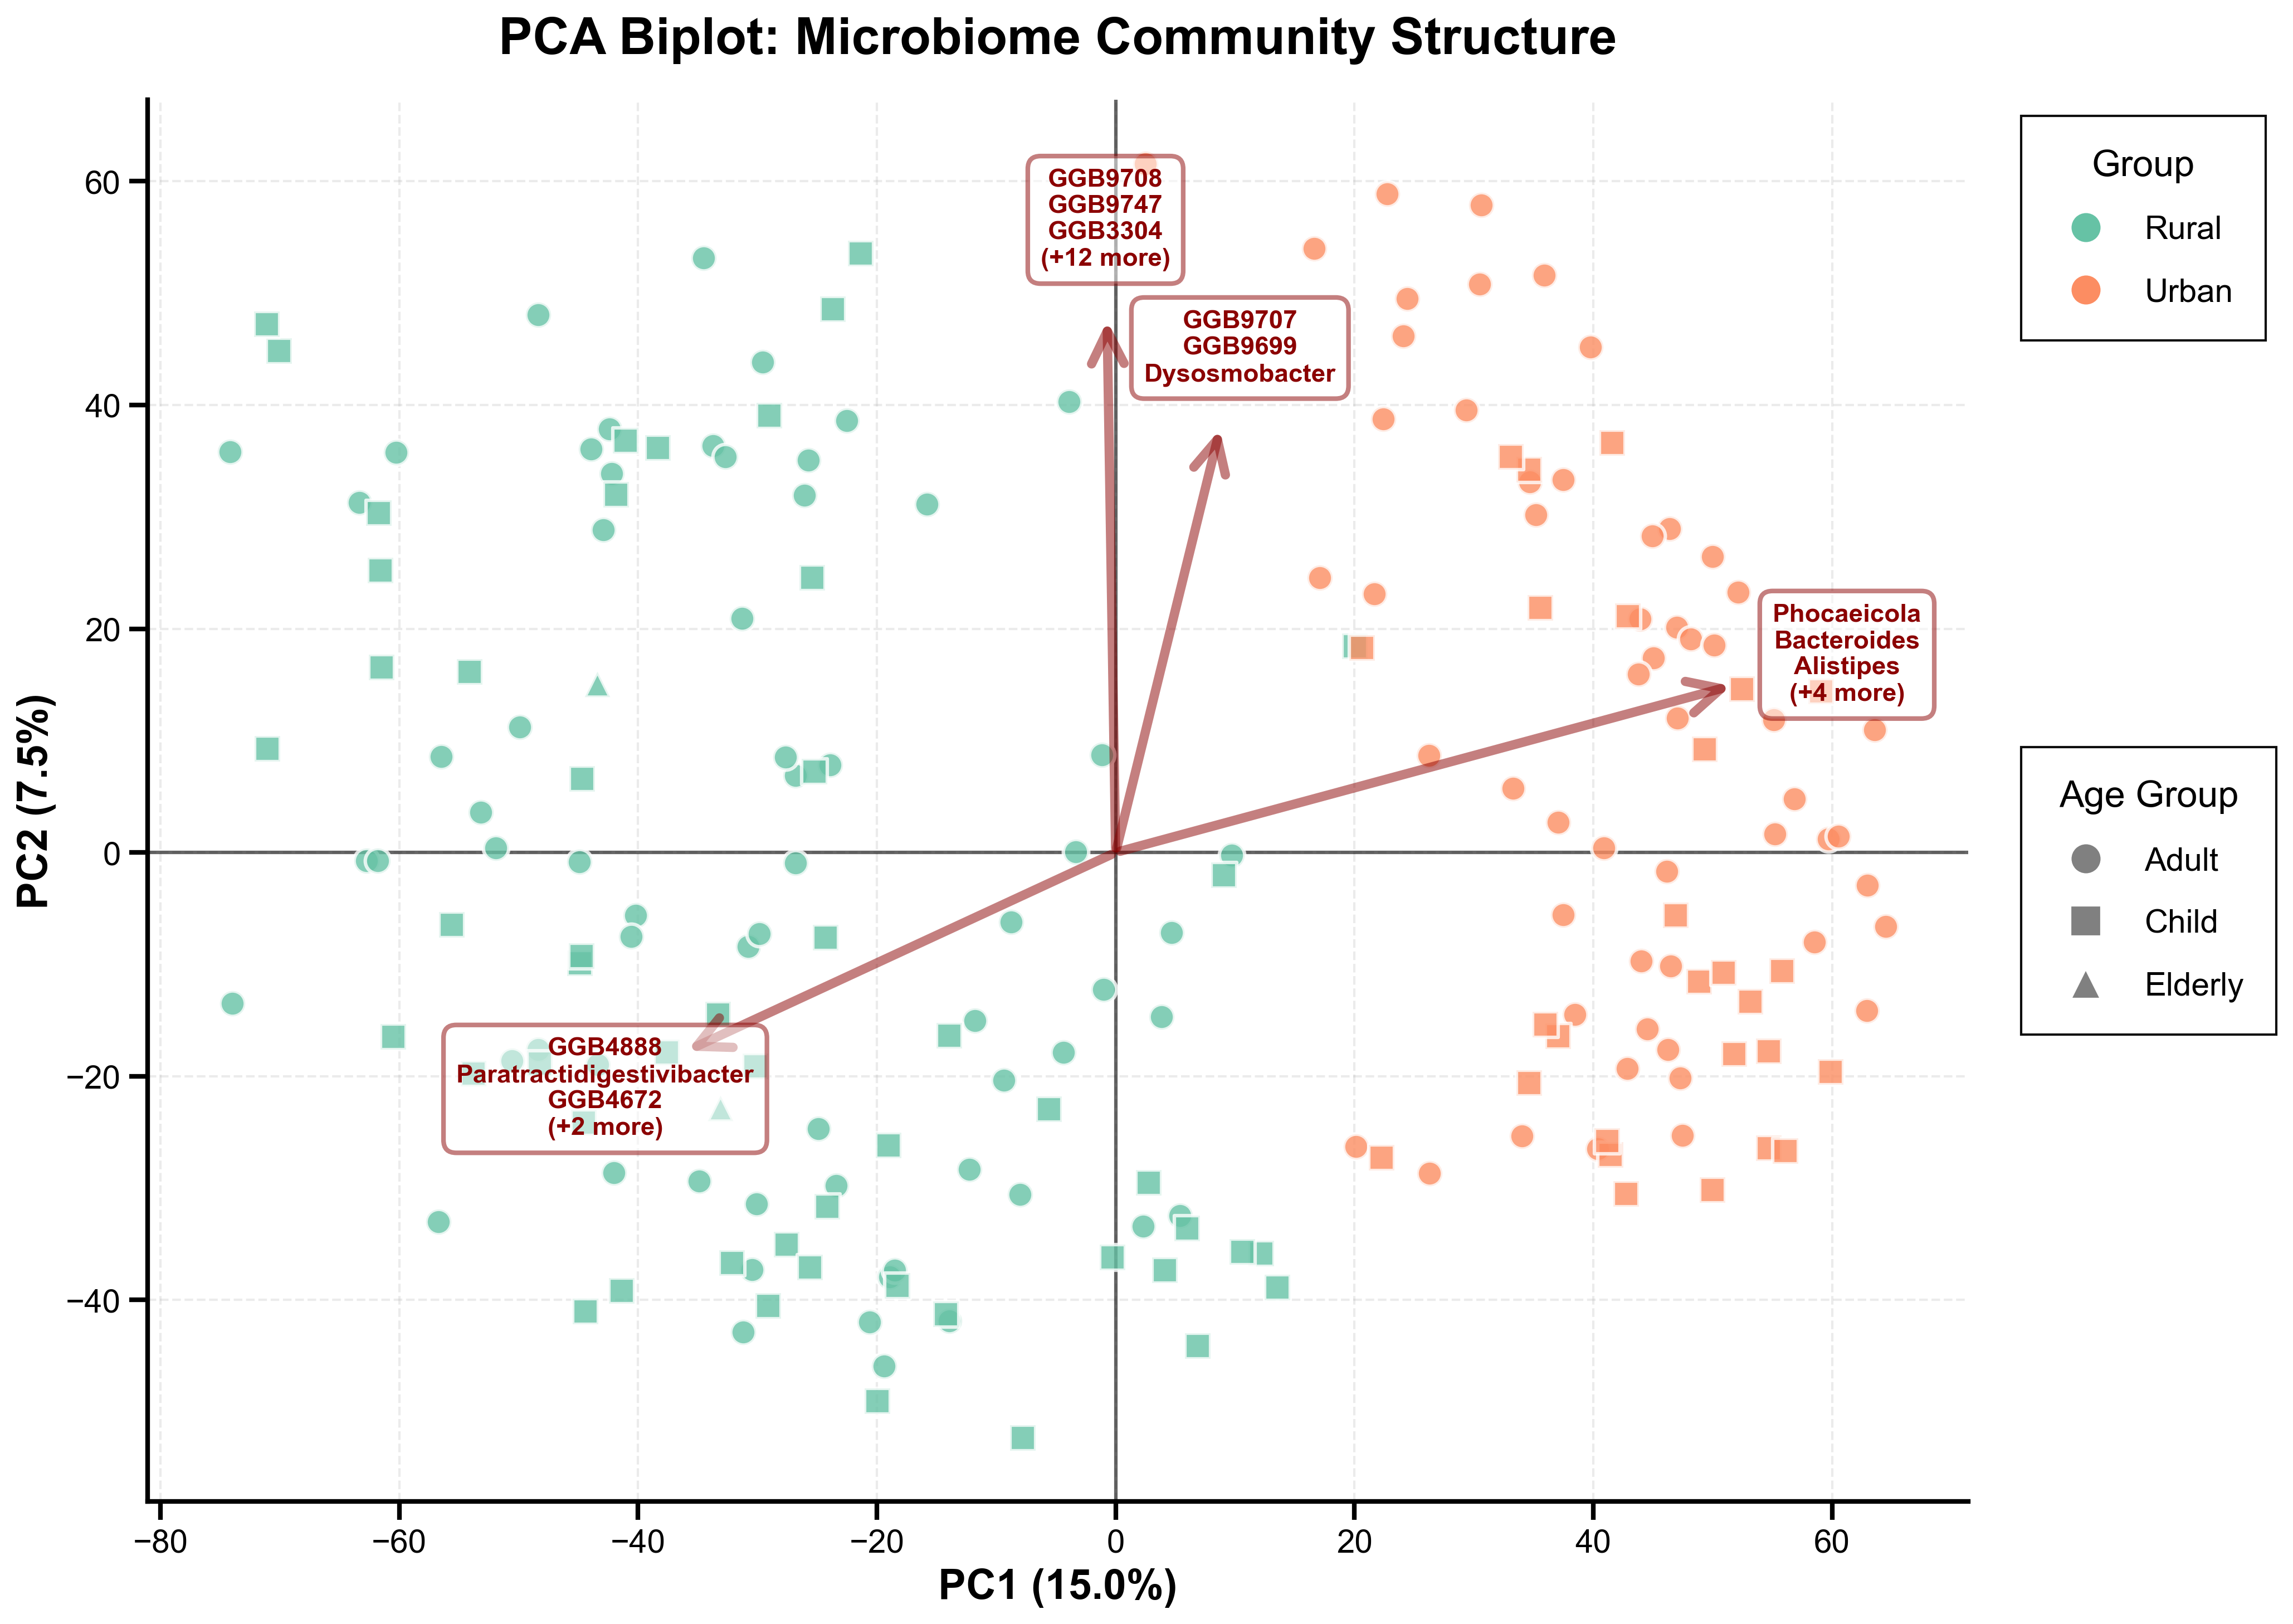

In [96]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist
from matplotlib.lines import Line2D

# CLR transformation function
def clr_transform(X):
    """
    Apply Centered Log-Ratio (CLR) transformation to compositional data.
    
    Parameters:
    X : array-like, shape (n_samples, n_features)
        Compositional data (must be positive)
    
    Returns:
    X_clr : array, CLR-transformed data
    """
    # Add small constant to avoid log(0) if there are zeros
    X_safe = X + 1e-6
    
    # Compute geometric mean for each sample (row)
    geom_mean = np.exp(np.mean(np.log(X_safe), axis=1, keepdims=True))
    
    # CLR: log(x_i / geometric_mean)
    X_clr = np.log(X_safe / geom_mean)
    
    return X_clr

# Prepare data
X = data_sp_top.drop(columns=['label', 'age_group', 'BMI']).values
y = data_sp_top['label'].values
age_group = data_sp_top['age_group'].values
feature_names = data_sp_top.drop(columns=['label', 'age_group', 'BMI']).columns

# Apply CLR transformation
X_clr = clr_transform(X)

# Perform PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_clr)

# Loadings (contributions of original variables)
loadings = pca.components_.T  # shape: n_features x 2

# Compute contribution of each feature to PC1+PC2
contrib = np.linalg.norm(loadings, axis=1)  # Euclidean norm across PCs

# Select top N features by contribution
top_n = 30  # Start with more features, then cluster them
top_idx = np.argsort(contrib)[-top_n:][::-1]
top_loadings = loadings[top_idx]
top_features = feature_names[top_idx]

# Cluster features based on their loading vectors (direction in PC space)
# Use cosine distance to group features pointing in similar directions
distances = pdist(top_loadings, metric='cosine')
linkage_matrix = linkage(distances, method='average')

# Cut tree to get clusters (adjust distance_threshold to control number of groups)
distance_threshold = 0.1  # Lower = more clusters, Higher = fewer clusters
clusters = fcluster(linkage_matrix, distance_threshold, criterion='distance')

# For each cluster, select the feature with highest contribution
selected_features = []
selected_idx = []
for cluster_id in np.unique(clusters):
    cluster_mask = clusters == cluster_id
    cluster_indices = np.where(cluster_mask)[0]
    
    # Find feature with max contribution in this cluster
    cluster_contrib = contrib[top_idx[cluster_indices]]
    best_in_cluster = cluster_indices[np.argmax(cluster_contrib)]
    
    selected_idx.append(top_idx[best_in_cluster])
    
    # Get all features in this cluster for labeling
    cluster_features = [feature_names[top_idx[i]] for i in cluster_indices]
    selected_features.append(cluster_features)

print(f"Selected {len(selected_features)} distinct directions from {top_n} top features")
for i, (idx, feat_group) in enumerate(zip(selected_idx, selected_features)):
    print(f"{i+1}. Direction {i+1}: {', '.join(feat_group)}")

# Set poster-style parameters (LARGER for visibility)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['font.size'] = 16  # Increased from 10
plt.rcParams['axes.linewidth'] = 2.0  # Thicker axes
plt.rcParams['xtick.major.width'] = 2.0
plt.rcParams['ytick.major.width'] = 2.0
plt.rcParams['xtick.major.size'] = 8  # Larger ticks
plt.rcParams['ytick.major.size'] = 8
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14

# Create figure - LARGER for poster
fig, ax = plt.subplots(figsize=(14, 10), dpi=300)

# Get unique labels and colors - ORIGINAL colors restored
labels_unique = sorted(set(y))
colors = plt.cm.Set2.colors if len(labels_unique) <= 8 else plt.cm.tab10.colors

# Get unique age groups and markers
age_groups_unique = sorted(set(age_group))
markers = ['o', 's', '^', 'D', 'v', 'p', '*', 'h']

# Add subtle grid FIRST (lowest layer)
ax.grid(True, alpha=0.25, linestyle='--', linewidth=1, zorder=0)
ax.set_axisbelow(True)

# Add reference lines at origin - thicker for poster
ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5, alpha=0.6, zorder=1)
ax.axvline(x=0, color='black', linestyle='-', linewidth=1.5, alpha=0.6, zorder=1)

# Scatter plot of samples with both label (color) and age group (marker)
# LARGER points for poster visibility
for i, group in enumerate(labels_unique):
    for j, age in enumerate(age_groups_unique):
        idx = (y == group) & (age_group == age)
        if np.any(idx):
            ax.scatter(X_pca[idx, 0], X_pca[idx, 1], 
                      alpha=0.8,  # Slightly more opaque
                      s=120,  # MUCH larger points (was 60)
                      color=colors[i % len(colors)],
                      marker=markers[j % len(markers)],
                      edgecolors='white',
                      linewidths=1.5,  # Thicker edges
                      zorder=3)

# Draw arrows for selected features - THICKER for poster
scaling = np.max(np.abs(X_pca)) / np.max(np.abs(loadings[selected_idx])) * 0.7
texts = []

for i, (feat_idx, feat_group) in enumerate(zip(selected_idx, selected_features)):
    # Draw arrow - THICKER
    ax.annotate('',
               xy=(loadings[feat_idx, 0] * scaling, loadings[feat_idx, 1] * scaling),
               xytext=(0, 0),
               arrowprops=dict(arrowstyle='->',
                             lw=4,  # Much thicker (was 2.5)
                             color='darkred',
                             mutation_scale=35,  # Larger arrowhead (was 25)
                             alpha=0.5),
               zorder=4)
    
    # Show multiple features if they're clustered together
    if len(feat_group) == 1:
        label_text = feat_group[0]
        fontsize = 12  # Larger (was 9)
    else:
        # Show up to 3 features for poster (was 4)
        max_show = 3
        if len(feat_group) <= max_show:
            label_text = '\n'.join(feat_group)
        else:
            label_text = '\n'.join(feat_group[:max_show]) + f'\n(+{len(feat_group)-max_show} more)'
        fontsize = 11  # Larger (was 7)
    
    # Add text label - LARGER and more visible
    text_offset = 1.18
    text = ax.text(loadings[feat_idx, 0] * scaling * text_offset,
                   loadings[feat_idx, 1] * scaling * text_offset,
                   label_text,
                   fontsize=fontsize,
                   color='darkred',
                   ha='center',
                   va='center',
                   fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.5',  # More padding
                           facecolor='white',
                           edgecolor='darkred',
                           alpha=0.5,  # More opaque
                           linewidth=2),  # Thicker border
                   zorder=5)
    texts.append(text)

# Format axes - LARGER fonts for poster
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', 
              fontsize=18, fontweight='bold')  # Much larger (was 11)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', 
              fontsize=18, fontweight='bold')
ax.set_title('PCA Biplot: Microbiome Community Structure', 
             fontsize=22, fontweight='bold', pad=20)  # Simplified title, larger

# Create custom legend elements - LARGER for poster
# Legend for labels (colors)
label_legend_elements = [Line2D([0], [0], marker='o', color='w', 
                                markerfacecolor=colors[i % len(colors)], 
                                markersize=14,  # Larger (was 8)
                                label=lbl,
                                markeredgecolor='white', 
                                markeredgewidth=1.5)
                        for i, lbl in enumerate(labels_unique)]

# Legend for age groups (markers)
age_legend_elements = [Line2D([0], [0], marker=markers[j % len(markers)], 
                              color='w', markerfacecolor='gray', 
                              markersize=14,  # Larger (was 8)
                              label=age,
                              markeredgecolor='white', 
                              markeredgewidth=1.5)
                      for j, age in enumerate(age_groups_unique)]

# Add first legend (labels) - LARGER
first_legend = ax.legend(handles=label_legend_elements, 
                        title='Group',
                        loc='upper left',
                        bbox_to_anchor=(1.02, 1),
                        fontsize=14,  # Larger (was 8)
                        title_fontsize=16,  # Larger (was 9)
                        frameon=True,
                        edgecolor='black',
                        fancybox=False,
                        framealpha=0.95,
                        borderpad=1,  # More padding
                        labelspacing=1)  # More space between items

# Add second legend (age groups) - LARGER
ax.add_artist(first_legend)  # Keep first legend
ax.legend(handles=age_legend_elements,
         title='Age Group',
         loc='upper left',
         bbox_to_anchor=(1.02, 0.55),
         fontsize=14,
         title_fontsize=16,
         frameon=True,
         edgecolor='black',
         fancybox=False,
         framealpha=0.95,
         borderpad=1,
         labelspacing=1)

# Remove top and right spines - THICKER
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Save for poster - HIGH RESOLUTION
#fig.savefig('pca_biplot_poster.png', dpi=600, bbox_inches='tight')  # Very high DPI for printing
#fig.savefig('pca_biplot_poster.pdf', dpi=600, bbox_inches='tight')  # PDF for best quality
# fig.savefig('pca_biplot_poster.svg', bbox_inches='tight')  # Vector format

Selected 4 distinct directions from 30 top features
1. Direction 1: GGB4888, Paratractidigestivibacter, GGB4672, Ellagibacter, Senegalimassilia
2. Direction 2: Phocaeicola, Bacteroides, Alistipes, Parabacteroides, Odoribacter, Ruthenibacterium, Barnesiella
3. Direction 3: GGB9708, GGB9747, GGB3304, GGB143497, GGB9712, GGB9634, GGB3321, Brotocaccenecus, GGB9602, GGB3619, GGB9636, GGB9691, Oscillibacter, GGB9677, GGB9618
4. Direction 4: GGB9707, GGB9699, Dysosmobacter


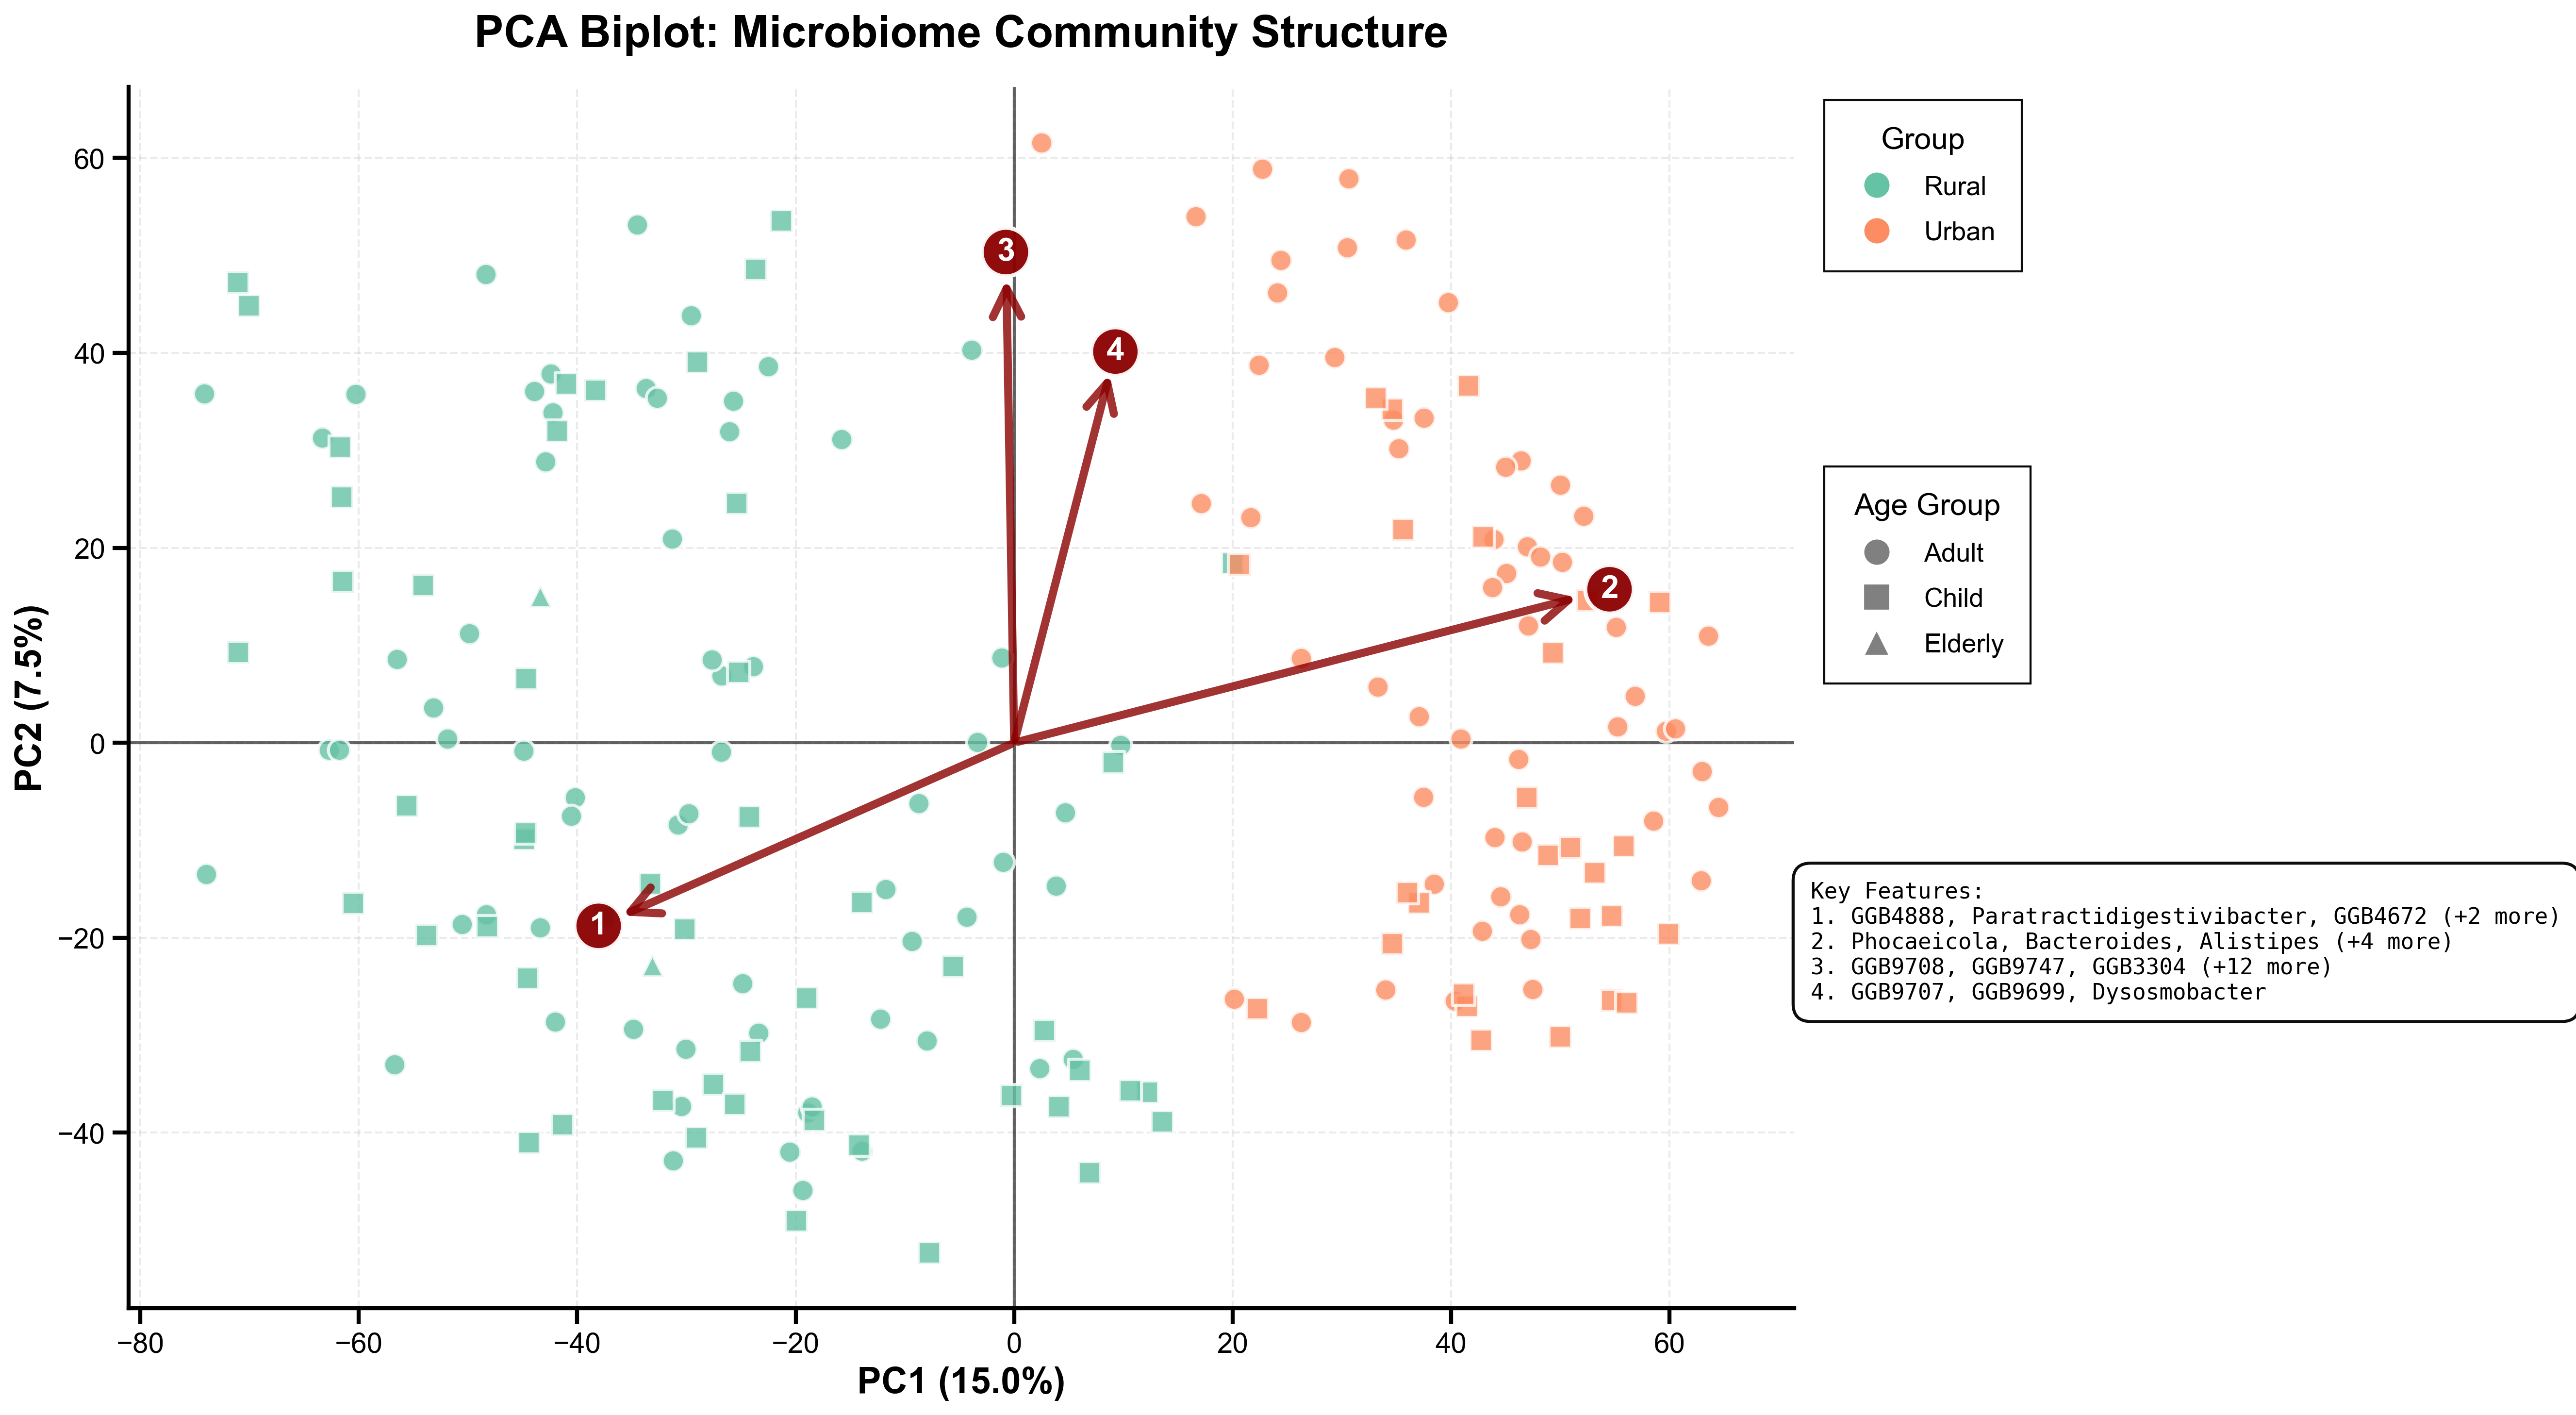

In [97]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# CLR transformation function
def clr_transform(X):
    """
    Apply Centered Log-Ratio (CLR) transformation to compositional data.
    
    Parameters:
    X : array-like, shape (n_samples, n_features)
        Compositional data (must be positive)
    
    Returns:
    X_clr : array, CLR-transformed data
    """
    # Add small constant to avoid log(0) if there are zeros
    X_safe = X + 1e-6
    
    # Compute geometric mean for each sample (row)
    geom_mean = np.exp(np.mean(np.log(X_safe), axis=1, keepdims=True))
    
    # CLR: log(x_i / geometric_mean)
    X_clr = np.log(X_safe / geom_mean)
    
    return X_clr

# Prepare data
X = data_sp_top.drop(columns=['label', 'age_group', 'BMI']).values
y = data_sp_top['label'].values
age_group = data_sp_top['age_group'].values
feature_names = data_sp_top.drop(columns=['label', 'age_group', 'BMI']).columns

# Apply CLR transformation
X_clr = clr_transform(X)

# Perform PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_clr)

# Loadings (contributions of original variables)
loadings = pca.components_.T  # shape: n_features x 2

# Compute contribution of each feature to PC1+PC2
contrib = np.linalg.norm(loadings, axis=1)  # Euclidean norm across PCs

# Select top N features by contribution
top_n = 30  # Start with more features, then cluster them
top_idx = np.argsort(contrib)[-top_n:][::-1]
top_loadings = loadings[top_idx]
top_features = feature_names[top_idx]

# Cluster features based on their loading vectors (direction in PC space)
# Use cosine distance to group features pointing in similar directions
distances = pdist(top_loadings, metric='cosine')
linkage_matrix = linkage(distances, method='average')

# Cut tree to get clusters (adjust distance_threshold to control number of groups)
distance_threshold = 0.1  # Lower = more clusters, Higher = fewer clusters
clusters = fcluster(linkage_matrix, distance_threshold, criterion='distance')

# For each cluster, select the feature with highest contribution
selected_features = []
selected_idx = []
for cluster_id in np.unique(clusters):
    cluster_mask = clusters == cluster_id
    cluster_indices = np.where(cluster_mask)[0]
    
    # Find feature with max contribution in this cluster
    cluster_contrib = contrib[top_idx[cluster_indices]]
    best_in_cluster = cluster_indices[np.argmax(cluster_contrib)]
    
    selected_idx.append(top_idx[best_in_cluster])
    
    # Get all features in this cluster for labeling
    cluster_features = [feature_names[top_idx[i]] for i in cluster_indices]
    selected_features.append(cluster_features)

print(f"Selected {len(selected_features)} distinct directions from {top_n} top features")
for i, (idx, feat_group) in enumerate(zip(selected_idx, selected_features)):
    print(f"{i+1}. Direction {i+1}: {', '.join(feat_group)}")

# Set poster-style parameters (LARGER for visibility)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['font.size'] = 16
plt.rcParams['axes.linewidth'] = 2.0
plt.rcParams['xtick.major.width'] = 2.0
plt.rcParams['ytick.major.width'] = 2.0
plt.rcParams['xtick.major.size'] = 8
plt.rcParams['ytick.major.size'] = 8
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14

# Create figure - LARGER for poster with extra space for feature legend
fig, ax = plt.subplots(figsize=(18, 10), dpi=300)  # Wider to accommodate legends

# Get unique labels and colors
labels_unique = sorted(set(y))
colors = plt.cm.Set2.colors if len(labels_unique) <= 8 else plt.cm.tab10.colors

# Get unique age groups and markers
age_groups_unique = sorted(set(age_group))
markers = ['o', 's', '^', 'D', 'v', 'p', '*', 'h']

# Add subtle grid FIRST (lowest layer)
ax.grid(True, alpha=0.25, linestyle='--', linewidth=1, zorder=0)
ax.set_axisbelow(True)

# Add reference lines at origin
ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5, alpha=0.6, zorder=1)
ax.axvline(x=0, color='black', linestyle='-', linewidth=1.5, alpha=0.6, zorder=1)

# Scatter plot of samples with both label (color) and age group (marker)
for i, group in enumerate(labels_unique):
    for j, age in enumerate(age_groups_unique):
        idx = (y == group) & (age_group == age)
        if np.any(idx):
            ax.scatter(X_pca[idx, 0], X_pca[idx, 1], 
                      alpha=0.8,
                      s=120,
                      color=colors[i % len(colors)],
                      marker=markers[j % len(markers)],
                      edgecolors='white',
                      linewidths=1.5,
                      zorder=3)

# Draw arrows with numbered labels
scaling = np.max(np.abs(X_pca)) / np.max(np.abs(loadings[selected_idx])) * 0.7
arrow_labels = []

for arrow_num, (feat_idx, feat_group) in enumerate(zip(selected_idx, selected_features), 1):
    # Draw arrow
    ax.annotate('',
               xy=(loadings[feat_idx, 0] * scaling, loadings[feat_idx, 1] * scaling),
               xytext=(0, 0),
               arrowprops=dict(arrowstyle='->',
                             lw=4,
                             color='darkred',
                             mutation_scale=35,
                             alpha=0.8),
               zorder=4)
    
    # Add NUMBERED label at arrow tip
    text_offset = 1.05  # Close to arrow tip
    ax.text(loadings[feat_idx, 0] * scaling * text_offset,
           loadings[feat_idx, 1] * scaling * text_offset,
           str(arrow_num),
           fontsize=16,
           color='white',
           ha='center',
           va='center',
           fontweight='bold',
           bbox=dict(boxstyle='circle,pad=0.3',
                   facecolor='darkred',
                   edgecolor='white',
                   alpha=0.95,
                   linewidth=2),
           zorder=6)
    
    # Prepare feature list for legend
    if len(feat_group) <= 2:
        feature_text = ', '.join(feat_group)
    else:
        feature_text = ', '.join(feat_group[:3]) + f' (+{len(feat_group)-3} more)'
    
    arrow_labels.append(f"{arrow_num}. {feature_text}")

# Format axes
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', 
              fontsize=18, fontweight='bold')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', 
              fontsize=18, fontweight='bold')
ax.set_title('PCA Biplot: Microbiome Community Structure', 
             fontsize=22, fontweight='bold', pad=20)

# Create custom legend elements
# Legend for labels (colors)
label_legend_elements = [Line2D([0], [0], marker='o', color='w', 
                                markerfacecolor=colors[i % len(colors)], 
                                markersize=14,
                                label=lbl,
                                markeredgecolor='white', 
                                markeredgewidth=1.5)
                        for i, lbl in enumerate(labels_unique)]

# Legend for age groups (markers)
age_legend_elements = [Line2D([0], [0], marker=markers[j % len(markers)], 
                              color='w', markerfacecolor='gray', 
                              markersize=14,
                              label=age,
                              markeredgecolor='white', 
                              markeredgewidth=1.5)
                      for j, age in enumerate(age_groups_unique)]

# Add first legend (labels)
first_legend = ax.legend(handles=label_legend_elements, 
                        title='Group',
                        loc='upper left',
                        bbox_to_anchor=(1.01, 1),
                        fontsize=13,
                        title_fontsize=15,
                        frameon=True,
                        edgecolor='black',
                        fancybox=False,
                        framealpha=0.95,
                        borderpad=1,
                        labelspacing=0.8)

# Add second legend (age groups)
ax.add_artist(first_legend)
second_legend = ax.legend(handles=age_legend_elements,
                         title='Age Group',
                         loc='upper left',
                         bbox_to_anchor=(1.01, 0.70),
                         fontsize=13,
                         title_fontsize=15,
                         frameon=True,
                         edgecolor='black',
                         fancybox=False,
                         framealpha=0.95,
                         borderpad=1,
                         labelspacing=0.8)

# Add third legend (FEATURE NAMES) - this is the new one!
ax.add_artist(second_legend)

# Create text-based legend for features
feature_legend_text = "Key Features:\n" + "\n".join(arrow_labels)

# Add as text box
ax.text(1.01, 0.35,
        feature_legend_text,
        transform=ax.transAxes,
        fontsize=11,
        verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.8',
                 facecolor='white',
                 edgecolor='black',
                 alpha=0.95,
                 linewidth=1.5),
        family='monospace')  # Monospace for better alignment

# Remove top and right spines
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Save for poster - HIGH RESOLUTION
# fig.savefig('pca_biplot_poster_numbered.png', dpi=600, bbox_inches='tight')
# fig.savefig('pca_biplot_poster_numbered.pdf', dpi=600, bbox_inches='tight')

Selected 4 distinct directions from 30 top features
1. Direction 1: Paratractidigestivibacter, Ellagibacter, Senegalimassilia, GGB4888, GGB4672
2. Direction 2: Phocaeicola, Bacteroides, Alistipes, Parabacteroides, Odoribacter, Ruthenibacterium, Barnesiella
3. Direction 3: Brotocaccenecus, Oscillibacter, GGB9708, GGB9747, GGB3304, GGB143497, GGB9712, GGB9634, GGB3321, GGB9602, GGB3619, GGB9636, GGB9691, GGB9677, GGB9618
4. Direction 4: Dysosmobacter, GGB9707, GGB9699


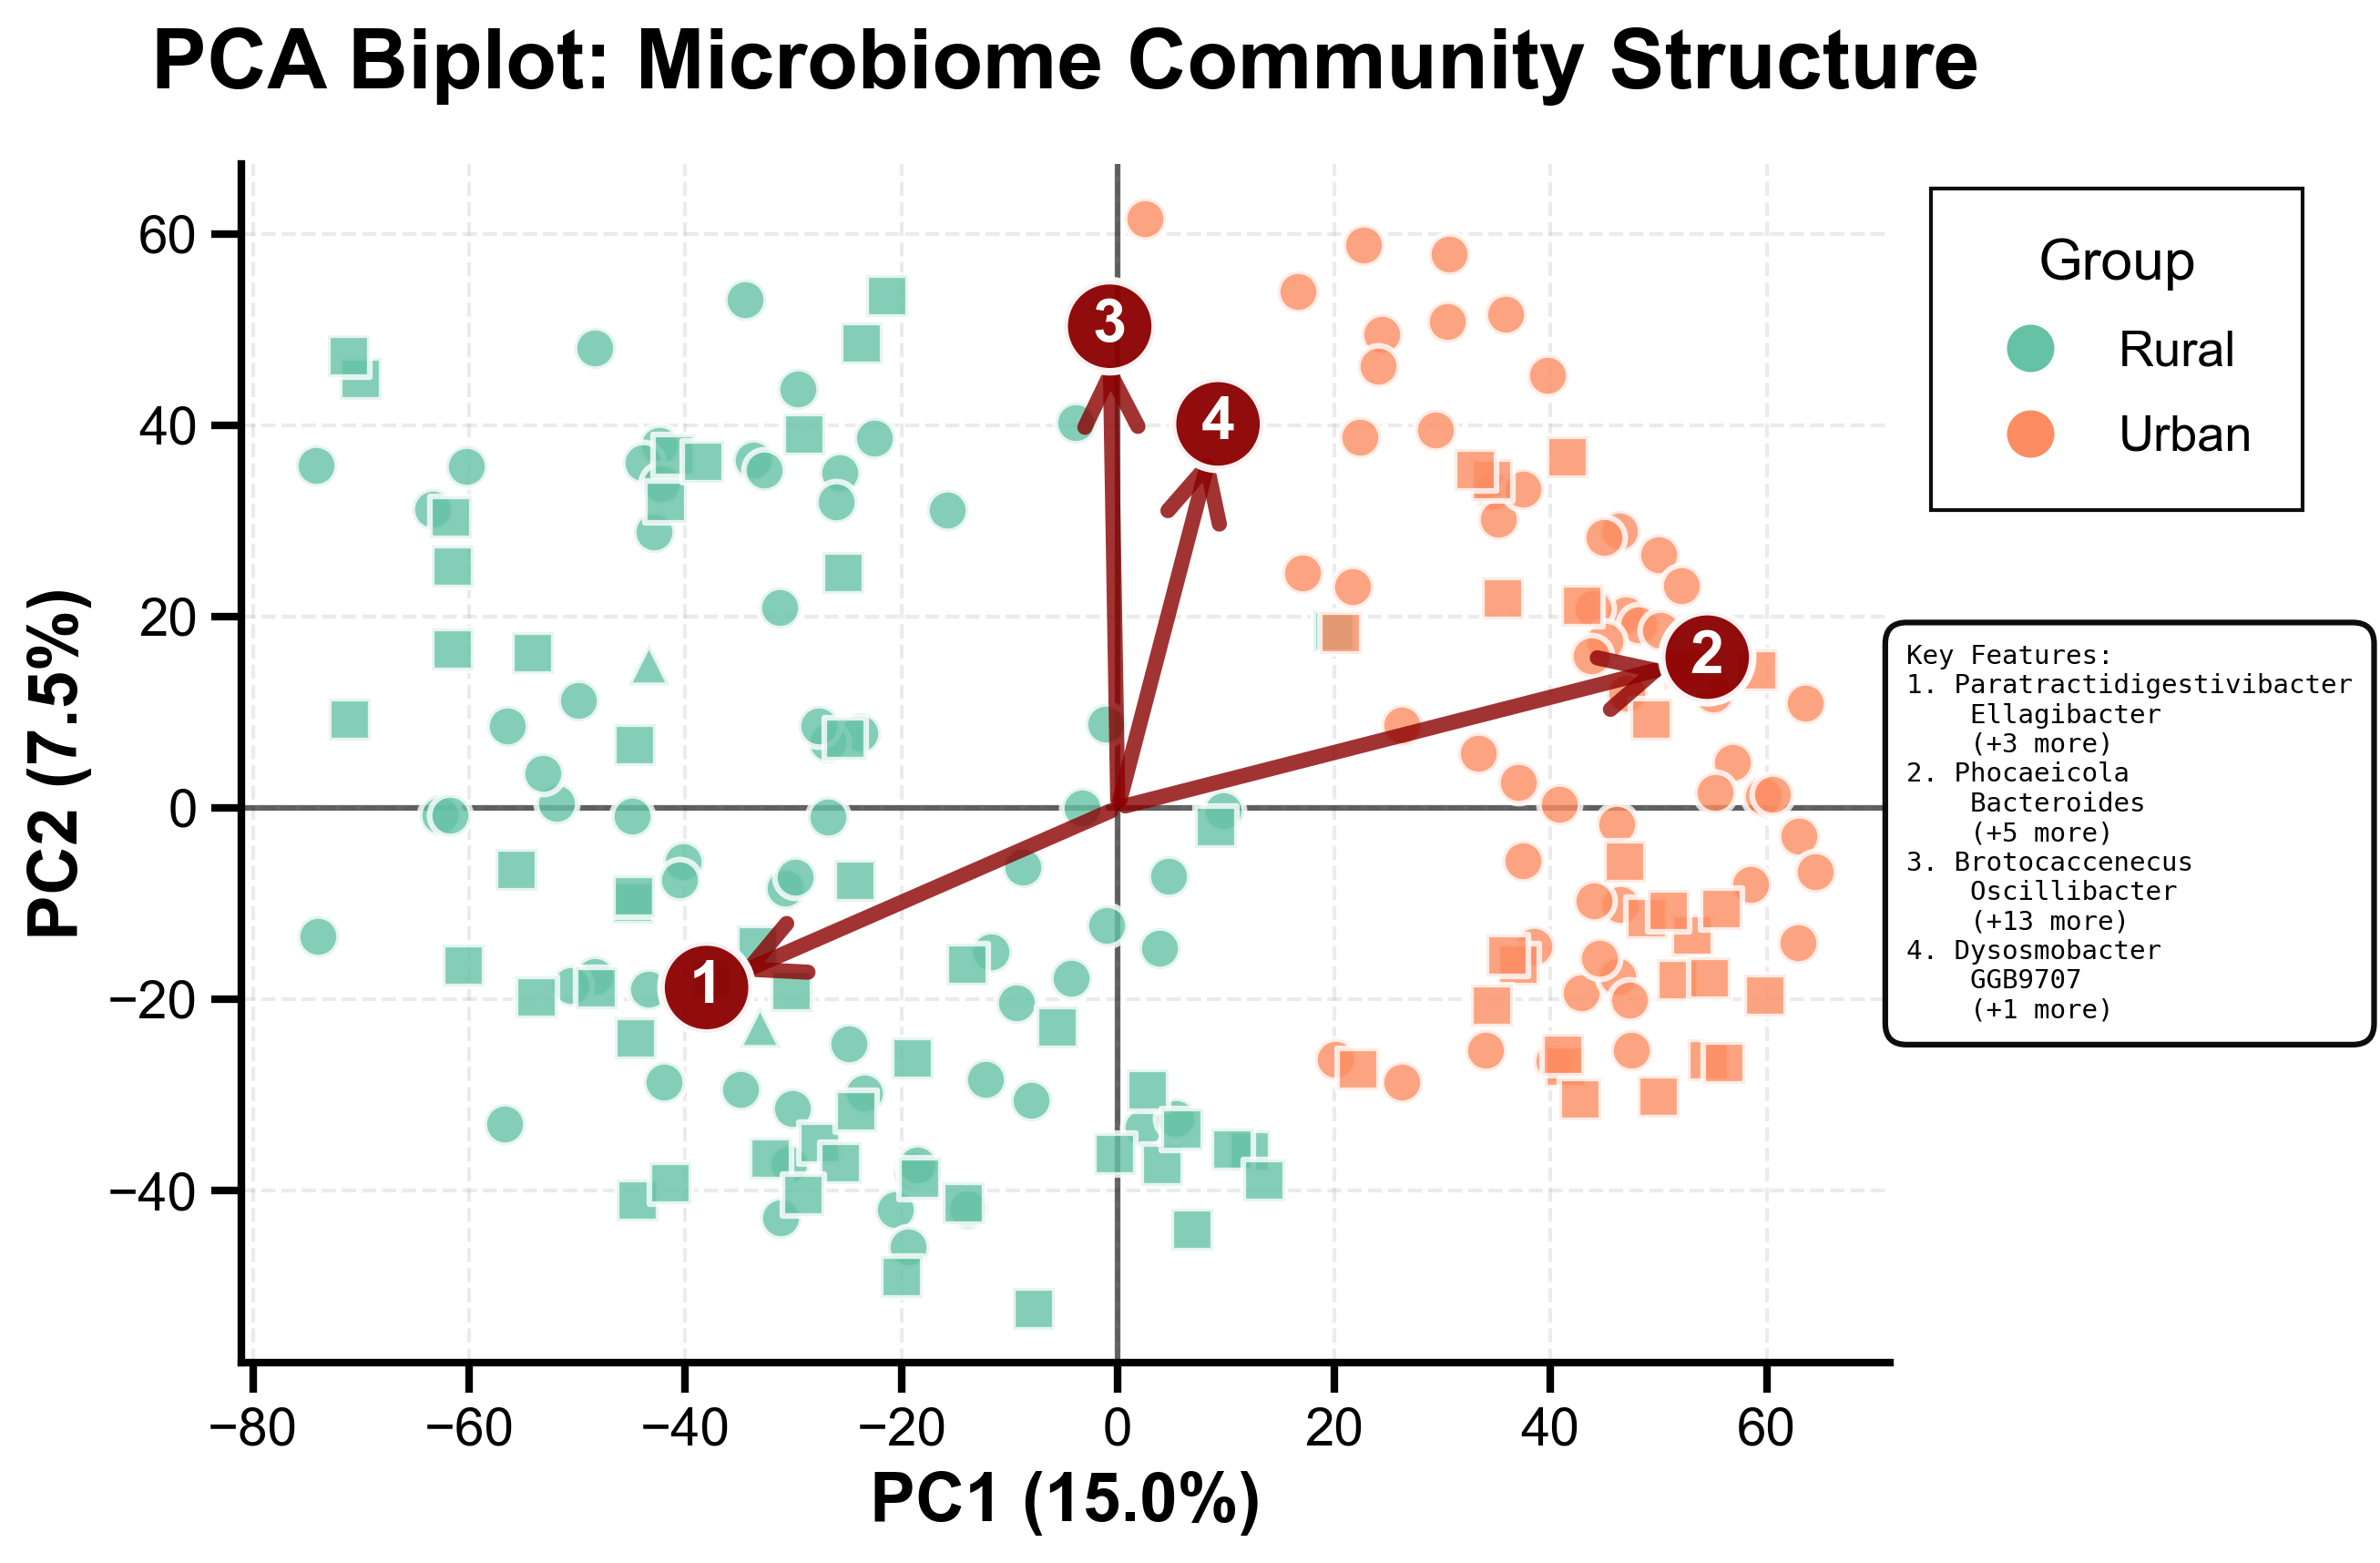

In [37]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# CLR transformation function
def clr_transform(X):
    """
    Apply Centered Log-Ratio (CLR) transformation to compositional data.
    
    Parameters:
    X : array-like, shape (n_samples, n_features)
        Compositional data (must be positive)
    
    Returns:
    X_clr : array, CLR-transformed data
    """
    # Add small constant to avoid log(0) if there are zeros
    X_safe = X + 1e-6
    
    # Compute geometric mean for each sample (row)
    geom_mean = np.exp(np.mean(np.log(X_safe), axis=1, keepdims=True))
    
    # CLR: log(x_i / geometric_mean)
    X_clr = np.log(X_safe / geom_mean)
    
    return X_clr

# Function to sort features: non-GGB first
def sort_features_non_ggb_first(features):
    """Sort features with non-GGB names first"""
    non_ggb = [f for f in features if not f.startswith('GGB')]
    ggb = [f for f in features if f.startswith('GGB')]
    return non_ggb + ggb

# Prepare data
X = data_sp_top.drop(columns=['label', 'age_group', 'BMI']).values
y = data_sp_top['label'].values
age_group = data_sp_top['age_group'].values
feature_names = data_sp_top.drop(columns=['label', 'age_group', 'BMI']).columns

# Apply CLR transformation
X_clr = clr_transform(X)

# Perform PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_clr)

# Loadings (contributions of original variables)
loadings = pca.components_.T  # shape: n_features x 2

# Compute contribution of each feature to PC1+PC2
contrib = np.linalg.norm(loadings, axis=1)  # Euclidean norm across PCs

# Select top N features by contribution
top_n = 30  # Start with more features, then cluster them
top_idx = np.argsort(contrib)[-top_n:][::-1]
top_loadings = loadings[top_idx]
top_features = feature_names[top_idx]

# Cluster features based on their loading vectors (direction in PC space)
# Use cosine distance to group features pointing in similar directions
distances = pdist(top_loadings, metric='cosine')
linkage_matrix = linkage(distances, method='average')

# Cut tree to get clusters (adjust distance_threshold to control number of groups)
distance_threshold = 0.1  # Lower = more clusters, Higher = fewer clusters
clusters = fcluster(linkage_matrix, distance_threshold, criterion='distance')

# For each cluster, select the feature with highest contribution
selected_features = []
selected_idx = []
for cluster_id in np.unique(clusters):
    cluster_mask = clusters == cluster_id
    cluster_indices = np.where(cluster_mask)[0]
    
    # Find feature with max contribution in this cluster
    cluster_contrib = contrib[top_idx[cluster_indices]]
    best_in_cluster = cluster_indices[np.argmax(cluster_contrib)]
    
    selected_idx.append(top_idx[best_in_cluster])
    
    # Get all features in this cluster and sort (non-GGB first)
    cluster_features = [feature_names[top_idx[i]] for i in cluster_indices]
    cluster_features = sort_features_non_ggb_first(cluster_features)
    selected_features.append(cluster_features)

print(f"Selected {len(selected_features)} distinct directions from {top_n} top features")
for i, (idx, feat_group) in enumerate(zip(selected_idx, selected_features)):
    print(f"{i+1}. Direction {i+1}: {', '.join(feat_group)}")

# Set poster-style parameters (LARGER for visibility)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['font.size'] = 16
plt.rcParams['axes.linewidth'] = 2.0
plt.rcParams['xtick.major.width'] = 2.0
plt.rcParams['ytick.major.width'] = 2.0
plt.rcParams['xtick.major.size'] = 8
plt.rcParams['ytick.major.size'] = 8
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14

# Create figure - NARROWER with legends stacked vertically
fig, ax = plt.subplots(figsize=(9, 6), dpi=300)  # Narrower (was 18)

# Get unique labels and colors
labels_unique = sorted(set(y))
colors = plt.cm.Set2.colors if len(labels_unique) <= 8 else plt.cm.tab10.colors

# Get unique age groups and markers
age_groups_unique = sorted(set(age_group))
markers = ['o', 's', '^', 'D', 'v', 'p', '*', 'h']

# Add subtle grid FIRST (lowest layer)
ax.grid(True, alpha=0.25, linestyle='--', linewidth=1, zorder=0)
ax.set_axisbelow(True)

# Add reference lines at origin
ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5, alpha=0.6, zorder=1)
ax.axvline(x=0, color='black', linestyle='-', linewidth=1.5, alpha=0.6, zorder=1)

# Scatter plot of samples with both label (color) and age group (marker)
for i, group in enumerate(labels_unique):
    for j, age in enumerate(age_groups_unique):
        idx = (y == group) & (age_group == age)
        if np.any(idx):
            ax.scatter(X_pca[idx, 0], X_pca[idx, 1], 
                      alpha=0.8,
                      s=120,
                      color=colors[i % len(colors)],
                      marker=markers[j % len(markers)],
                      edgecolors='white',
                      linewidths=1.5,
                      zorder=3)

# Draw arrows with numbered labels
scaling = np.max(np.abs(X_pca)) / np.max(np.abs(loadings[selected_idx])) * 0.7
arrow_labels = []

for arrow_num, (feat_idx, feat_group) in enumerate(zip(selected_idx, selected_features), 1):
    # Draw arrow
    ax.annotate('',
               xy=(loadings[feat_idx, 0] * scaling, loadings[feat_idx, 1] * scaling),
               xytext=(0, 0),
               arrowprops=dict(arrowstyle='->',
                             lw=4,
                             color='darkred',
                             mutation_scale=35,
                             alpha=0.8),
               zorder=4)
    
    # Add NUMBERED label at arrow tip
    text_offset = 1.05  # Close to arrow tip
    ax.text(loadings[feat_idx, 0] * scaling * text_offset,
           loadings[feat_idx, 1] * scaling * text_offset,
           str(arrow_num),
           fontsize=16,
           color='white',
           ha='center',
           va='center',
           fontweight='bold',
           bbox=dict(boxstyle='circle,pad=0.3',
                   facecolor='darkred',
                   edgecolor='white',
                   alpha=0.95,
                   linewidth=2),
           zorder=6)
    
    # Prepare feature list for legend - show only first 2, one per line
    if len(feat_group) == 1:
        feature_text = feat_group[0]
    elif len(feat_group) == 2:
        feature_text = f"{feat_group[0]}\n    {feat_group[1]}"  # One below the other
    else:
        # Show first 2, then "+N more"
        feature_text = f"{feat_group[0]}\n    {feat_group[1]}\n    (+{len(feat_group)-2} more)"
    
    arrow_labels.append(f"{arrow_num}. {feature_text}")

# Format axes
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', 
              fontsize=18, fontweight='bold')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', 
              fontsize=18, fontweight='bold')
ax.set_title('PCA Biplot: Microbiome Community Structure', 
             fontsize=22, fontweight='bold', pad=20)

# Create custom legend elements
# Legend for labels (colors)
label_legend_elements = [Line2D([0], [0], marker='o', color='w', 
                                markerfacecolor=colors[i % len(colors)], 
                                markersize=14,
                                label=lbl,
                                markeredgecolor='white', 
                                markeredgewidth=1.5)
                        for i, lbl in enumerate(labels_unique)]

# Legend for age groups (markers)
age_legend_elements = [Line2D([0], [0], marker=markers[j % len(markers)], 
                              color='w', markerfacecolor='gray', 
                              markersize=14,
                              label=age,
                              markeredgecolor='white', 
                              markeredgewidth=1.5)
                      for j, age in enumerate(age_groups_unique)]

# Stack all legends vertically on the right
# Legend 1: Group (at top)
first_legend = ax.legend(handles=label_legend_elements, 
                        title='Group',
                        loc='upper left',
                        bbox_to_anchor=(1.01, 1.0),
                        fontsize=13,
                        title_fontsize=15,
                        frameon=True,
                        edgecolor='black',
                        fancybox=False,
                        framealpha=0.95,
                        borderpad=1,
                        labelspacing=0.8)

# Legend 2: Age Group (below Group)
# ax.add_artist(first_legend)
# second_legend = ax.legend(handles=age_legend_elements,
#                          title='Age Group',
#                          loc='upper left',
#                          bbox_to_anchor=(1.01, 0.82),
#                          fontsize=13,
#                          title_fontsize=15,
#                          frameon=True,
#                          edgecolor='black',
#                          fancybox=False,
#                          framealpha=0.95,
#                          borderpad=1,
#                          labelspacing=0.8)

# Legend 3: Feature Names (below Age Group)
# ax.add_artist(second_legend)

# Create text-based legend for features
feature_legend_text = "Key Features:\n" + "\n".join(arrow_labels)

# Add as text box - positioned below other legends
ax.text(1.01, 0.60,
        feature_legend_text,
        transform=ax.transAxes,
        fontsize=7,
        verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.8',
                 facecolor='white',
                 edgecolor='black',
                 alpha=0.95,
                 linewidth=1.5),
        family='monospace')  # Monospace for better alignment

# Remove top and right spines
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Save for poster - HIGH RESOLUTION
fig.savefig('pca_biplot_poster_numbered.png', dpi=600, bbox_inches='tight')
fig.savefig('pca_biplot_poster_numbered.pdf', dpi=600, bbox_inches='tight')

Selected 4 distinct directions from 30 top features
1. Direction 1: Paratractidigestivibacter, Ellagibacter, Senegalimassilia, GGB4888, GGB4672
2. Direction 2: Phocaeicola, Bacteroides, Alistipes, Parabacteroides, Odoribacter, Ruthenibacterium, Barnesiella
3. Direction 3: Brotocaccenecus, Oscillibacter, GGB9708, GGB9747, GGB3304, GGB143497, GGB9712, GGB9634, GGB3321, GGB9602, GGB3619, GGB9636, GGB9691, GGB9677, GGB9618
4. Direction 4: Dysosmobacter, GGB9707, GGB9699

Features:
1. Paratractidigestivibacter, Ellagibacter (+3)
2. Phocaeicola, Bacteroides (+5)
3. Brotocaccenecus, Oscillibacter (+13)
4. Dysosmobacter, GGB9707 (+1)


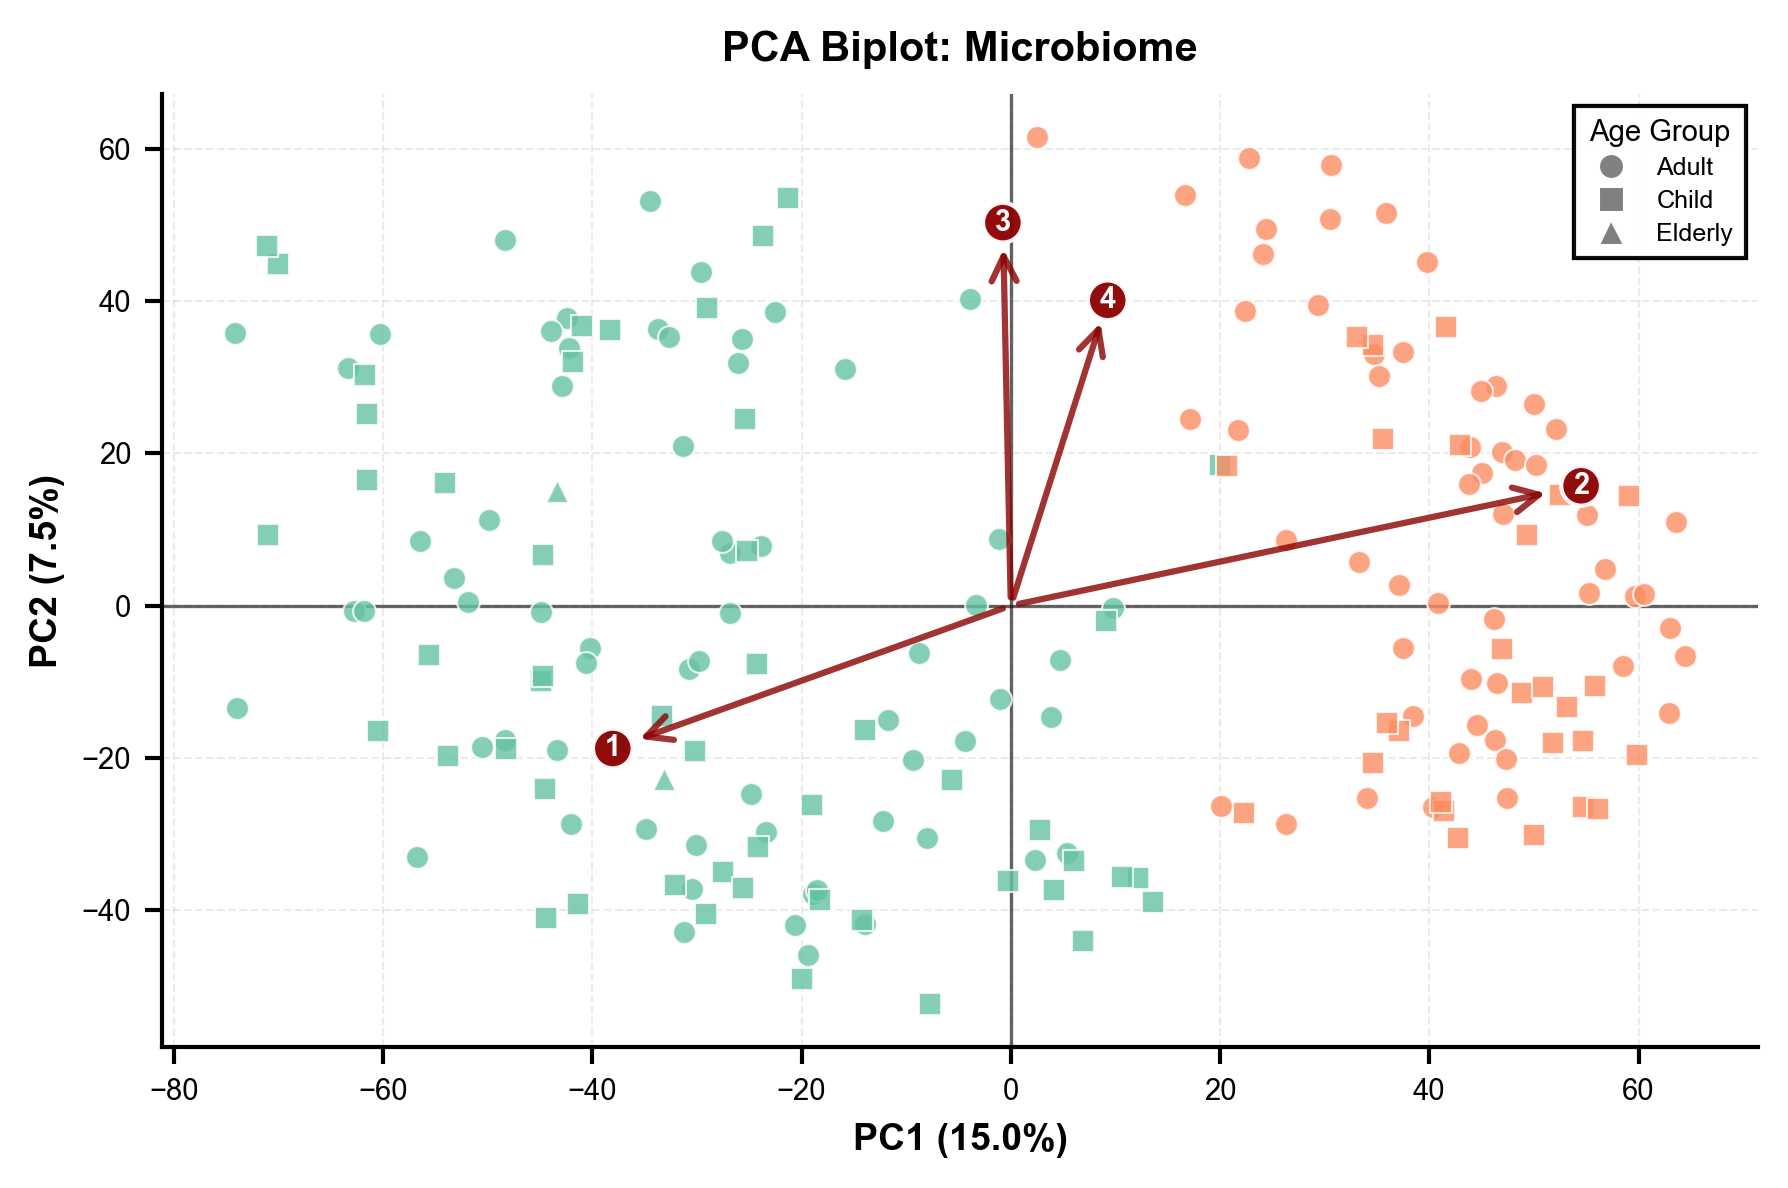

In [103]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# CLR transformation function
def clr_transform(X):
    """
    Apply Centered Log-Ratio (CLR) transformation to compositional data.
    
    Parameters:
    X : array-like, shape (n_samples, n_features)
        Compositional data (must be positive)
    
    Returns:
    X_clr : array, CLR-transformed data
    """
    # Add small constant to avoid log(0) if there are zeros
    X_safe = X + 1e-6
    
    # Compute geometric mean for each sample (row)
    geom_mean = np.exp(np.mean(np.log(X_safe), axis=1, keepdims=True))
    
    # CLR: log(x_i / geometric_mean)
    X_clr = np.log(X_safe / geom_mean)
    
    return X_clr

# Function to sort features: non-GGB first
def sort_features_non_ggb_first(features):
    """Sort features with non-GGB names first"""
    non_ggb = [f for f in features if not f.startswith('GGB')]
    ggb = [f for f in features if f.startswith('GGB')]
    return non_ggb + ggb

# Prepare data
X = data_sp_top.drop(columns=['label', 'age_group', 'BMI']).values
y = data_sp_top['label'].values
age_group = data_sp_top['age_group'].values
feature_names = data_sp_top.drop(columns=['label', 'age_group', 'BMI']).columns

# Apply CLR transformation
X_clr = clr_transform(X)

# Perform PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_clr)

# Loadings (contributions of original variables)
loadings = pca.components_.T  # shape: n_features x 2

# Compute contribution of each feature to PC1+PC2
contrib = np.linalg.norm(loadings, axis=1)  # Euclidean norm across PCs

# Select top N features by contribution
top_n = 30  # Start with more features, then cluster them
top_idx = np.argsort(contrib)[-top_n:][::-1]
top_loadings = loadings[top_idx]
top_features = feature_names[top_idx]

# Cluster features based on their loading vectors (direction in PC space)
# Use cosine distance to group features pointing in similar directions
distances = pdist(top_loadings, metric='cosine')
linkage_matrix = linkage(distances, method='average')

# Cut tree to get clusters (adjust distance_threshold to control number of groups)
distance_threshold = 0.1  # Lower = more clusters, Higher = fewer clusters
clusters = fcluster(linkage_matrix, distance_threshold, criterion='distance')

# For each cluster, select the feature with highest contribution
selected_features = []
selected_idx = []
for cluster_id in np.unique(clusters):
    cluster_mask = clusters == cluster_id
    cluster_indices = np.where(cluster_mask)[0]
    
    # Find feature with max contribution in this cluster
    cluster_contrib = contrib[top_idx[cluster_indices]]
    best_in_cluster = cluster_indices[np.argmax(cluster_contrib)]
    
    selected_idx.append(top_idx[best_in_cluster])
    
    # Get all features in this cluster and sort (non-GGB first)
    cluster_features = [feature_names[top_idx[i]] for i in cluster_indices]
    cluster_features = sort_features_non_ggb_first(cluster_features)
    selected_features.append(cluster_features)

print(f"Selected {len(selected_features)} distinct directions from {top_n} top features")
for i, (idx, feat_group) in enumerate(zip(selected_idx, selected_features)):
    print(f"{i+1}. Direction {i+1}: {', '.join(feat_group)}")

# Set poster-style parameters (adjusted for smaller size)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['font.size'] = 8
plt.rcParams['axes.linewidth'] = 1.0
plt.rcParams['xtick.major.width'] = 1.0
plt.rcParams['ytick.major.width'] = 1.0
plt.rcParams['xtick.major.size'] = 4
plt.rcParams['ytick.major.size'] = 4
plt.rcParams['xtick.labelsize'] = 7
plt.rcParams['ytick.labelsize'] = 7

# Create figure - SMALL SIZE
fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

# Get unique labels and colors
labels_unique = sorted(set(y))
colors = plt.cm.Set2.colors if len(labels_unique) <= 8 else plt.cm.tab10.colors

# Get unique age groups and markers
age_groups_unique = sorted(set(age_group))
markers = ['o', 's', '^', 'D', 'v', 'p', '*', 'h']

# Add subtle grid FIRST (lowest layer)
ax.grid(True, alpha=0.25, linestyle='--', linewidth=0.5, zorder=0)
ax.set_axisbelow(True)

# Add reference lines at origin
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.6, zorder=1)
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8, alpha=0.6, zorder=1)

# Scatter plot of samples with both label (color) and age group (marker)
for i, group in enumerate(labels_unique):
    for j, age in enumerate(age_groups_unique):
        idx = (y == group) & (age_group == age)
        if np.any(idx):
            ax.scatter(X_pca[idx, 0], X_pca[idx, 1], 
                      alpha=0.8,
                      s=30,  # Smaller points for small figure
                      color=colors[i % len(colors)],
                      marker=markers[j % len(markers)],
                      edgecolors='white',
                      linewidths=0.5,
                      zorder=3)

# Draw arrows with numbered labels
scaling = np.max(np.abs(X_pca)) / np.max(np.abs(loadings[selected_idx])) * 0.7
arrow_labels = []

for arrow_num, (feat_idx, feat_group) in enumerate(zip(selected_idx, selected_features), 1):
    # Draw arrow - smaller for compact figure
    ax.annotate('',
               xy=(loadings[feat_idx, 0] * scaling, loadings[feat_idx, 1] * scaling),
               xytext=(0, 0),
               arrowprops=dict(arrowstyle='->',
                             lw=1.5,  # Thinner
                             color='darkred',
                             mutation_scale=15,  # Smaller arrowhead
                             alpha=0.8),
               zorder=4)
    
    # Add NUMBERED label at arrow tip - smaller
    text_offset = 1.05
    ax.text(loadings[feat_idx, 0] * scaling * text_offset,
           loadings[feat_idx, 1] * scaling * text_offset,
           str(arrow_num),
           fontsize=7,  # Smaller font
           color='white',
           ha='center',
           va='center',
           fontweight='bold',
           bbox=dict(boxstyle='circle,pad=0.2',
                   facecolor='darkred',
                   edgecolor='white',
                   alpha=0.95,
                   linewidth=1),
           zorder=6)
    
    # Prepare feature list for legend - show only first 2, one per line
    if len(feat_group) == 1:
        feature_text = feat_group[0]
    elif len(feat_group) == 2:
        feature_text = f"{feat_group[0]}, {feat_group[1]}"  # Same line for compactness
    else:
        # Show first 2, then "+N more"
        feature_text = f"{feat_group[0]}, {feat_group[1]} (+{len(feat_group)-2})"
    
    arrow_labels.append(f"{arrow_num}. {feature_text}")

# Format axes
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', 
              fontsize=9, fontweight='bold')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', 
              fontsize=9, fontweight='bold')
ax.set_title('PCA Biplot: Microbiome', 
             fontsize=10, fontweight='bold', pad=8)

# Create custom legend elements
# NO Group legend - ONLY Age Group

# Legend for age groups (markers) - ONLY THIS ONE
age_legend_elements = [Line2D([0], [0], marker=markers[j % len(markers)], 
                              color='w', markerfacecolor='gray', 
                              markersize=6,  # Smaller
                              label=age,
                              markeredgecolor='white', 
                              markeredgewidth=0.5)
                      for j, age in enumerate(age_groups_unique)]

# Single legend: Age Group only
first_legend = ax.legend(handles=age_legend_elements,
                        title='Age Group',
                        loc='upper right',  # Inside plot to save space
                        fontsize=6,
                        title_fontsize=7,
                        frameon=True,
                        edgecolor='black',
                        fancybox=False,
                        framealpha=0.95,
                        borderpad=0.5,
                        labelspacing=0.4)

# Legend for Feature Names (in caption or separate)
ax.add_artist(first_legend)

# Create compact text-based legend for features - OUTSIDE plot
feature_legend_text = "Features:\n" + "\n".join(arrow_labels)

# Print feature legend separately (not on plot to save space)
print("\n" + feature_legend_text)

# Alternatively, add very compact text box
# Uncomment if you want it on the figure:
# ax.text(1.02, 0.98,
#         feature_legend_text,
#         transform=ax.transAxes,
#         fontsize=5,
#         verticalalignment='top',
#         bbox=dict(boxstyle='round,pad=0.3',
#                  facecolor='white',
#                  edgecolor='black',
#                  alpha=0.95,
#                  linewidth=0.5),
#         family='monospace')

# Remove top and right spines
ax.spines['left'].set_linewidth(1)
ax.spines['bottom'].set_linewidth(1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Save - HIGH RESOLUTION
fig.savefig('pca_biplot_compact_numbered.png', dpi=600, bbox_inches='tight')
fig.savefig('pca_biplot_compact_numbered.pdf', dpi=600, bbox_inches='tight')

# Save feature legend separately as text file
with open('pca_biplot_feature_legend.txt', 'w') as f:
    f.write(feature_legend_text)

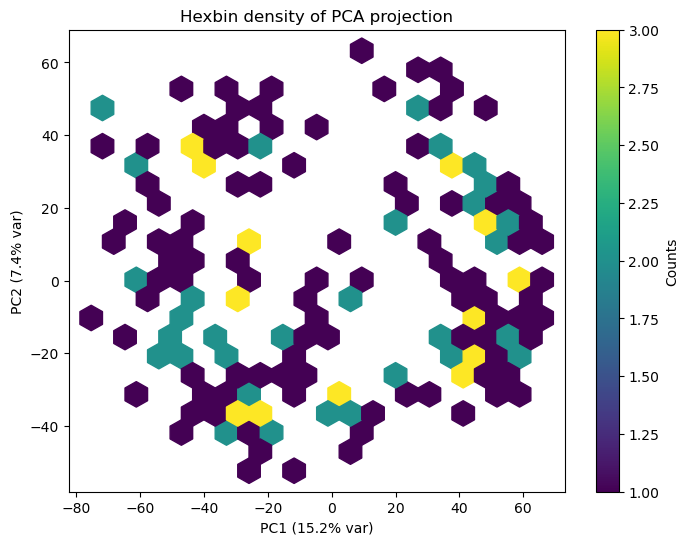

In [50]:
import matplotlib.pyplot as plt

# X_pca from previous PCA
x = X_pca[:,0]
y = X_pca[:,1]

plt.figure(figsize=(8,6))
hb = plt.hexbin(x, y, gridsize=20, cmap='viridis', mincnt=1)
plt.colorbar(hb, label='Counts')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
plt.title('Hexbin density of PCA projection')
plt.show()


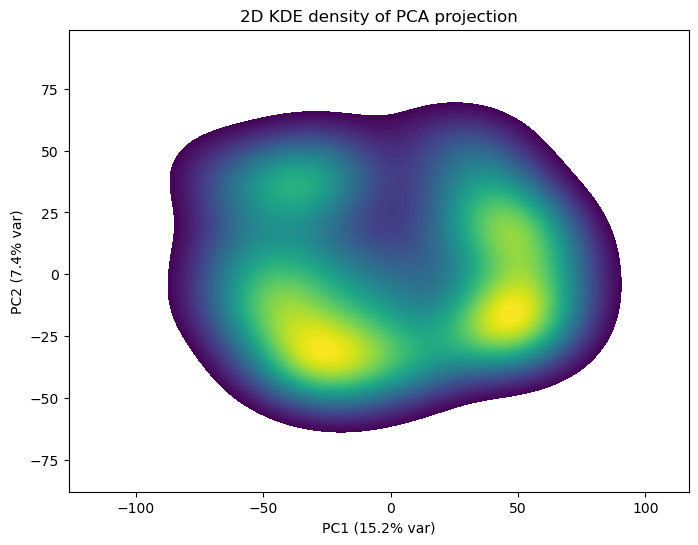

In [51]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.kdeplot(x=x, y=y, fill=True, cmap='viridis', thresh=0.05, levels=100)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
plt.title('2D KDE density of PCA projection')
plt.show()

In [52]:
df_plot = pd.DataFrame({
    'PC1': X_pca[:,0],
    'PC2': X_pca[:,1],
    'label': label
})
df_plot

,PC1,PC2,label
0,42.298484,-27.906632,Urban
1,-26.783862,-6.184298,Rural
2,-11.918555,-18.374557,Rural
3,2.310457,-37.238237,Rural
4,9.876047,-37.899494,Rural
...,...,...,...
194,-25.277429,35.036851,Rural
195,-8.212068,-23.728494,Rural
196,-71.957247,38.636340,Rural
197,-70.890564,48.784926,Rural


C:\Users\rafap\anaconda3\envs\clustering-env\Lib\site-packages\seaborn\distributions.py:1128: UserWarning: cmap parameter ignored when using hue mapping.
  warnings.warn(msg, UserWarning)


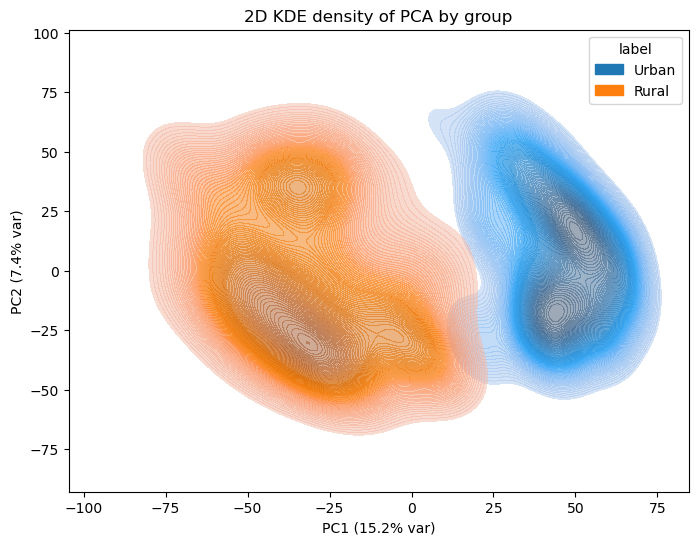

In [53]:
import seaborn as sns
import pandas as pd

df_plot = pd.DataFrame({
    'PC1': X_pca[:,0],
    'PC2': X_pca[:,1],
    'label': label
})

plt.figure(figsize=(8,6))
sns.kdeplot(data=df_plot, x='PC1', y='PC2', hue='label', fill=True, alpha=0.5, cmap='coolwarm', levels=100)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
plt.title('2D KDE density of PCA by group')
plt.show()


C:\Users\rafap\anaconda3\envs\clustering-env\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


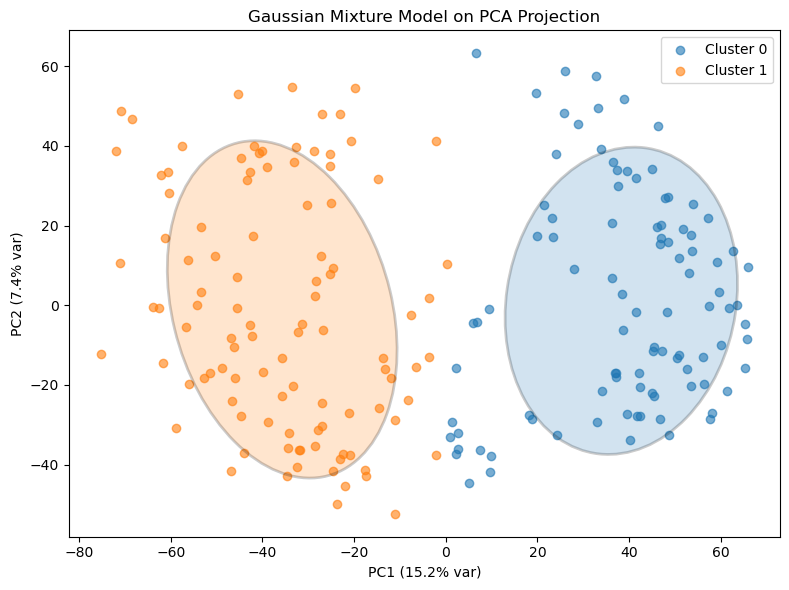

In [54]:
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
import numpy as np

# Ajustar el modelo GMM
gmm = GaussianMixture(n_components=2, random_state=42)
gmm.fit(X_clr)

# Proyección PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_clr)

# Predicciones del GMM
labels_pred = gmm.predict(X_clr)

# Transformar medias y covarianzas del GMM al espacio PCA
means_pca = pca.transform(gmm.means_)
covariances_pca = []
for cov in gmm.covariances_:
    # Transformar covarianza: C' = P * C * P^T (donde P son los componentes PCA)
    cov_pca = pca.components_ @ cov @ pca.components_.T
    covariances_pca.append(cov_pca)

# Gráfico
plt.figure(figsize=(8, 6))
colors = plt.cm.tab10.colors

for i, label in enumerate(np.unique(labels_pred)):
    idx = labels_pred == label
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1],
                color=colors[i % len(colors)], label=f'Cluster {label}', alpha=0.6)
    
    # Dibujar elipsoides de covarianza en el espacio PCA
    cov_2d = covariances_pca[label]
    mean_2d = means_pca[label]
    
    # Calcular autovalores y autovectores
    v, w = np.linalg.eigh(cov_2d)
    v = 2.0 * np.sqrt(2.0) * np.sqrt(v)  # Escalar para ~95% de confianza
    angle = np.degrees(np.arctan2(w[1, 0], w[0, 0]))
    
    ellipse = Ellipse(mean_2d, v[0], v[1], angle=angle,
                      alpha=0.2, facecolor=colors[i % len(colors)], 
                      edgecolor='black', linewidth=2)
    plt.gca().add_artist(ellipse)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
plt.title('Gaussian Mixture Model on PCA Projection')
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\rafap\anaconda3\envs\clustering-env\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\rafap\anaconda3\envs\clustering-env\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\rafap\anaconda3\envs\clustering-env\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\rafap\anaconda3\envs\clustering-env\Lib\site-packages\sklearn\clust

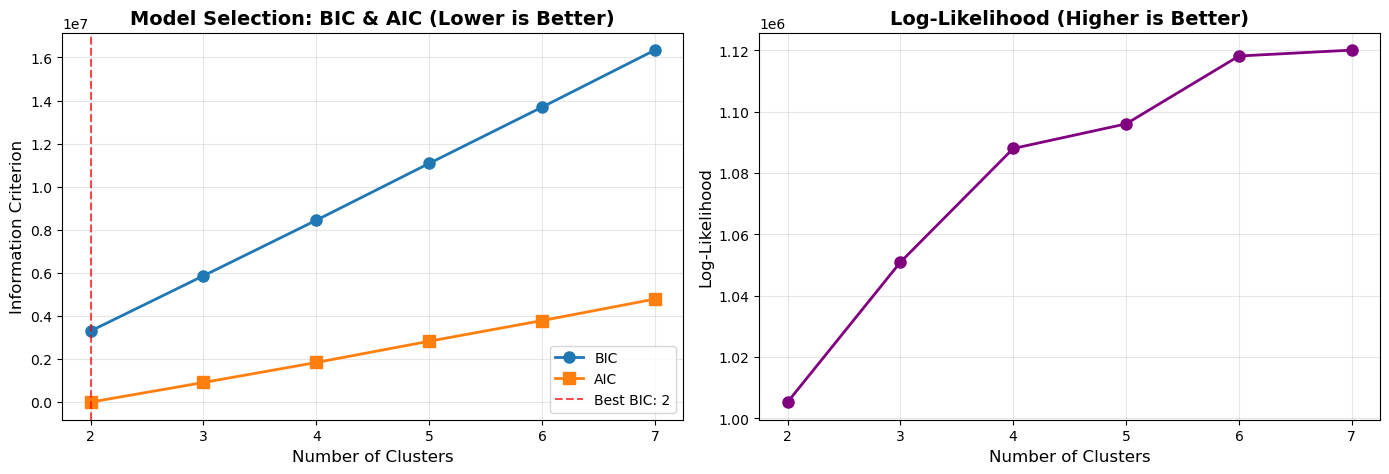

GMM EVALUATION RESULTS
Clusters   BIC             AIC             Log-Likelihood 
------------------------------------------------------------
2          3298592.67      -4595.36        1005298.68     
3          5861917.81      907134.11       1050934.94     
4          8442362.91      1835983.55      1088011.22     
5          11080905.65     2822930.62      1096038.69     
6          13691238.61     3781667.93      1118171.03     
7          16341983.29     4780816.94      1120097.53     

RECOMMENDATIONS:
Best by BIC (recommended): 2 clusters
Best by AIC:               2 clusters
Best by Log-Likelihood:    7 clusters

Note: BIC is typically preferred as it penalizes model complexity
more heavily, helping avoid overfitting.


In [55]:
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
import numpy as np

# Rango de clusters a evaluar
n_clusters_range = range(2, 8)  # 2, 3, 4

# Listas para almacenar métricas
bic_scores = []
aic_scores = []
log_likelihood_scores = []

# Evaluar cada número de clusters
for n in n_clusters_range:
    # Ajustar GMM
    gmm = GaussianMixture(n_components=n, random_state=42)
    gmm.fit(X_clr)
    
    # Calcular métricas apropiadas para GMM
    bic_scores.append(gmm.bic(X_clr))
    aic_scores.append(gmm.aic(X_clr))
    log_likelihood_scores.append(gmm.score(X_clr) * len(X_clr))  # Total log-likelihood

# Crear figura con 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: BIC y AIC (lower is better)
axes[0].plot(list(n_clusters_range), bic_scores, 'o-', label='BIC', linewidth=2, markersize=8)
axes[0].plot(list(n_clusters_range), aic_scores, 's-', label='AIC', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters', fontsize=12)
axes[0].set_ylabel('Information Criterion', fontsize=12)
axes[0].set_title('Model Selection: BIC & AIC (Lower is Better)', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(list(n_clusters_range))

# Marcar el mínimo BIC
best_bic_idx = np.argmin(bic_scores)
best_bic_n = list(n_clusters_range)[best_bic_idx]
axes[0].axvline(best_bic_n, color='red', linestyle='--', alpha=0.7, 
                label=f'Best BIC: {best_bic_n}')
axes[0].legend()

# Plot 2: Log-Likelihood (higher is better)
axes[1].plot(list(n_clusters_range), log_likelihood_scores, 'o-', 
             color='purple', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters', fontsize=12)
axes[1].set_ylabel('Log-Likelihood', fontsize=12)
axes[1].set_title('Log-Likelihood (Higher is Better)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(list(n_clusters_range))

plt.tight_layout()
plt.show()

# Imprimir resultados
print("=" * 60)
print("GMM EVALUATION RESULTS")
print("=" * 60)
print(f"{'Clusters':<10} {'BIC':<15} {'AIC':<15} {'Log-Likelihood':<15}")
print("-" * 60)
for i, n in enumerate(n_clusters_range):
    print(f"{n:<10} {bic_scores[i]:<15.2f} {aic_scores[i]:<15.2f} {log_likelihood_scores[i]:<15.2f}")

print("\n" + "=" * 60)
print("RECOMMENDATIONS:")
print("=" * 60)
print(f"Best by BIC (recommended): {best_bic_n} clusters")
print(f"Best by AIC:               {list(n_clusters_range)[np.argmin(aic_scores)]} clusters")
print(f"Best by Log-Likelihood:    {list(n_clusters_range)[np.argmax(log_likelihood_scores)]} clusters")
print("\nNote: BIC is typically preferred as it penalizes model complexity")
print("more heavily, helping avoid overfitting.")
print("=" * 60)

In [56]:
data_sp_top['predict'] = labels_pred

C:\Users\rafap\AppData\Local\Temp\ipykernel_28640\2718241519.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_sp_top['predict'] = labels_pred


In [57]:
data_sp_top[(data_sp_top['label']=='Rural')&(data_sp_top['predict'] == 0)]

,GGB4916,Segatella,Streptococcus,Faecalibacterium,Ruminococcus,Agathobacter,Bacteroides,Roseburia,Catenibacterium,Blautia,...,GGB3141,GGB42688,GGB2987,GGB47387,GGB1145,GGB9301,GGB9357,GGB51124,label,predict
36703_3#14,0.00000,33.00639,5.61198,0.50796,2.75049,0.50370,0.01129,0.16471,2.02621,1.64632,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Rural,0
36703_3#15,0.00000,0.40062,2.42148,0.48589,4.45759,44.21785,0.00000,0.09425,0.00000,3.14182,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Rural,0
36703_3#17,0.01273,4.66546,17.65514,7.94657,1.65044,0.02196,0.00000,0.05898,0.00000,6.05950,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Rural,0
36703_3#19,0.00000,1.68585,8.40756,1.61802,1.85241,0.94572,0.00577,1.14601,0.00000,3.27096,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Rural,0
37035_1#21,0.00000,0.01293,22.36921,0.00000,0.53600,0.06511,0.00000,0.06733,0.00000,18.45156,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Rural,0
37035_1#3,0.00000,1.63239,0.03357,3.34510,3.76297,7.10588,8.35412,0.19488,0.00000,0.59414,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Rural,0
37035_7#15,0.03911,3.57649,24.06286,4.24353,1.09633,0.00431,0.00000,0.03249,0.00000,6.58983,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Rural,0
37035_7#24,0.00000,1.05979,16.34487,0.53092,0.96773,3.01297,0.00000,0.00865,0.40012,7.24473,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Rural,0
37035_7#25,0.00000,1.65209,2.55706,39.54451,3.53151,0.61379,0.51248,0.11069,6.21478,1.65635,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Rural,0
37035_7#3,0.00000,39.88995,1.13628,14.67122,0.17676,3.61369,0.01068,1.65660,0.00178,0.53972,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Rural,0


In [58]:
group1 = list(data_sp_top[data_sp_top['predict'] == 0].index)
group2 = list(data_sp_top[data_sp_top['predict'] == 1].index)
# group3 = list(data_sp_top[data_sp_top['predict'] == 2].index)
# group4 = list(data_sp_top[data_sp_top['predict'] == 3].index)

In [59]:
meta1 = metadata[metadata['Lane'].isin(group1)]
meta2 = metadata[metadata['Lane'].isin(group2)]
# meta3 = metadata[metadata['Lane'].isin(group3)]
# meta4 = metadata[metadata['Lane'].isin(group4)]


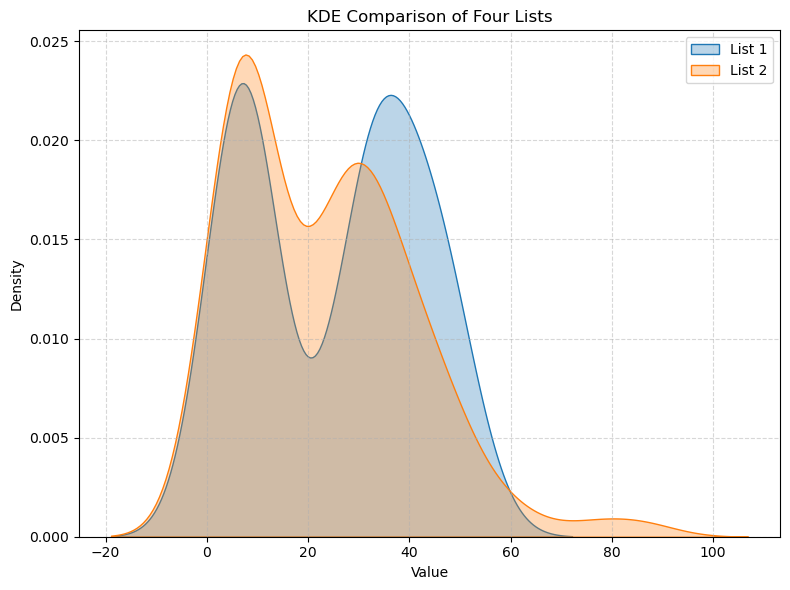

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

# Example lists
list1 = list(meta1['Age'])
list2 = list(meta2['Age'])
# list3 = list(meta3['Age'])
# list4 = list(meta4['Age'])

# Plot
plt.figure(figsize=(8,6))
sns.kdeplot(list1, label="List 1", fill=True, alpha=0.3)
sns.kdeplot(list2, label="List 2", fill=True, alpha=0.3)
# sns.kdeplot(list3, label="List 3", fill=True, alpha=0.3)
# sns.kdeplot(list4, label="List 4", fill=True, alpha=0.3)

plt.title("KDE Comparison of Four Lists")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

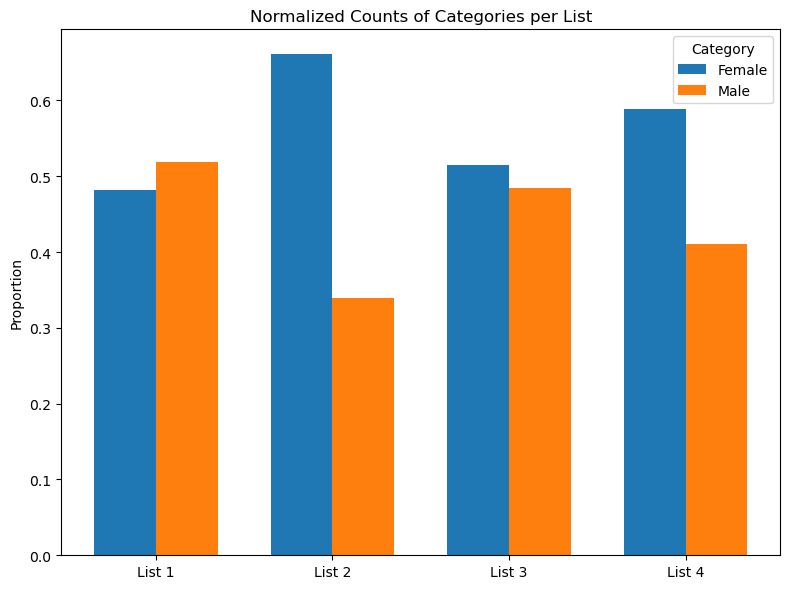

In [111]:
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter
import numpy as np

# Example categorical lists (2 categories: 'A' and 'B')
list1 = list(meta1['Gender'])
list2 = list(meta2['Gender'])
list3 = list(meta3['Gender'])
list4 = list(meta4['Gender'])

lists = [list1, list2, list3, list4]
list_names = ['List 1','List 2','List 3','List 4']

# Count occurrences ignoring NaNs
counts = pd.DataFrame([
    Counter([x for x in lst if pd.notna(x)]) for lst in lists
], index=list_names).fillna(0)

# Normalize so that each row sums to 1
counts_normalized = counts.div(counts.sum(axis=1), axis=0)

# --- Plot grouped bar chart ---
categories = counts_normalized.columns
x = np.arange(len(list_names))
width = 0.35

fig, ax = plt.subplots(figsize=(8,6))
for i, cat in enumerate(categories):
    ax.bar(x + i*width, counts_normalized[cat], width, label=cat)

ax.set_xticks(x + width/2)
ax.set_xticklabels(list_names)
ax.set_ylabel('Proportion')
ax.set_title('Normalized Counts of Categories per List')
ax.legend(title='Category')
plt.tight_layout()
plt.show()


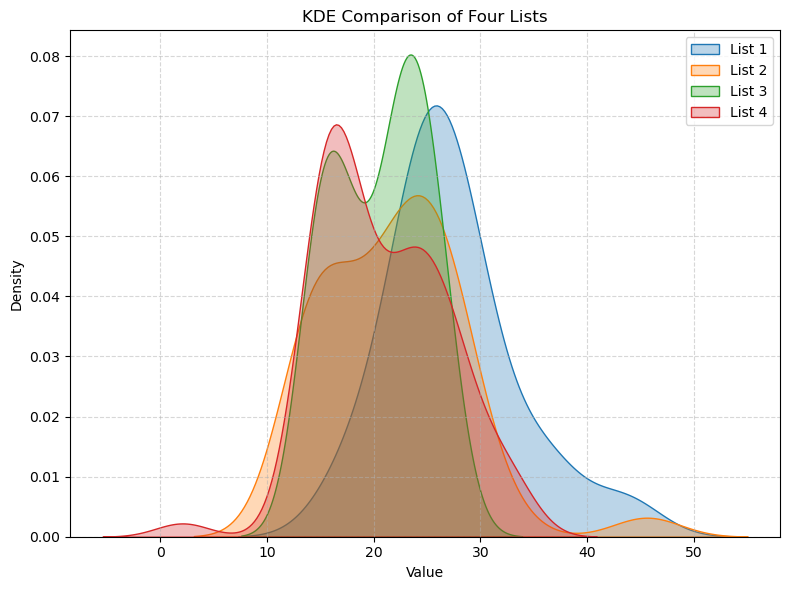

In [113]:
import seaborn as sns
import matplotlib.pyplot as plt

# Example lists
list1 = list(meta1['BMI'])
list2 = list(meta2['BMI'])
list3 = list(meta3['BMI'])
list4 = list(meta4['BMI'])

# Plot
plt.figure(figsize=(8,6))
sns.kdeplot(list1, label="List 1", fill=True, alpha=0.3)
sns.kdeplot(list2, label="List 2", fill=True, alpha=0.3)
sns.kdeplot(list3, label="List 3", fill=True, alpha=0.3)
sns.kdeplot(list4, label="List 4", fill=True, alpha=0.3)

plt.title("KDE Comparison of Four Lists")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

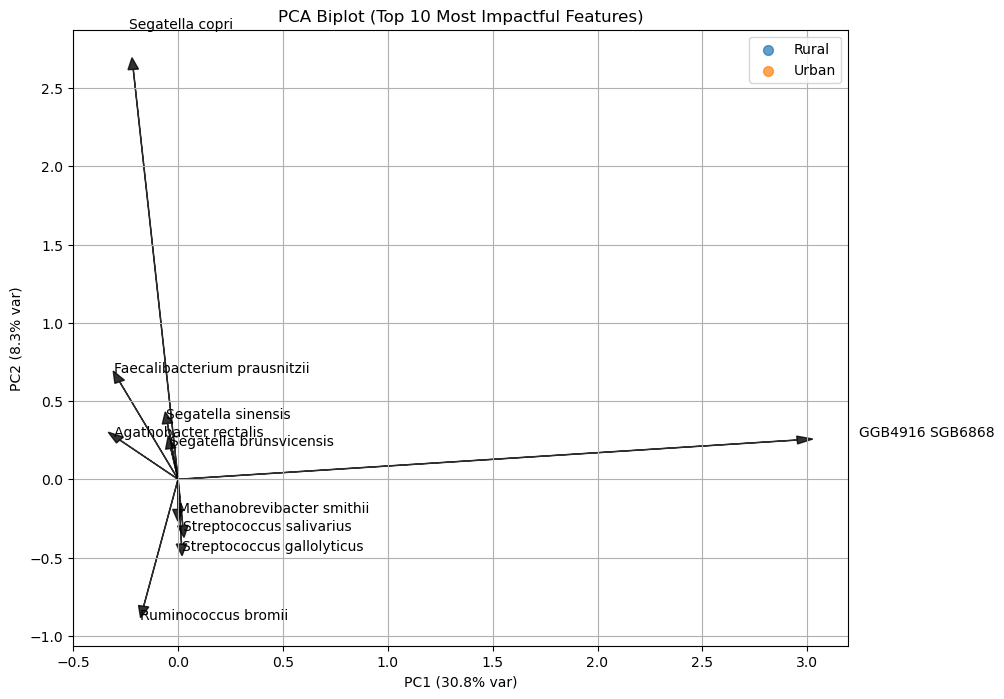

In [78]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

# X = features only, shape (n_samples, n_features)
# labels = sample labels (e.g., Rural/Urban)

X = data_sp_top.drop(columns=['label']).values
y = data_sp_top['label'].values


pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)  # samples in PC1/PC2

# Loadings (contributions of original variables)
loadings = pca.components_.T  # shape: n_features x 2

# 2️⃣ Compute contribution of each feature to PC1+PC2
contrib = np.linalg.norm(loadings, axis=1)  # Euclidean norm across PCs

# 3️⃣ Select top 10 features by contribution
top_idx = np.argsort(contrib)[-10:][::-1]  # indices of top 10
top_features = data_sp_top.drop(columns='label').columns[top_idx]

# 4️⃣ Scatter plot of samples
plt.figure(figsize=(10,8))
for group in np.unique(labels):
    idx = labels == group
    plt.scatter(X_pca[idx,0], X_pca[idx,1], alpha=0.7, s=50, label=group)

# 5️⃣ Draw arrows for top 10 features
scaling = 3
for i in top_idx:
    plt.arrow(0, 0, loadings[i,0]*scaling, loadings[i,1]*scaling, color='black', alpha=0.8, head_width=0.05)
    plt.text(loadings[i,0]*scaling*1.1, loadings[i,1]*scaling*1.1, data_sp_top.drop(columns='label').columns[i],
             fontsize=10, color='black')

# 6️⃣ Labels and legend
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
plt.title('PCA Biplot (Top 10 Most Impactful Features)')
plt.grid(True)
plt.legend()
plt.show()


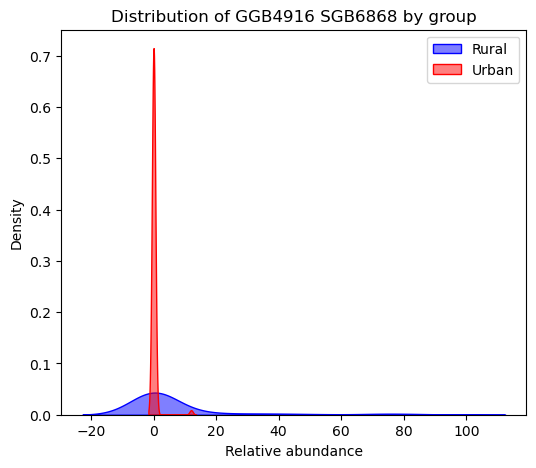

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assume:
# data_sp_top = samples x features
# data_sp_top['label'] = 'Rural' / 'Urban'
# species_name = name of the species column you want to plot

species_name = 'GGB4916 SGB6868'  # replace with your species

plt.figure(figsize=(6,5))
for group, color in zip(['Rural', 'Urban'], ['blue', 'red']):
    sns.kdeplot(data=data_sp_top[data_sp_top['label']==group][species_name],
                label=group, fill=True, alpha=0.5, color=color)
plt.title(f'Distribution of {species_name} by group')
plt.xlabel('Relative abundance')
plt.ylabel('Density')
plt.legend()
plt.show()

C:\Users\rafap\AppData\Local\Temp\ipykernel_9768\3344767278.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plt.hexbin(x[idx], y[idx], C=None, gridsize=gridsize, cmap=plt.cm.get_cmap(cmap_name),


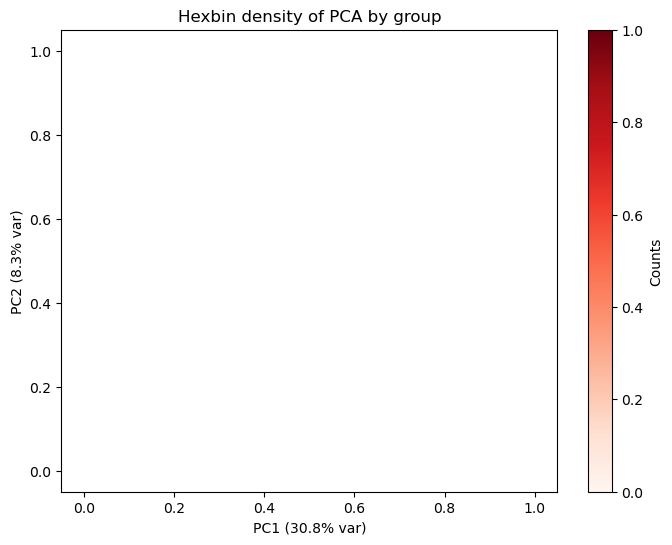

In [37]:
import matplotlib.pyplot as plt
import numpy as np

x = X_pca[:,0]
y = X_pca[:,1]
labels = label  # 'Rural' / 'Urban'

plt.figure(figsize=(8,6))

groups_unique = np.unique(labels)
colors = ['Blues', 'Reds']  # colormaps
alpha = 1
gridsize = 30

for group, cmap_name in zip(groups_unique, colors):
    idx = labels == group
    # hexbin needs a 'C' argument or it will default to counts
    plt.hexbin(x[idx], y[idx], C=None, gridsize=gridsize, cmap=plt.cm.get_cmap(cmap_name),
               alpha=alpha, mincnt=1)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
plt.title('Hexbin density of PCA by group')
plt.colorbar(label='Counts')
plt.show()



In [61]:
import seaborn as sns
# Calcular matriz de correlación
corr_matrix = data_sp_top.corr()

# Plot heatmap
plt.figure(figsize=(15,12))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title('Heatmap de correlaciones (muestra de 200 columnas)')
plt.show()

ValueError: could not convert string to float: 'Urban'

In [74]:
rural = list(metadata[metadata['Lifestyle'] == 'Rural']['Lane'])
urban = list(metadata[metadata['Lifestyle'] == 'Urban']['Lane'])

In [75]:
rural_data = data_sp_top.loc[[x for x in rural if x in data_sp.index]]
urban_data = data_sp_top.loc[[x for x in urban if x in data_sp.index]]

In [62]:
rural_data

,GGB4916 SGB6868,Segatella copri,Agathobacter rectalis,Streptococcus gallolyticus,Ruminococcus bromii,Streptococcus salivarius,Faecalibacterium prausnitzii,Streptococcus lutetiensis,GGB4567 SGB6308,Escherichia coli,Ruminococcus bicirculans ex Wegman et al 2014,Methanobrevibacter smithii,Segatella sinensis,Catenibacterium mitsuokai,Segatella brunsvicensis,GGB3256 SGB4303,Roseburia faecis,Ligilactobacillus ruminis,Enterococcus hirae,GGB4611 SGB6385
37082_3#9,0.0000,0.08053,0.14987,0.0,3.07620,10.38913,0.11081,0.01526,0.0,3.69194,0.01868,0.00000,1.39044,0.74229,0.09810,0.01945,0.03991,0.00000,0.00951,0.00000
37082_3#8,0.0000,1.02161,0.23828,0.0,0.47133,0.05495,1.62658,0.00000,0.0,0.00000,0.17919,1.62892,0.56059,0.99527,0.22720,0.29593,0.00000,0.00000,0.00000,0.27553
37082_3#7,0.0926,0.09637,0.50272,0.0,0.31140,0.00000,0.16513,0.00000,0.0,0.00000,0.00000,5.57606,0.36469,0.19279,0.00000,0.03040,0.00000,0.00000,0.00000,0.25902
37082_3#6,0.0000,0.38928,1.41084,0.0,4.07755,0.05490,20.59416,0.10192,0.0,0.05219,0.00000,0.00971,0.74822,0.41872,0.00000,0.00000,0.47935,0.60072,0.00000,0.00000
37082_3#5,0.0000,2.08956,6.26731,0.0,5.17575,0.00000,3.13823,0.00000,0.0,0.00250,0.08318,2.89779,0.22416,4.24049,0.03797,0.43330,0.71920,0.52565,0.00000,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36703_3#16,0.0000,2.26639,3.35523,0.0,0.29138,0.07955,1.50888,0.00000,0.0,0.00465,1.15367,2.33541,0.63973,0.82153,1.20984,0.00000,0.13855,0.00000,0.00000,0.00000
36703_3#15,0.0000,0.33110,44.21785,0.0,4.40569,1.10598,0.31872,0.00000,0.0,0.00000,0.00000,0.00000,0.06952,0.00000,0.00000,2.49404,0.01951,0.00000,0.00000,0.00000
36703_3#14,0.0000,15.70534,0.50370,0.0,2.33614,4.06460,0.48308,0.02112,0.0,0.03938,0.06138,0.00000,11.84416,1.78752,0.19317,0.00000,0.09756,0.81301,0.00000,0.04348
36703_3#13,0.0000,17.84466,7.22302,0.0,1.80281,0.29253,18.08928,0.00000,0.0,0.00720,0.02765,0.00000,1.02411,0.00000,1.22966,0.00000,2.00568,0.00000,0.00000,0.00000


In [76]:
urban_data

,GGB4916 SGB6868,Segatella copri,Agathobacter rectalis,Streptococcus gallolyticus,Ruminococcus bromii,Streptococcus salivarius,Faecalibacterium prausnitzii,Streptococcus lutetiensis,GGB4567 SGB6308,Escherichia coli,...,GGB51512 SGB71885,Enterococcus durans,Haemophilus sputorum,GGB9122 SGB14055,GGB100899 SGB146315,GGB6006 SGB8630,GGB6014 SGB8646,Alistipes dispar,GGB36267 SGB14177,Mediterraneibacter glycyrrhizinilyticus
37082_2#9,0.00000,1.38002,0.00000,0.00000,3.05001,0.00000,1.15341,0.00000,0.00050,0.05975,...,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.03649,0.00000
37082_2#8,0.00000,1.40202,0.01566,0.00000,0.00000,0.00000,1.14362,0.00000,0.00000,0.05983,...,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.00000,0.00000
37082_2#7,0.00000,0.00000,27.83627,0.00000,4.61010,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.00000,0.00000
37082_2#6,0.00000,0.00000,30.82579,0.00000,0.32973,0.00491,2.63271,0.00000,0.00000,0.66333,...,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.00000,0.00000
37082_2#5,0.00000,0.34445,17.77671,0.00000,7.55254,0.33193,1.98643,0.13375,0.00000,0.78744,...,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.00000,0.12039
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36703_3#5,0.32789,0.13356,0.09800,0.64017,2.76765,0.00352,0.13396,0.00000,47.93797,0.69181,...,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.01706,0.00000
36703_3#3,0.00000,38.61635,2.22241,0.00000,0.00000,0.08143,4.78679,0.00000,0.00000,0.00000,...,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.00000,0.00000
36703_3#2,0.00000,0.00594,2.24924,0.00000,0.00000,0.02976,19.26824,0.00000,0.00000,1.05870,...,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.00000,0.00000
36703_3#10,0.00000,0.00000,1.52041,0.00000,2.86484,0.19221,3.31411,0.00000,0.00000,0.26189,...,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.00000,0.00000


In [ ]:
from statsmodels.multivariate.manova import MANOVA
import pingouin as pg
import numpy as np

data = pd.concat([rural_data, urban_data])
data['group'] = ['Rural']*len(rural_data) + ['Urban']*len(urban_data)




# data: filas = muestras, columnas = features
# group: serie con la etiqueta del grupo
y = data.drop(columns='group').values  # variables dependientes
X = [0 if x == 'Rural' else 1 for x in data['group'].values]  # variable independiente codificada
print(y)
# print(X)

maov = MANOVA(endog=y, exog=X)
print(maov.mv_test())



# res = pg.manova(dv=data.drop(columns='group'), between=data_numeric['group'])
# print(res)

[[0.000000e+00 8.053000e-02 1.498700e-01 ... 0.000000e+00 0.000000e+00
  0.000000e+00]
 [0.000000e+00 1.021610e+00 2.382800e-01 ... 0.000000e+00 0.000000e+00
  0.000000e+00]
 [9.260000e-02 9.637000e-02 5.027200e-01 ... 0.000000e+00 0.000000e+00
  0.000000e+00]
 ...
 [0.000000e+00 5.940000e-03 2.249240e+00 ... 0.000000e+00 0.000000e+00
  0.000000e+00]
 [0.000000e+00 0.000000e+00 1.520410e+00 ... 0.000000e+00 0.000000e+00
  0.000000e+00]
 [0.000000e+00 0.000000e+00 1.222228e+01 ... 5.430000e-03 0.000000e+00
  2.908000e-02]]


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x0000028006367110>>
Traceback (most recent call last):
  File "C:\Users\rafap\anaconda3\envs\clustering-env\Lib\site-packages\ipykernel\ipkernel.py", line 790, in _clean_thread_parent_frames
    active_threads = {thread.ident for thread in threading.enumerate()}
                                                 ^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\rafap\anaconda3\envs\clustering-env\Lib\threading.py", line 1501, in enumerate
    def enumerate():
    
KeyboardInterrupt: 
Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x0000028006367110>>
Traceback (most recent call last):
  File "C:\Users\rafap\anaconda3\envs\clustering-env\Lib\site-packages\ipykernel\ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 


KeyboardInterrupt: 

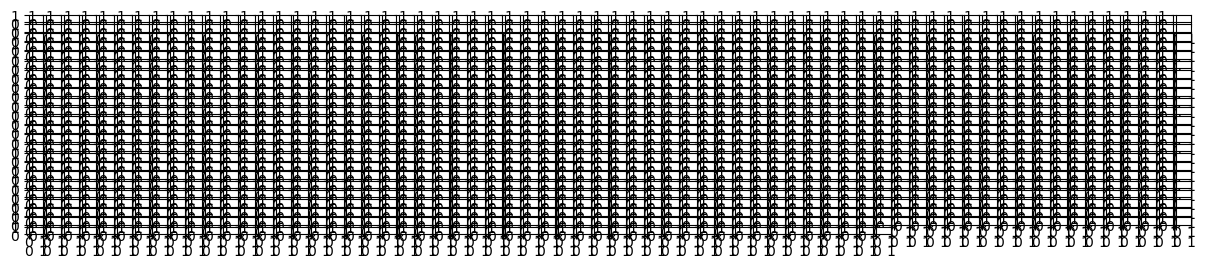

In [32]:
data_sp.hist(bins=50, figsize=(15,8))
plt.show()

In [3]:
import os

In [5]:
os.listdir('../datasets')

['2019_Aida_niños_ Microbioma Parasitos y Salud_ FINAL.xlsx',
 '41564_2018_337_MOESM4_ESM.xlsx',
 'Alimentos_Montaña-ciudad_2022.xlsx',
 'Alimentos_Montaña-Ciudad_Datos resumidos_2022.csv',
 'Base_MinEEG&Macronutrientes_7abril2020.xlsx',
 'BdD - AdultosMontañaAltadeGuerrero.xlsx',
 "BdD - HOMBRES ME'PHAA.xlsx",
 'BdD - Latinbiota.xlsx',
 'BdD - MICROBIOMA ADULTOS.xlsx',
 'BdD - Microbiota Niños ciudad vs Montaña.xlsx',
 'BdD - Proyecto Microbioma V.1.xlsx',
 'BdD - Proyectos Neuroecología.xlsx',
 'BdD-2024_Metadatos_Familias_Latinbiota.xlsx',
 'bracken_taxonomy.csv',
 'Datos encuestas Nutricionales_Ciudad .xlsx',
 'ec-predictions',
 'EEG_Nutrición_Niños_C y M_2022_RevCristian.xlsx',
 'Jesus Monteros_EEG_Nutricion Niños_Ciudad_y_Montaña.csv',
 'latinbiota_merge_metaphlan_data.tsv.csv',
 'latinbiota_pathabundance_stratified.tsv',
 'latinbiota_pathabundance_unstratified.tsv',
 'metadata_LATINBIOTA_MEXICO.xlsx',
 'module-prediction-human-01',
 'module-prediction-humann',
 'modul